# [LAB 08] 2. 데이터 시각화
## #01. 준비작업
### 1. 이전 분석 내용 가져오기
- 데이터 로드, 기초통계량 가져오기 등의 반복적인 작업은 별도의 ipynb 파일에 구현해두고 Jupyter Magic Command로 불러올 수 있다.
    - 다른 ipynb 파일의 소스코드를 이 위치에 복붙 하는 효과가 있다.
    - 가져온 ipynb 파일의 import 내용이나 변수들의 모두 유지된다.

In [15]:
%%capture cap
%run "./08. PBT - EDAㅣ1-EDA 시작하기.ipynb"

### 2. 불러온 내용 확인
- 이전 분석 내역이 잘 로드되었는지 확인한다.

In [16]:
print("목표변수 :", target)
print("연속형(종속변수 포함):", continuous_cols)
print('독립변수(명목형):', nominal_cols)
print('독립변수(연속형):', feature_continuous)

display(df.head())
display(desc.head())
display(cat_desc.head())

목표변수 : MEDV
연속형(종속변수 포함): ['CRIM', 'ZN', 'INDUS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
독립변수(명목형): ['CHAS']
독립변수(연속형): ['CRIM', 'ZN', 'INDUS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.006,18.000,2.310,0,0.538,6.575,65.200,4.090,1,296,15.300,396.900,4.980,24.000
1,0.027,0.000,7.070,0,0.469,6.421,78.900,4.967,2,242,17.800,396.900,9.140,21.600
2,0.027,0.000,7.070,0,0.469,7.185,61.100,4.967,2,242,17.800,392.830,4.030,34.700
3,0.032,0.000,2.180,0,0.458,6.998,45.800,6.062,3,222,18.700,394.630,2.940,33.400
4,0.069,0.000,2.180,0,0.458,7.147,54.200,6.062,3,222,18.700,396.900,5.330,36.200


,count,mean,std,min,25%,50%,75%,max,rel_diff,rdiff_flag,iqr,upper_bound,lower_bound,upper_outliers,upper_outliers_ratio,lower_outliers,lower_outliers_ratio,outliers,outliers_ratio,skew,skew_interpret,kurt,kurt_interpret,log_need
CRIM,506.000,3.614,8.602,0.006,0.082,0.257,3.677,88.976,13.087,large_diff,3.595,9.070,-5.311,66,0.130,0,0.000,66,0.130,5.223,right tail,37.131,leptokurtic,log1p
ZN,506.000,11.364,23.322,0.000,0.000,0.000,12.500,100.000,inf,large_diff,12.500,31.250,-18.750,68,0.134,0,0.000,68,0.134,2.226,right tail,4.032,leptokurtic,log1p
INDUS,506.000,11.137,6.860,0.460,5.190,9.690,18.100,27.740,0.149,diff,12.910,37.465,-14.175,0,0.000,0,0.000,0,0.000,0.295,symmetric,-1.234,platykurtic,none
NOX,506.000,0.555,0.116,0.385,0.449,0.538,0.624,0.871,0.031,similar,0.175,0.886,0.187,0,0.000,0,0.000,0,0.000,0.729,right tail,-0.065,platykurtic,none
RM,506.000,6.285,0.703,3.561,5.885,6.208,6.623,8.780,0.012,similar,0.738,7.731,4.778,22,0.043,8,0.016,30,0.059,0.404,symmetric,1.892,leptokurtic,none


,CHAS
count,506
unique,2
top,0
freq,471


### 3. 라이브러리 참조하기
- 불러온 ipynb 파일에서 참조하지 않는 라이브러리 중 필요한 것만 참조한다.
    - 여기서는 새로운 라이브러리 참조는 불필요하지만 실습을 위해 이전 ipynb 파일과 중복 참조함

In [17]:
from helpers import *

## #02. 단변량 데이터 시각화
### 1. 종속변수
- 종속변수는 예측 대상이 되는 값이므로 가장 먼저 따로 시각화한다.

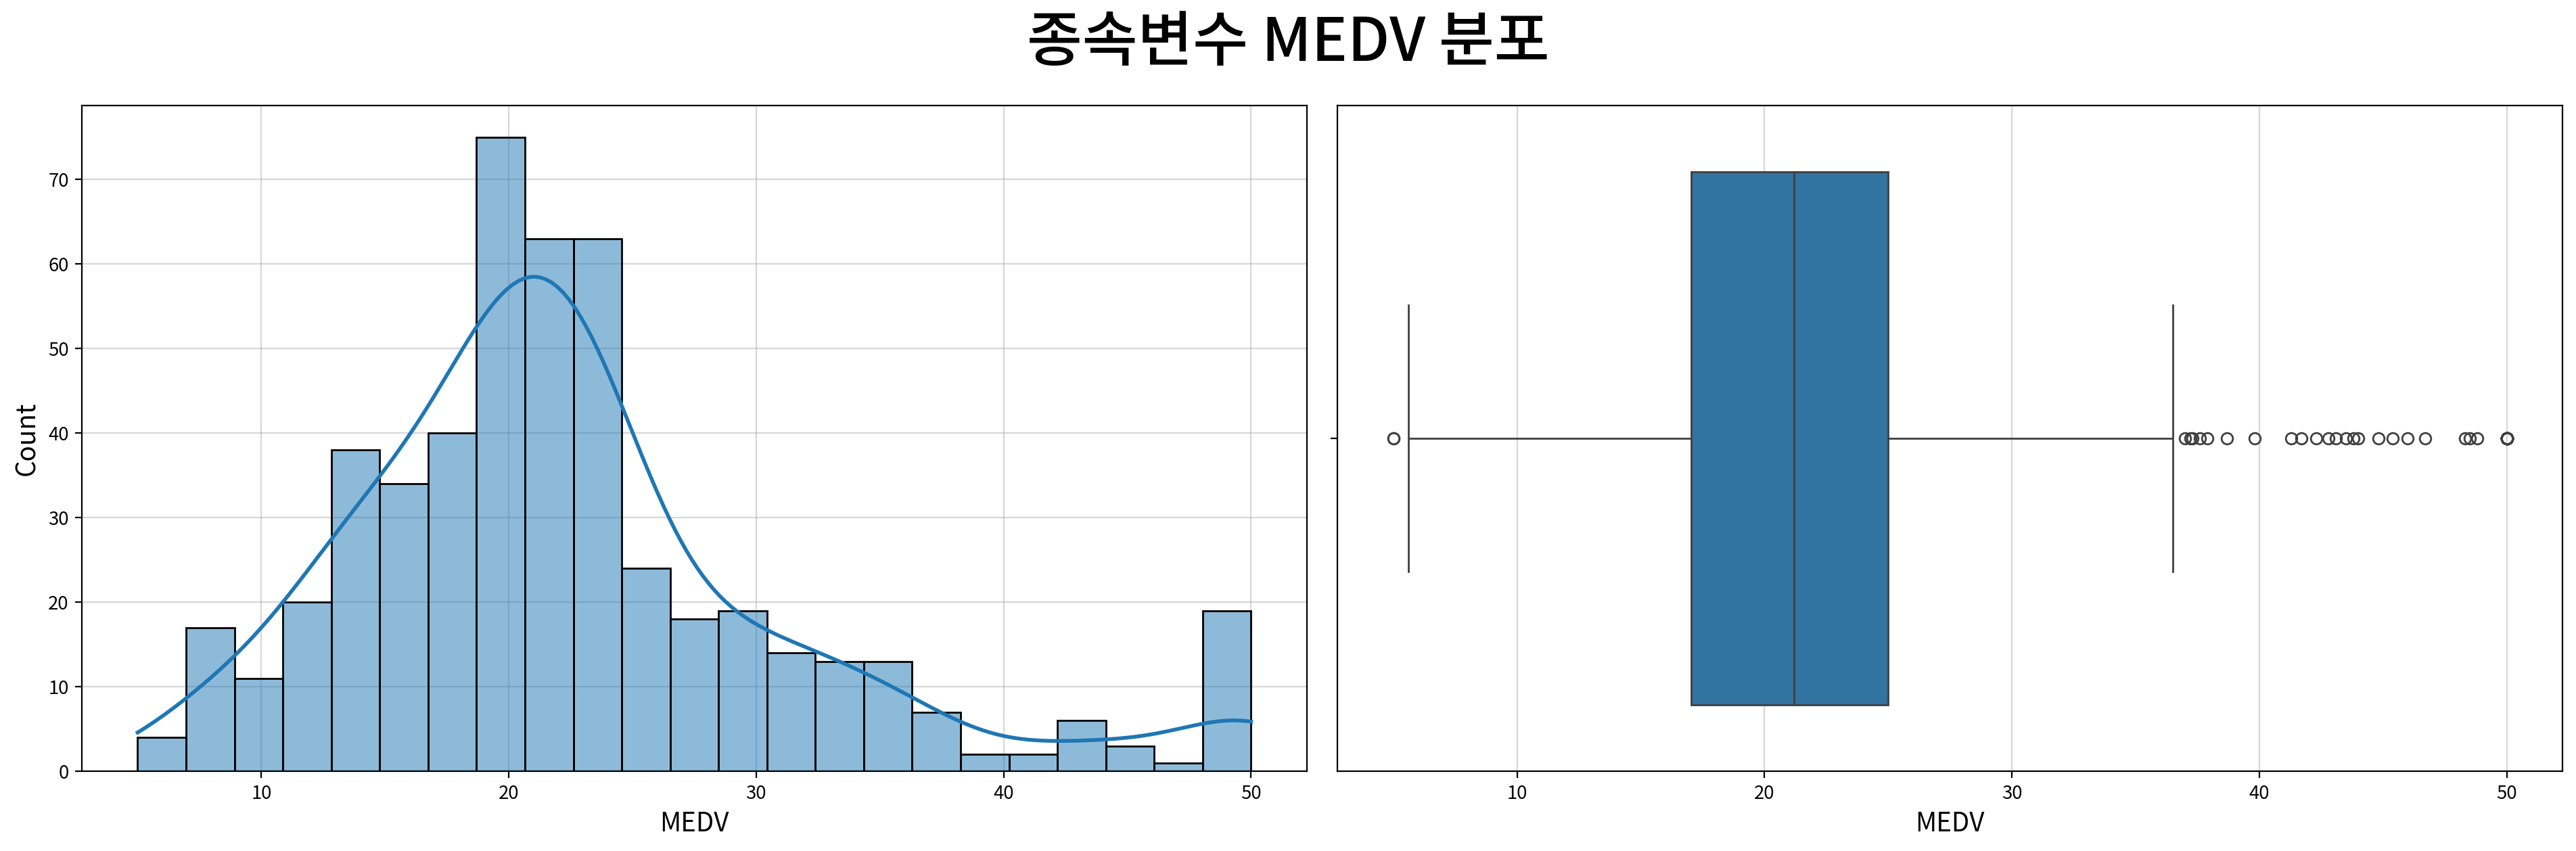

In [18]:
# 1행 2열 서브플롯 구성
# -> 그래프 크기는 서브플롯 중 하나의 크기(전체 크기는 가로 960 * 2가 됨)
fig, ax = my_plot.init(rows=1, cols=2, title=f'종속변수 {target} 분포', width=960, height=640)
my_plot.histplot(data=df, x=target, kde=True, ax=ax[0])
my_plot.boxplot(data=df, x=target, ax=ax[1])
my_plot.show()

|점검항목|MEDV 관찰내용|
|-|-|
|분포모양(왜도)|오른쪽으로 치우침(우편향, skew = 1.1)|
|봉우리 수|eksqhd - 단, 오른쪽 끝(50)에 인위적으로 군집|
|이상치(박스플롯)|위쪽 수염 밖에 점 존재|
|이산점(군집)|50에 값이 뭉침 = 상한 처리(천장 효과)

- 판단 및 조치 : 우편향 + 50 천장효과가 있어 그대로 쓰기엔 부담스러움
- 로그 변환으로 분포를 좌우 대칭에 가깝에 펴고, 50에 잘린 값(천장효과)은 높은 가격대 예측의 한계로 인지한다.

### 2. 연속형 독립변수 분포 시각화

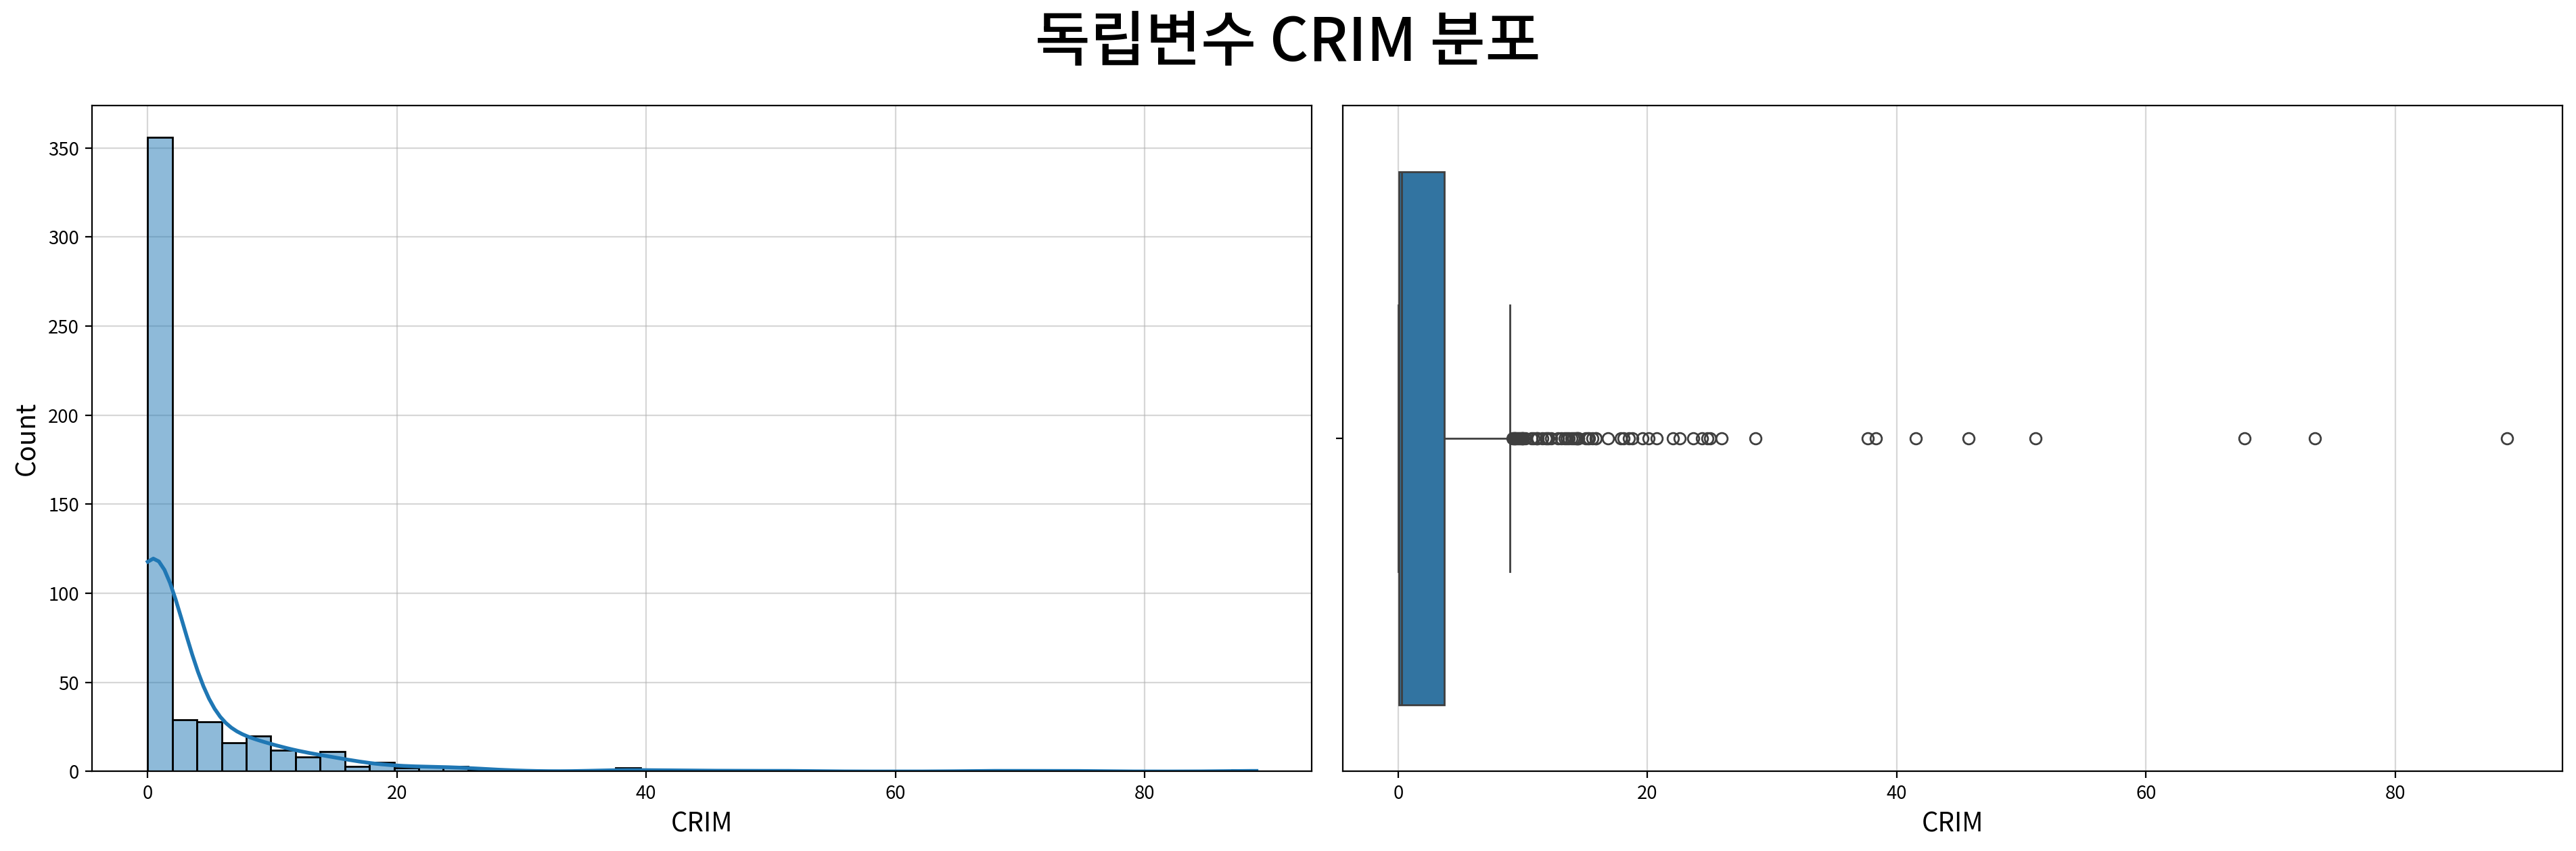

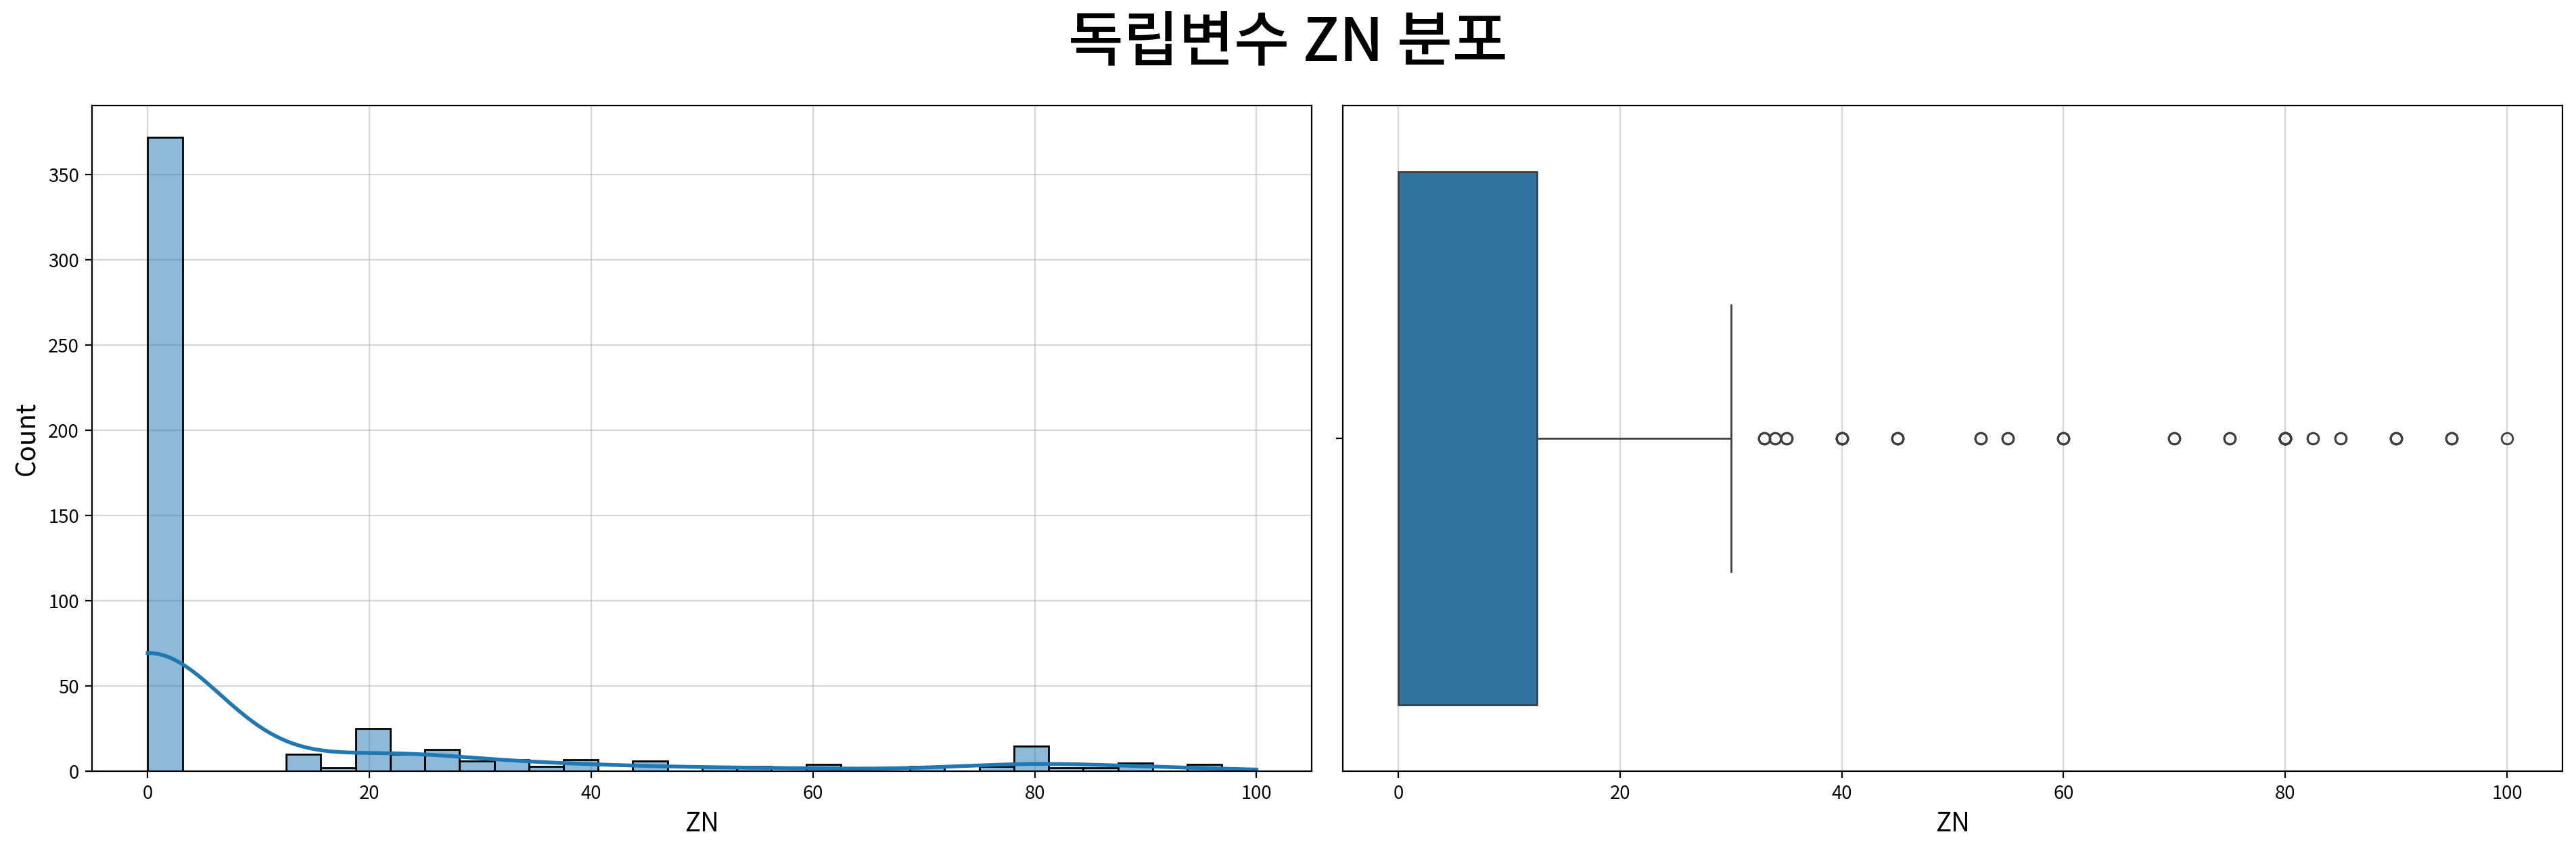

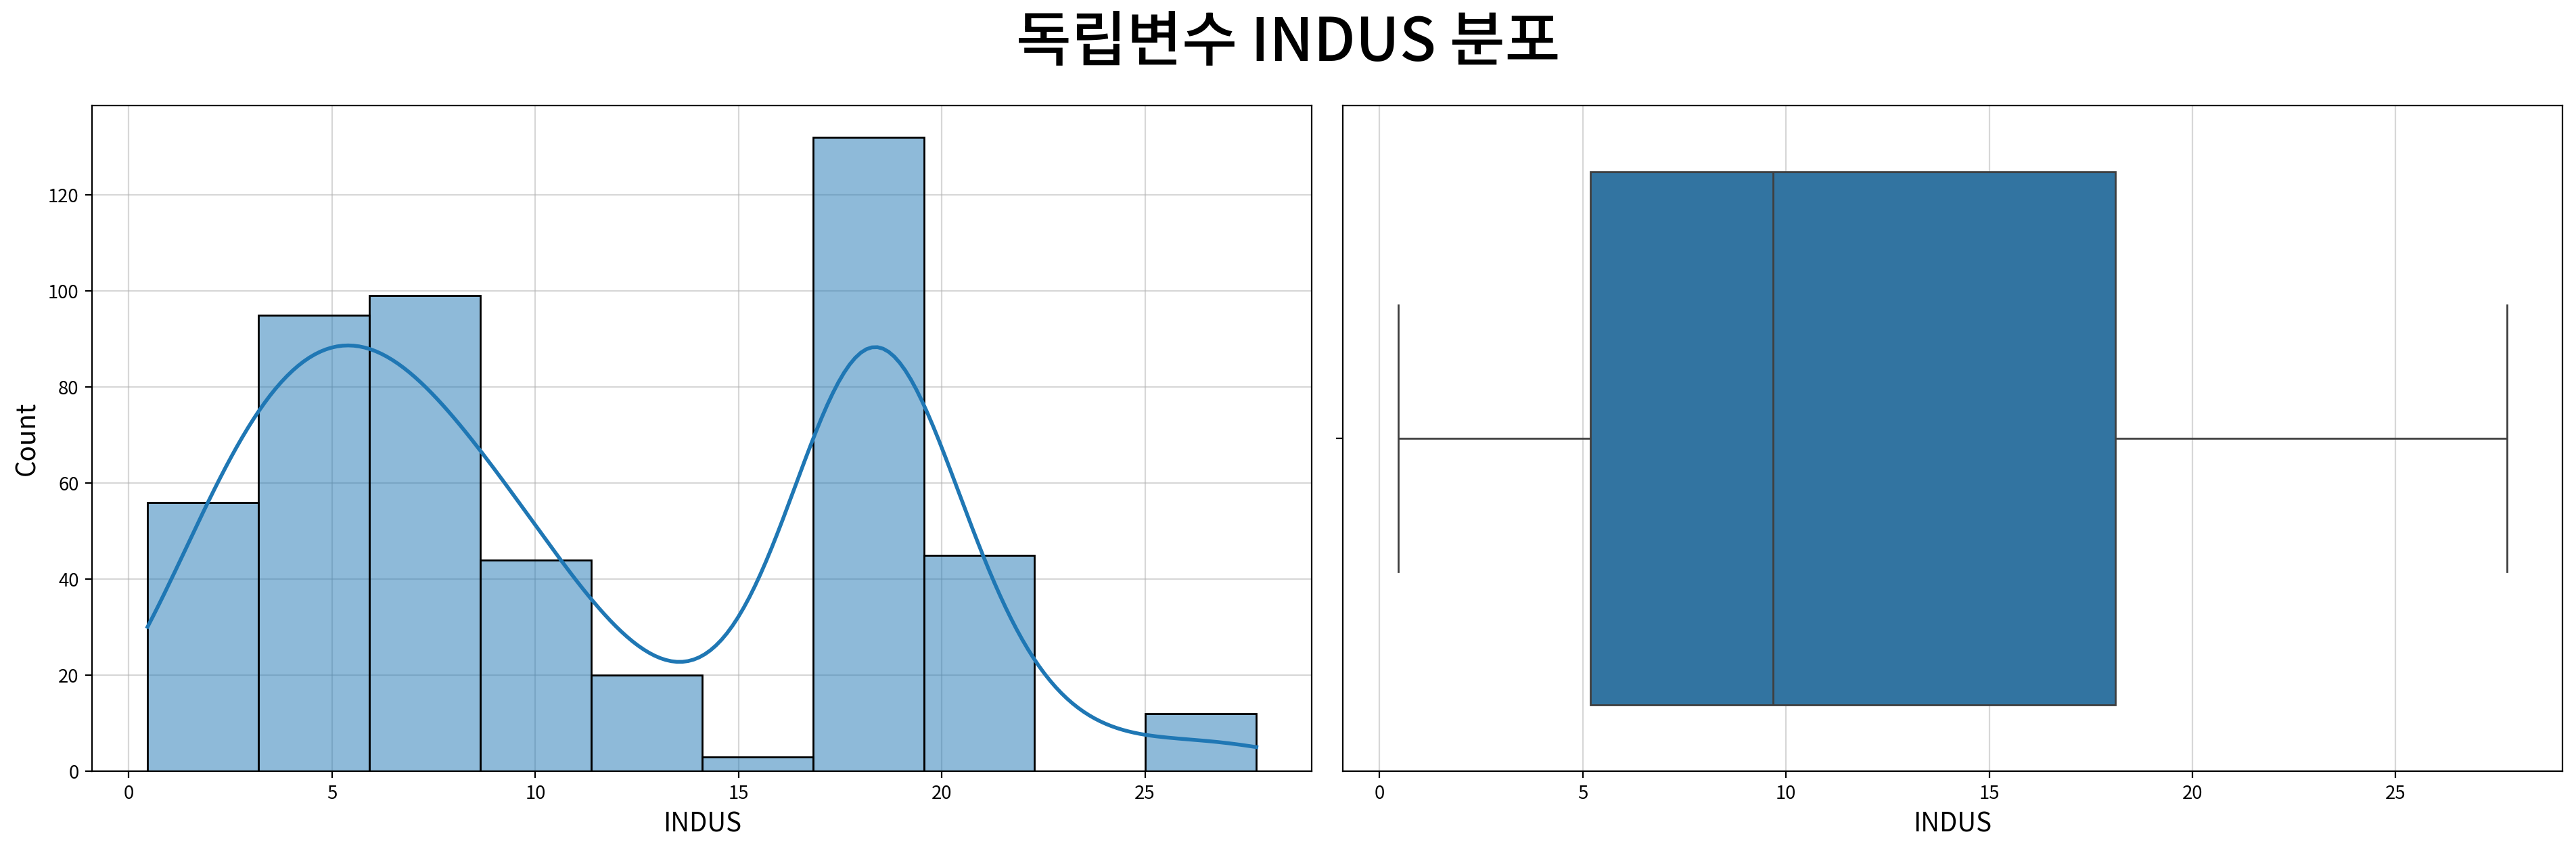

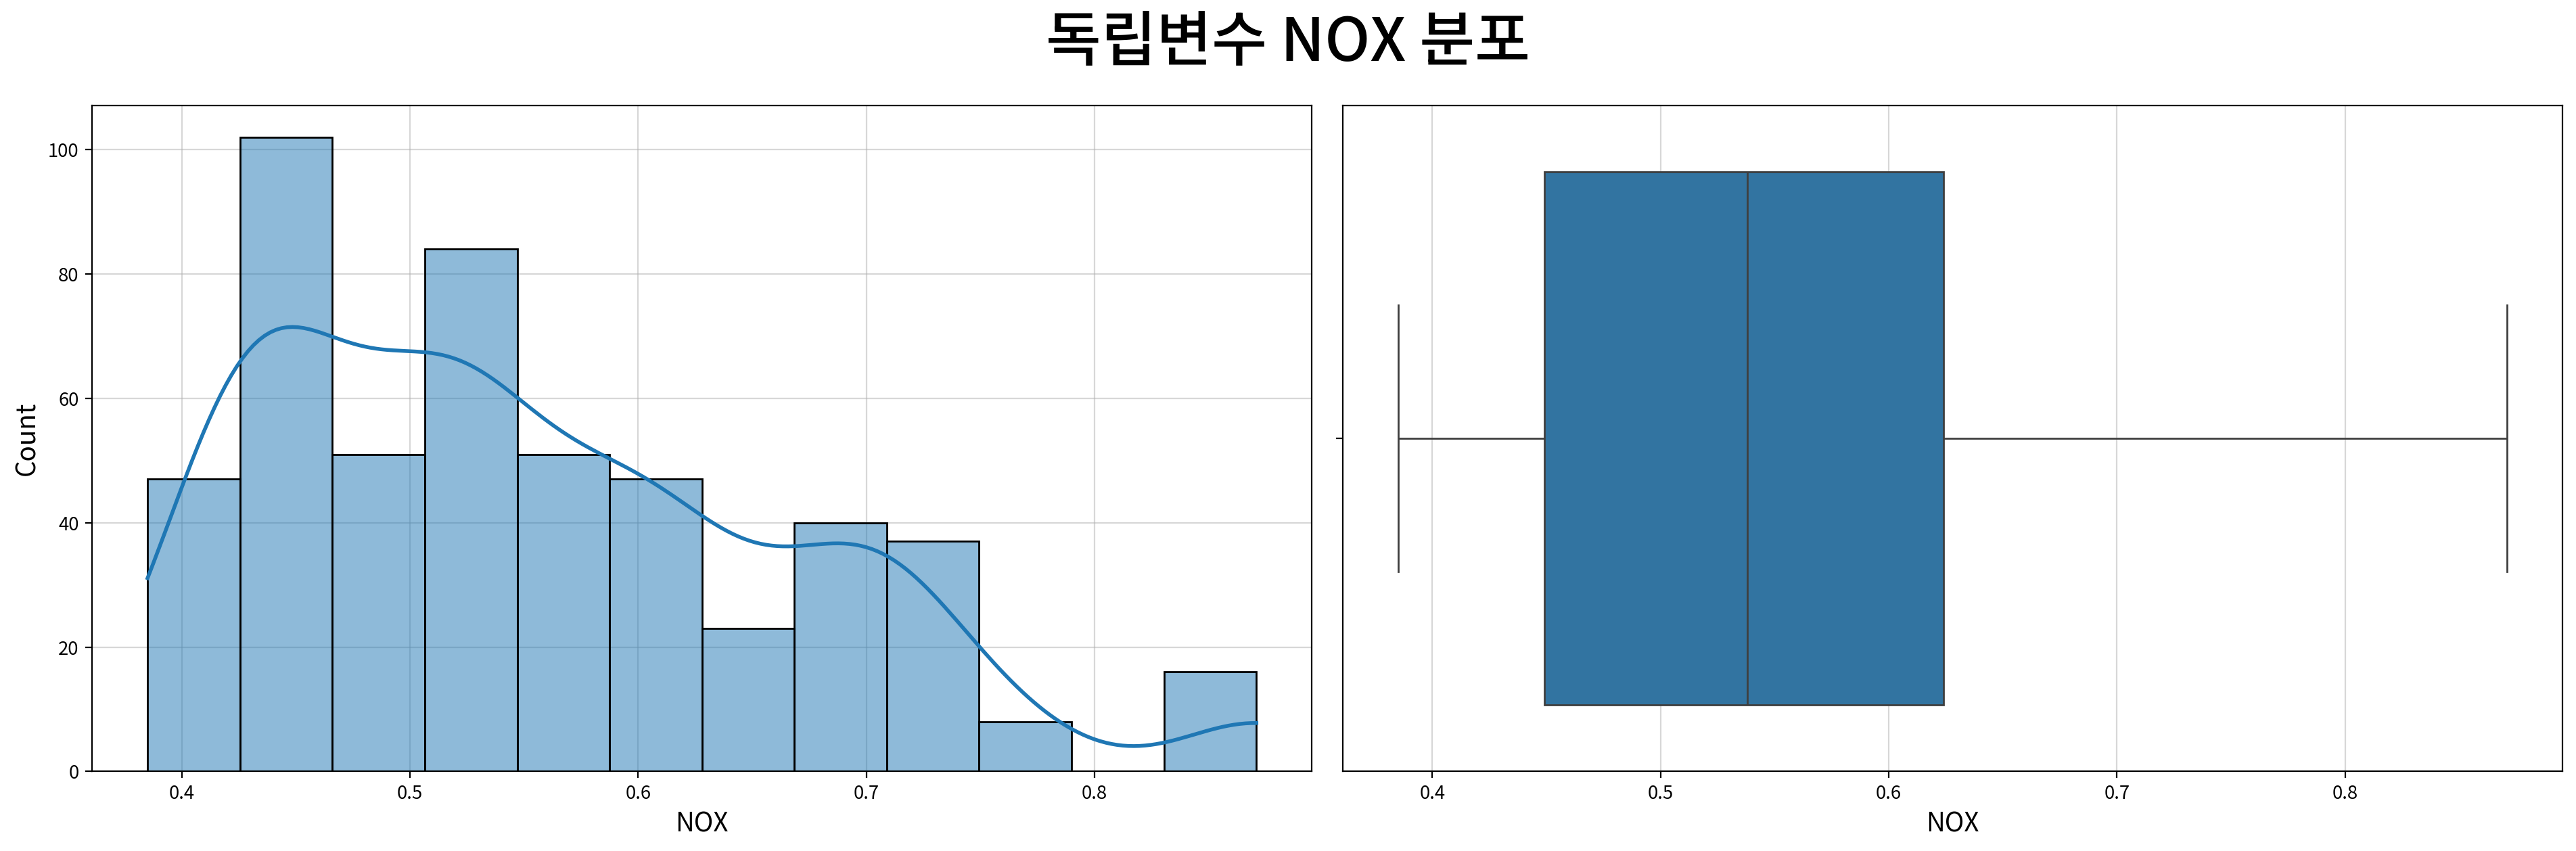

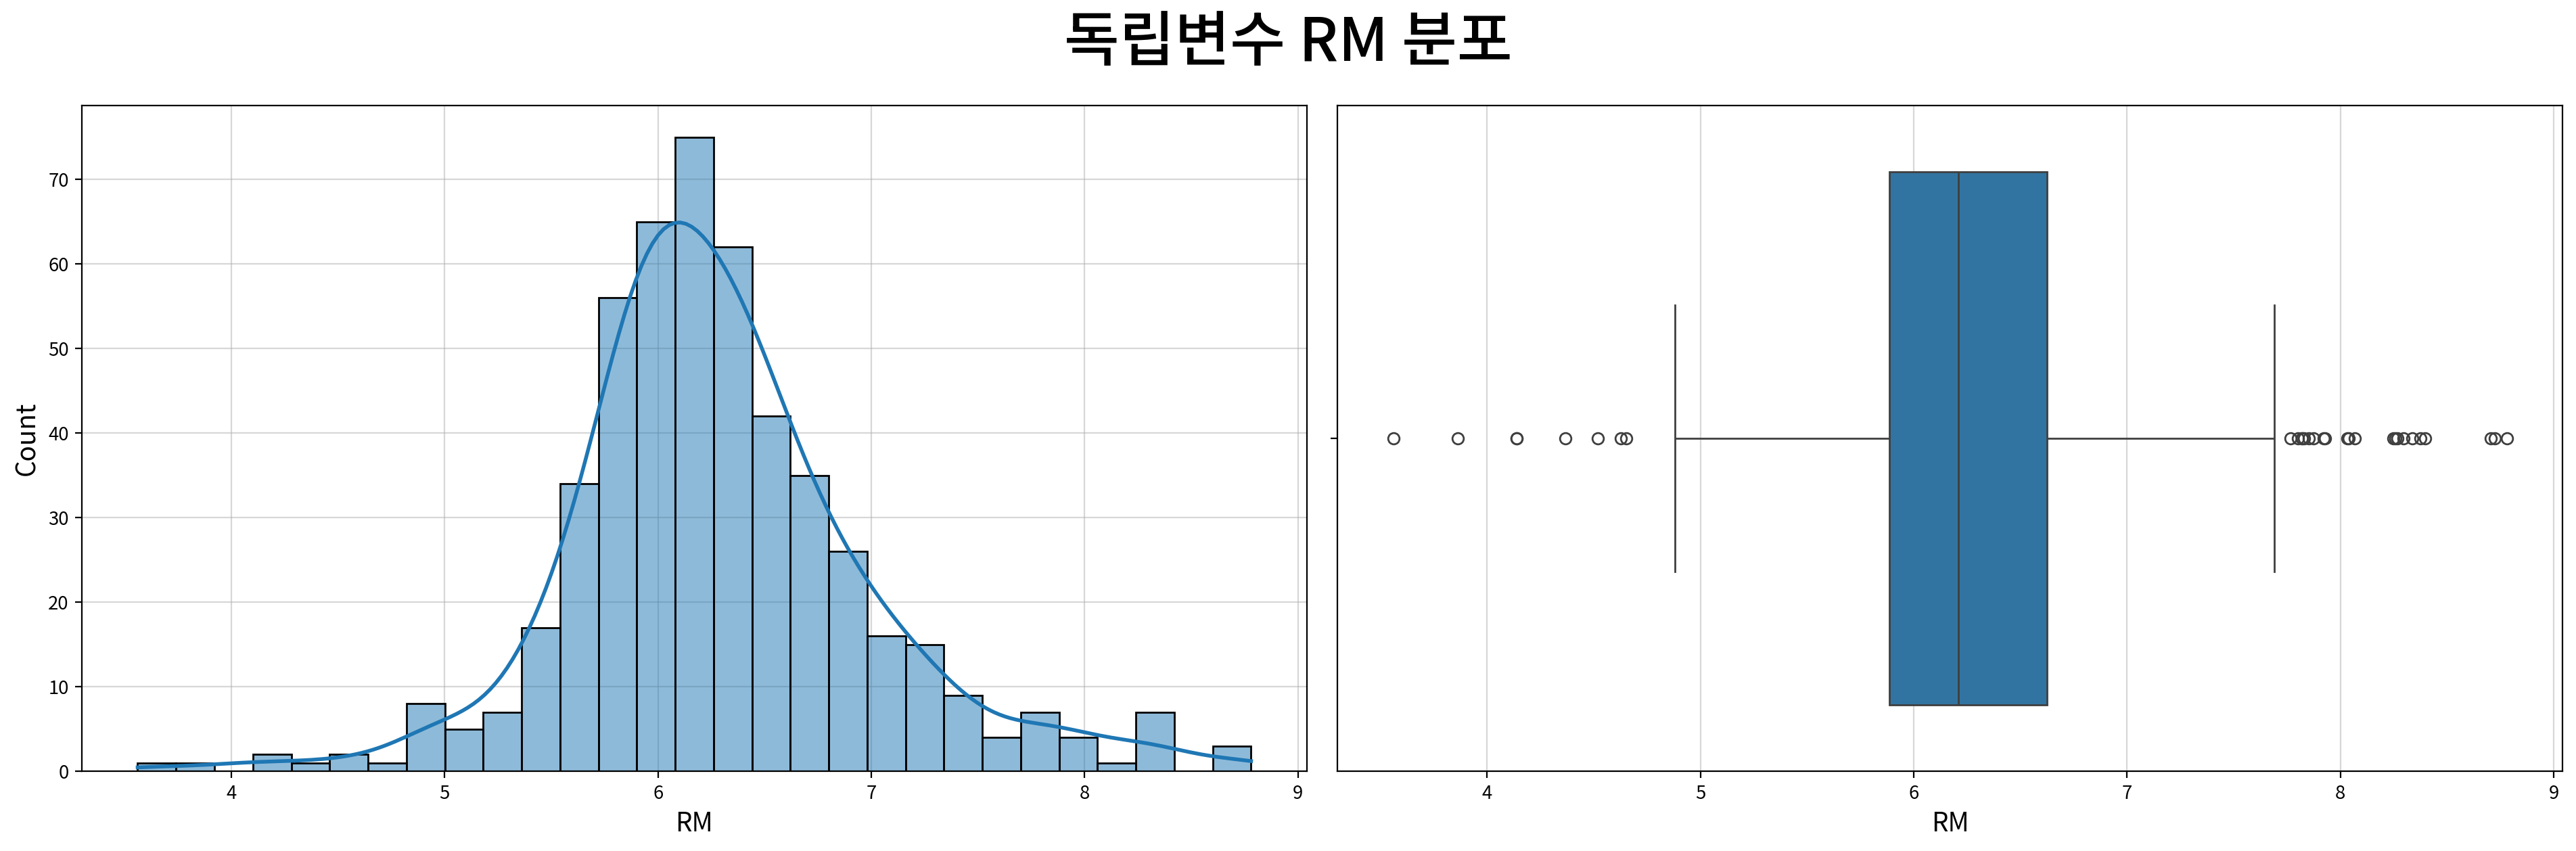

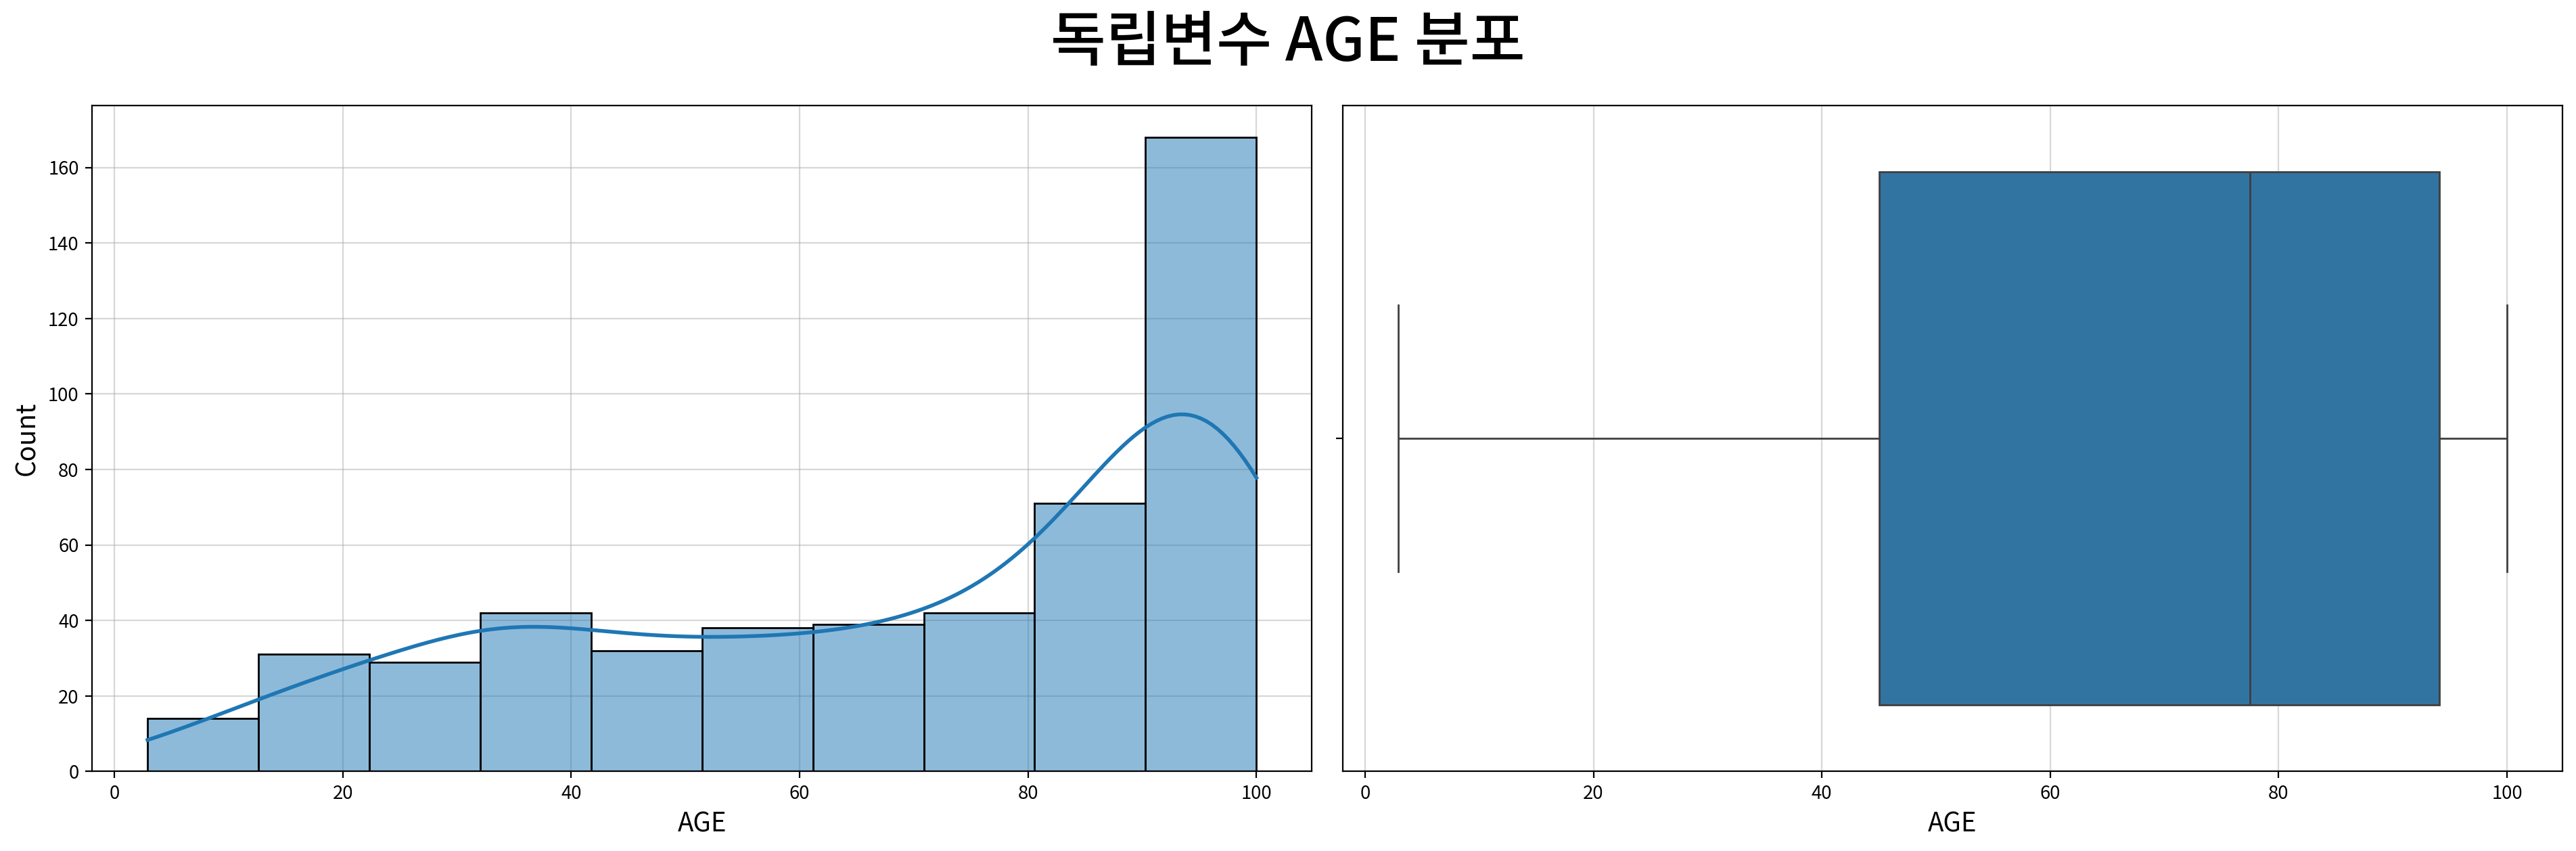

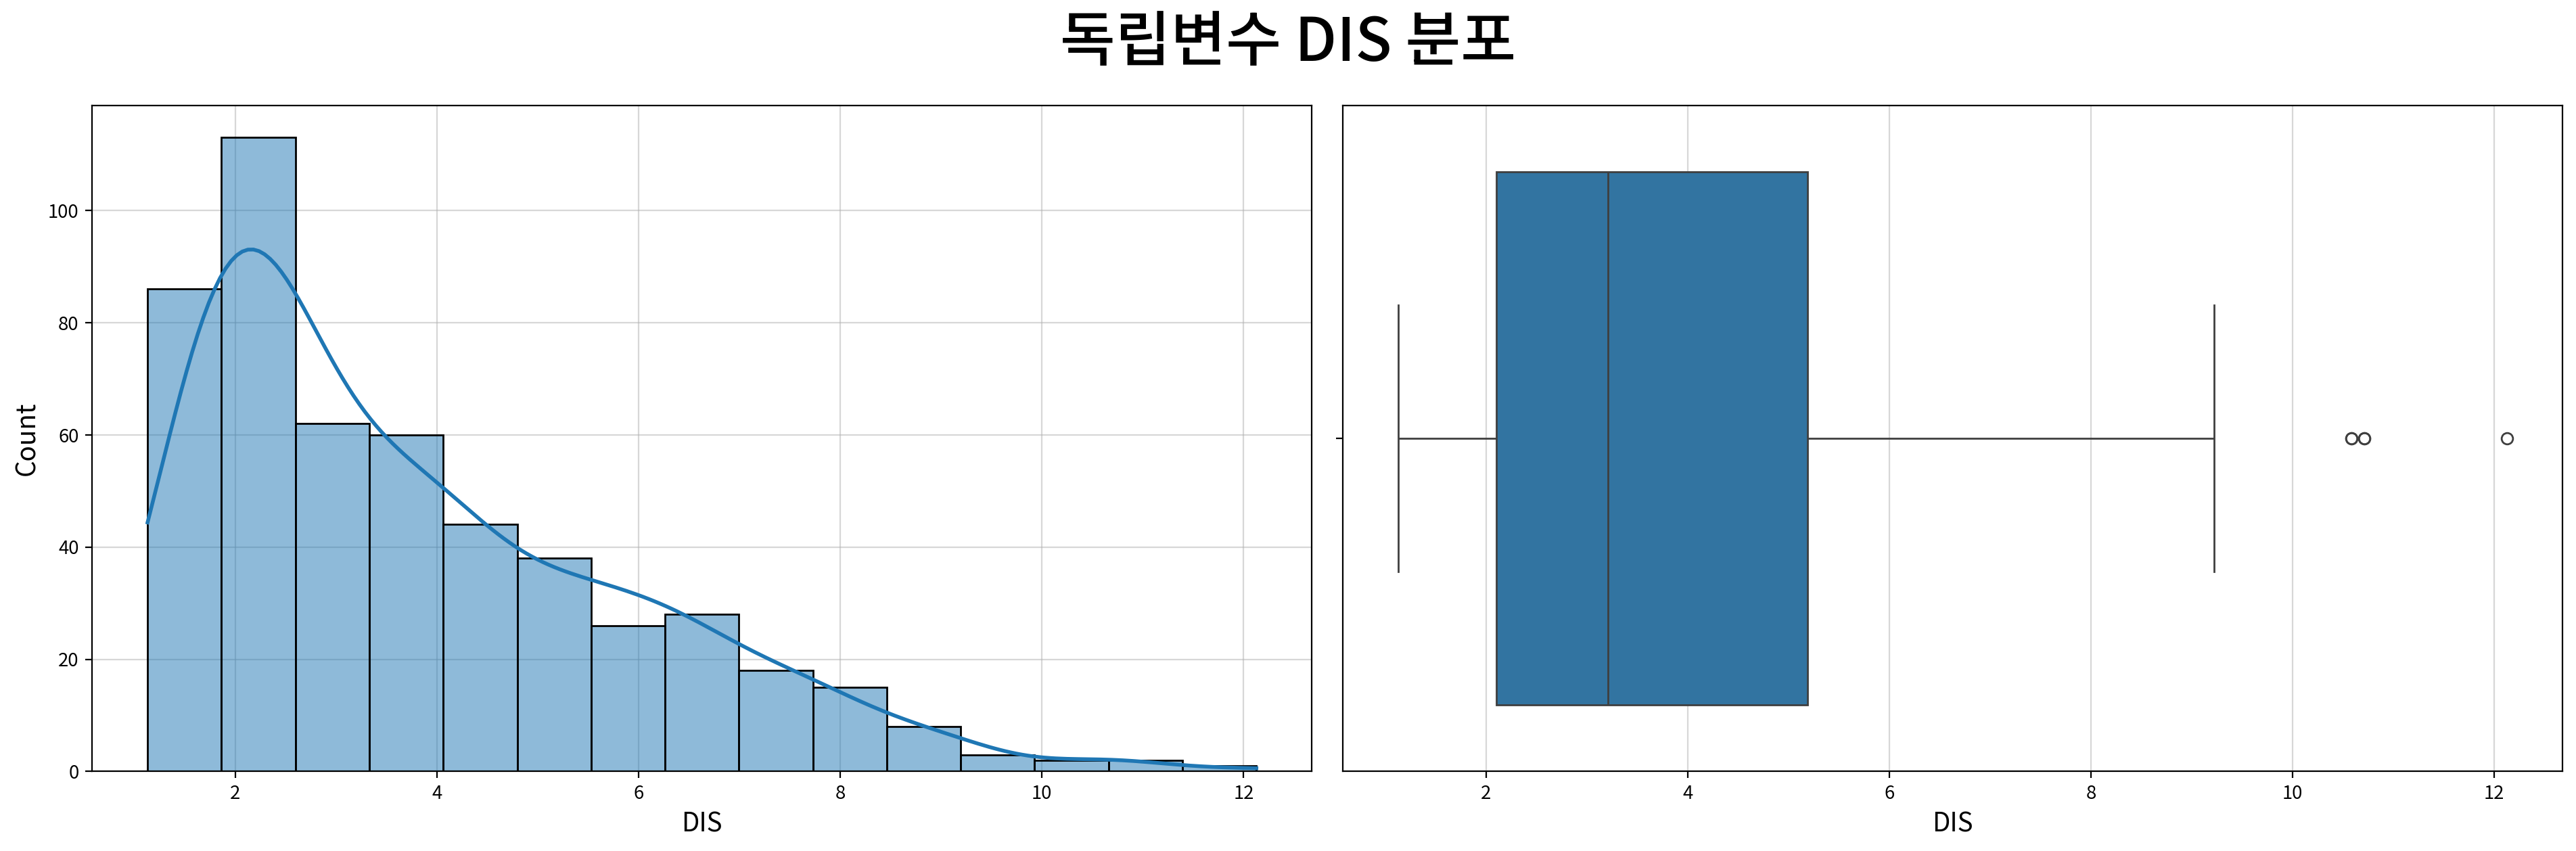

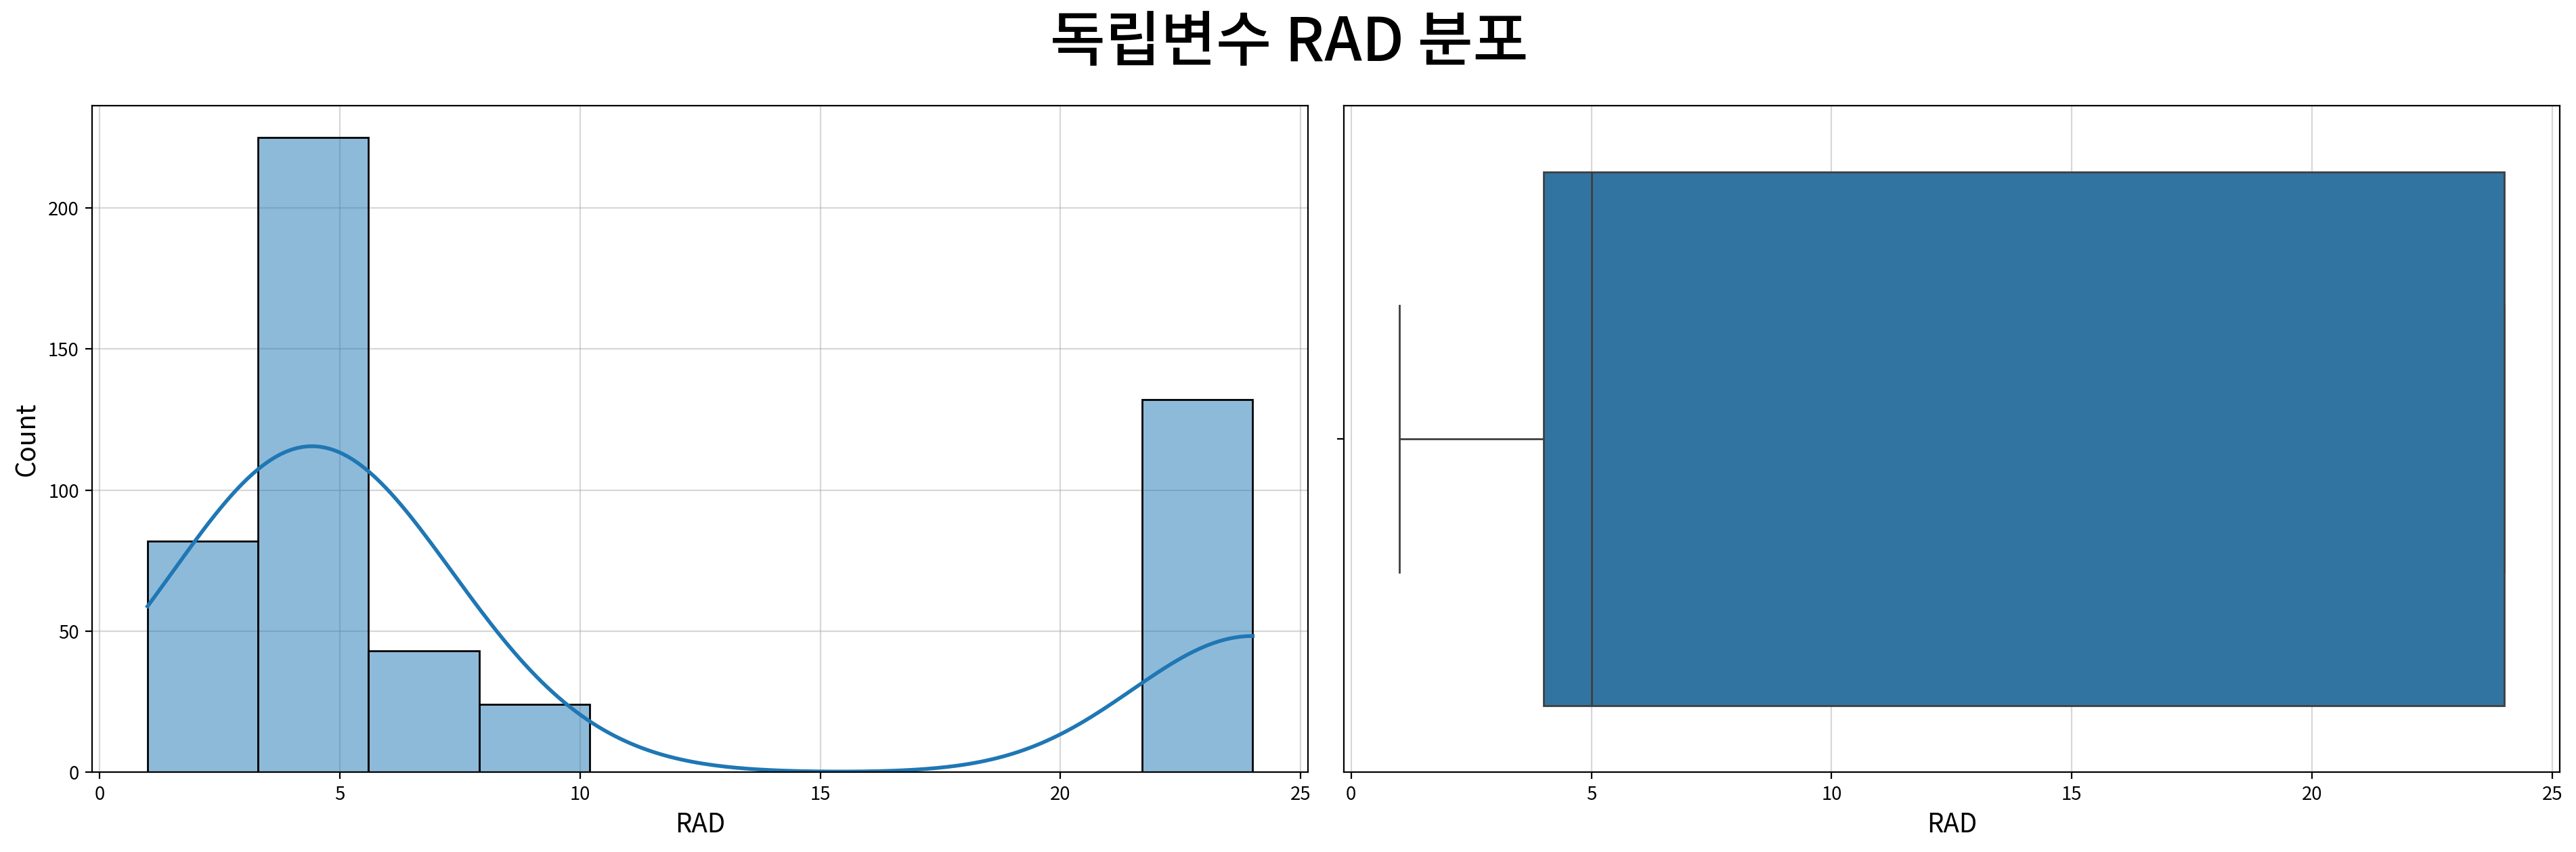

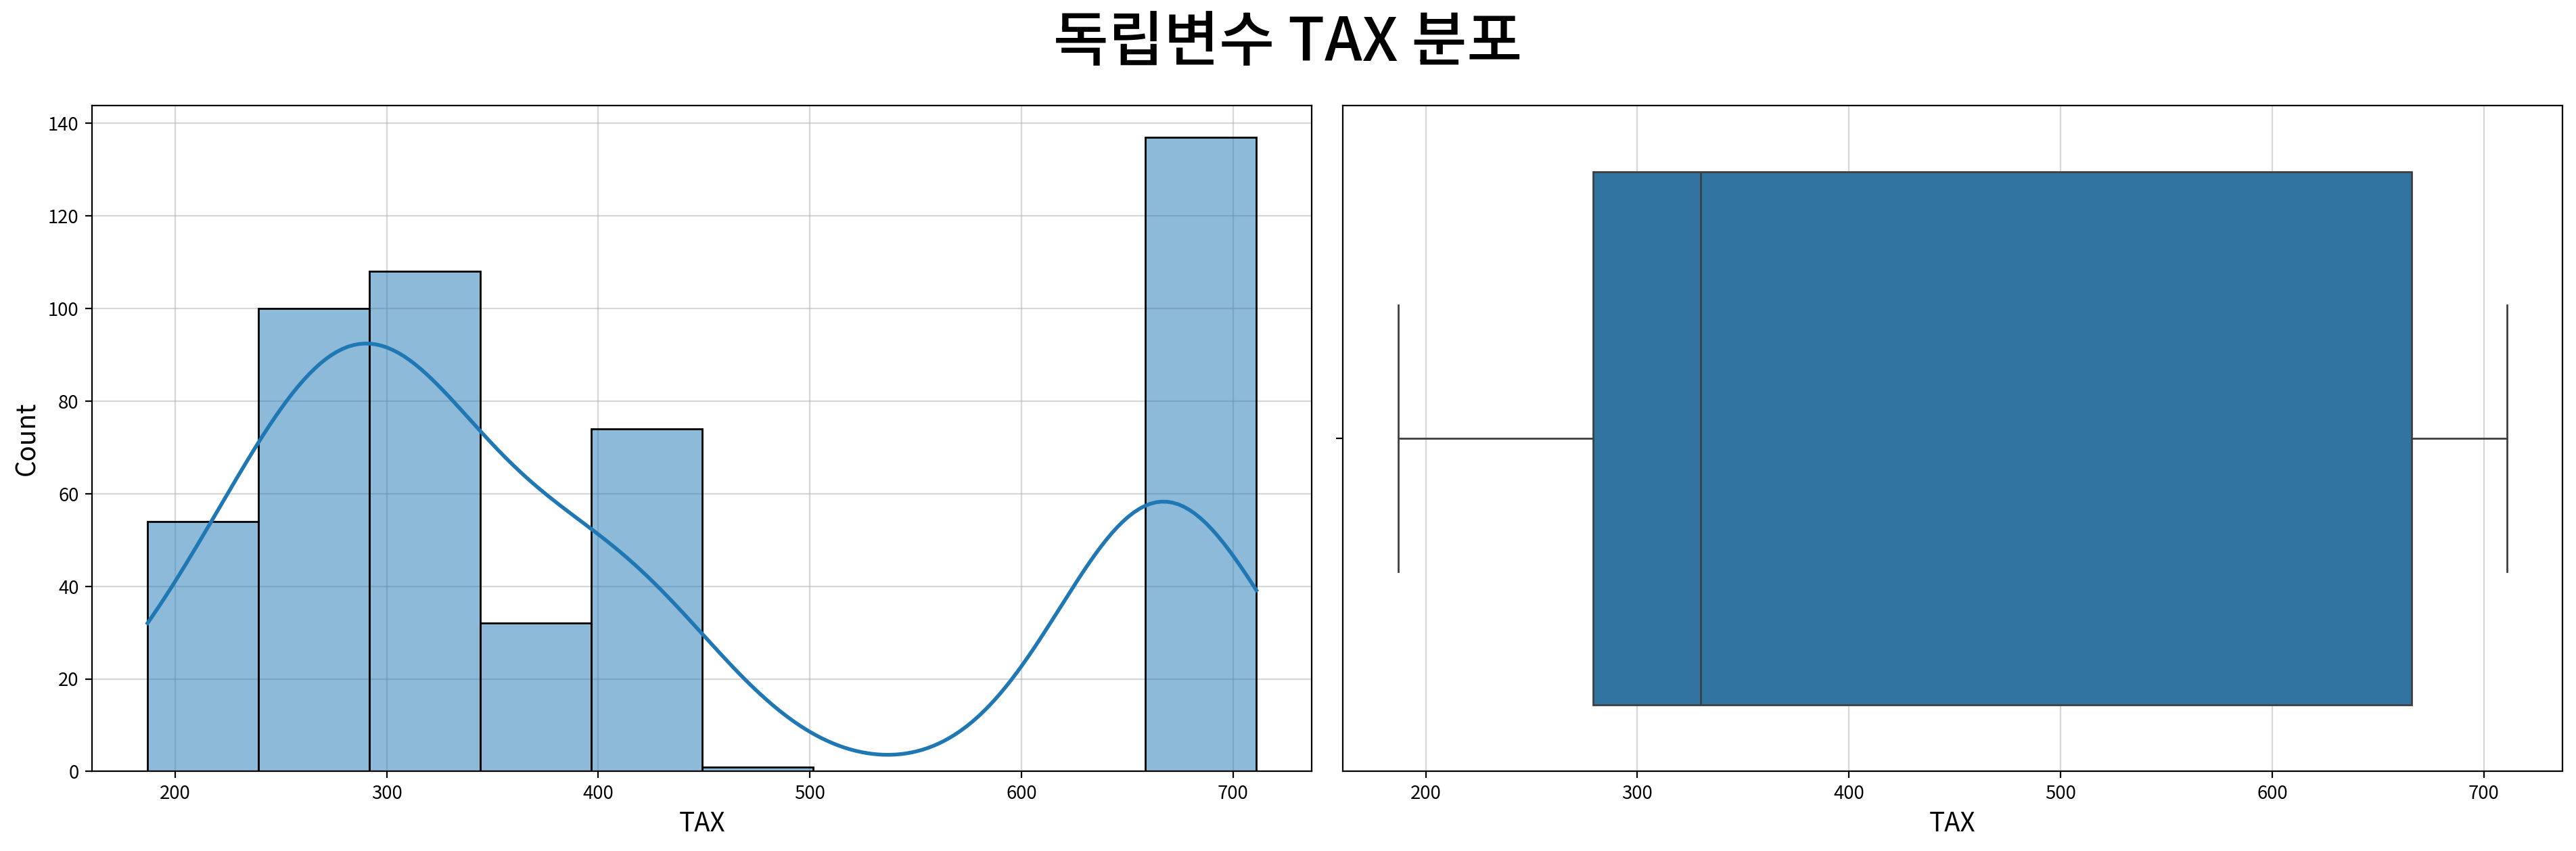

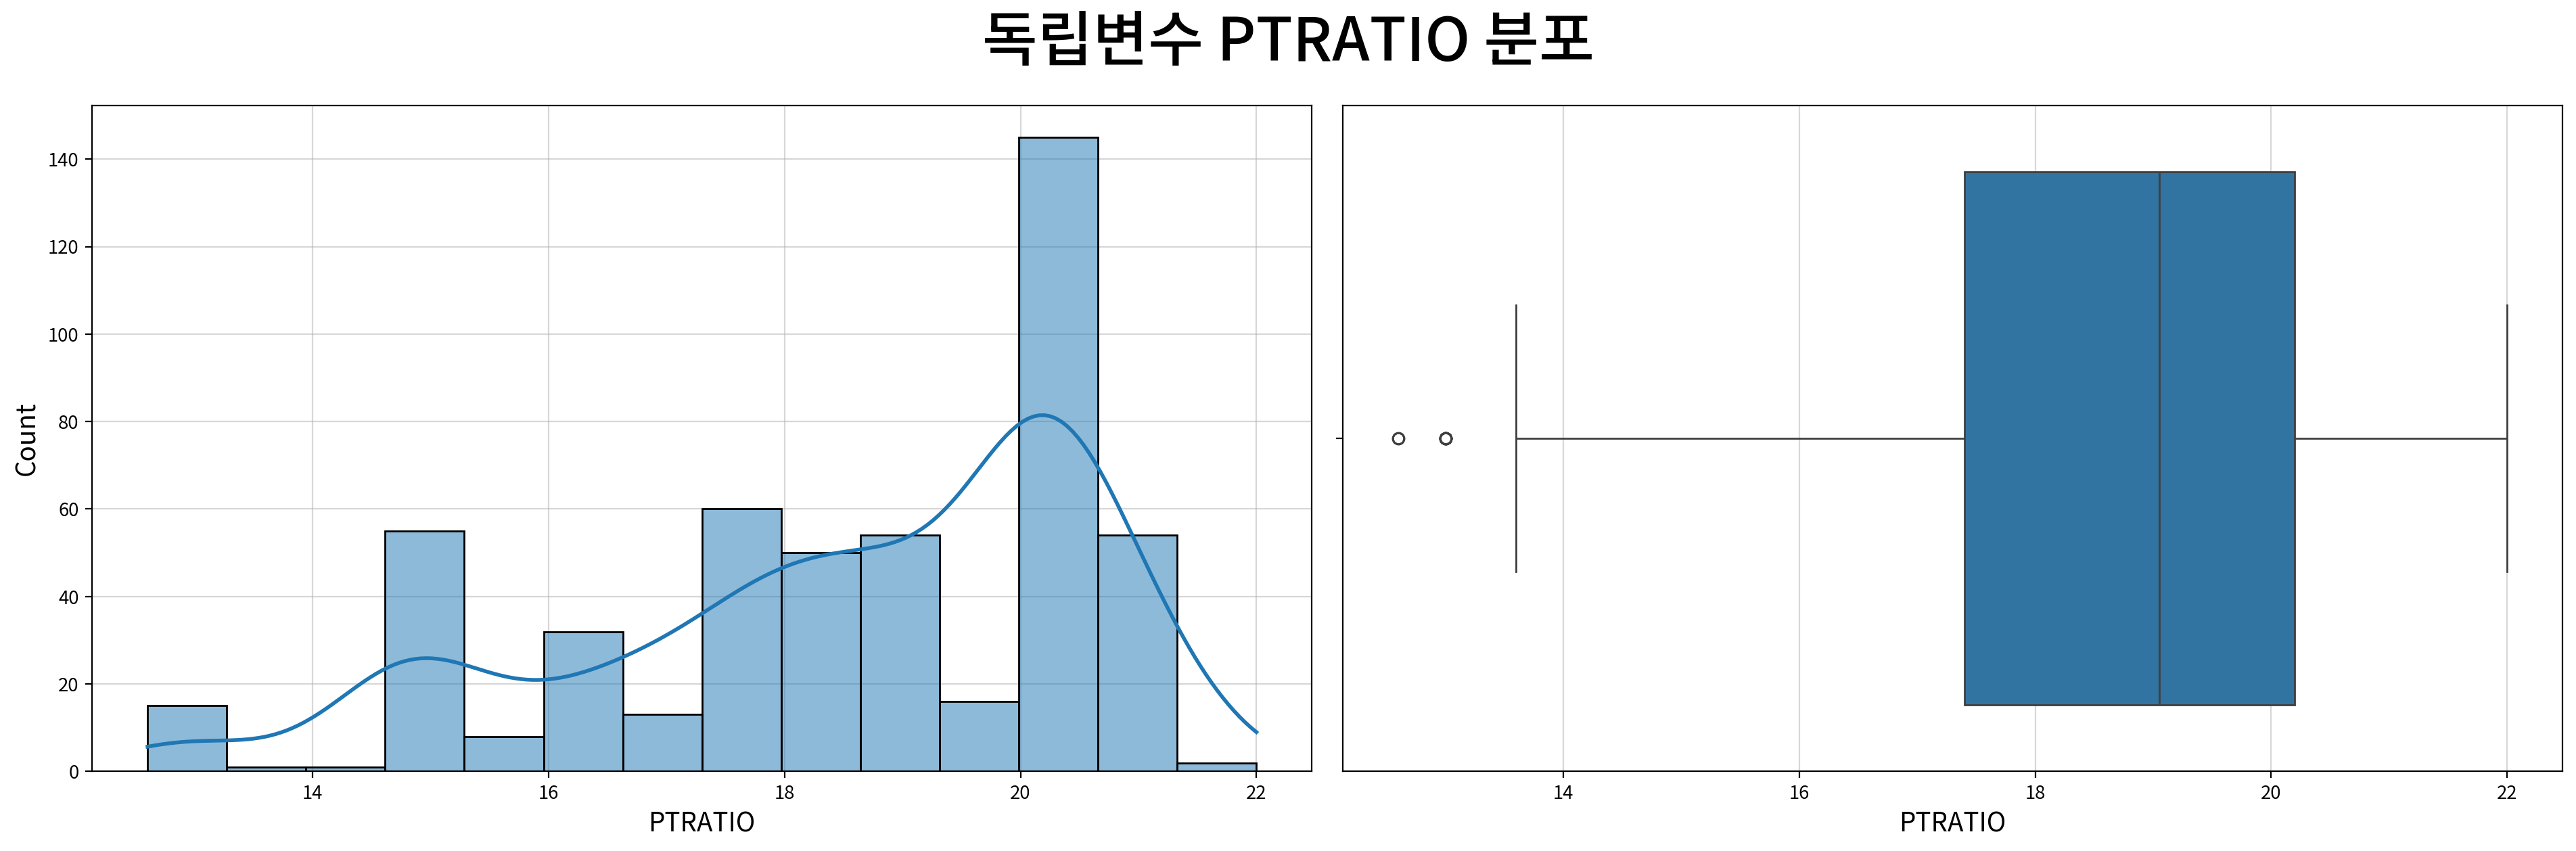

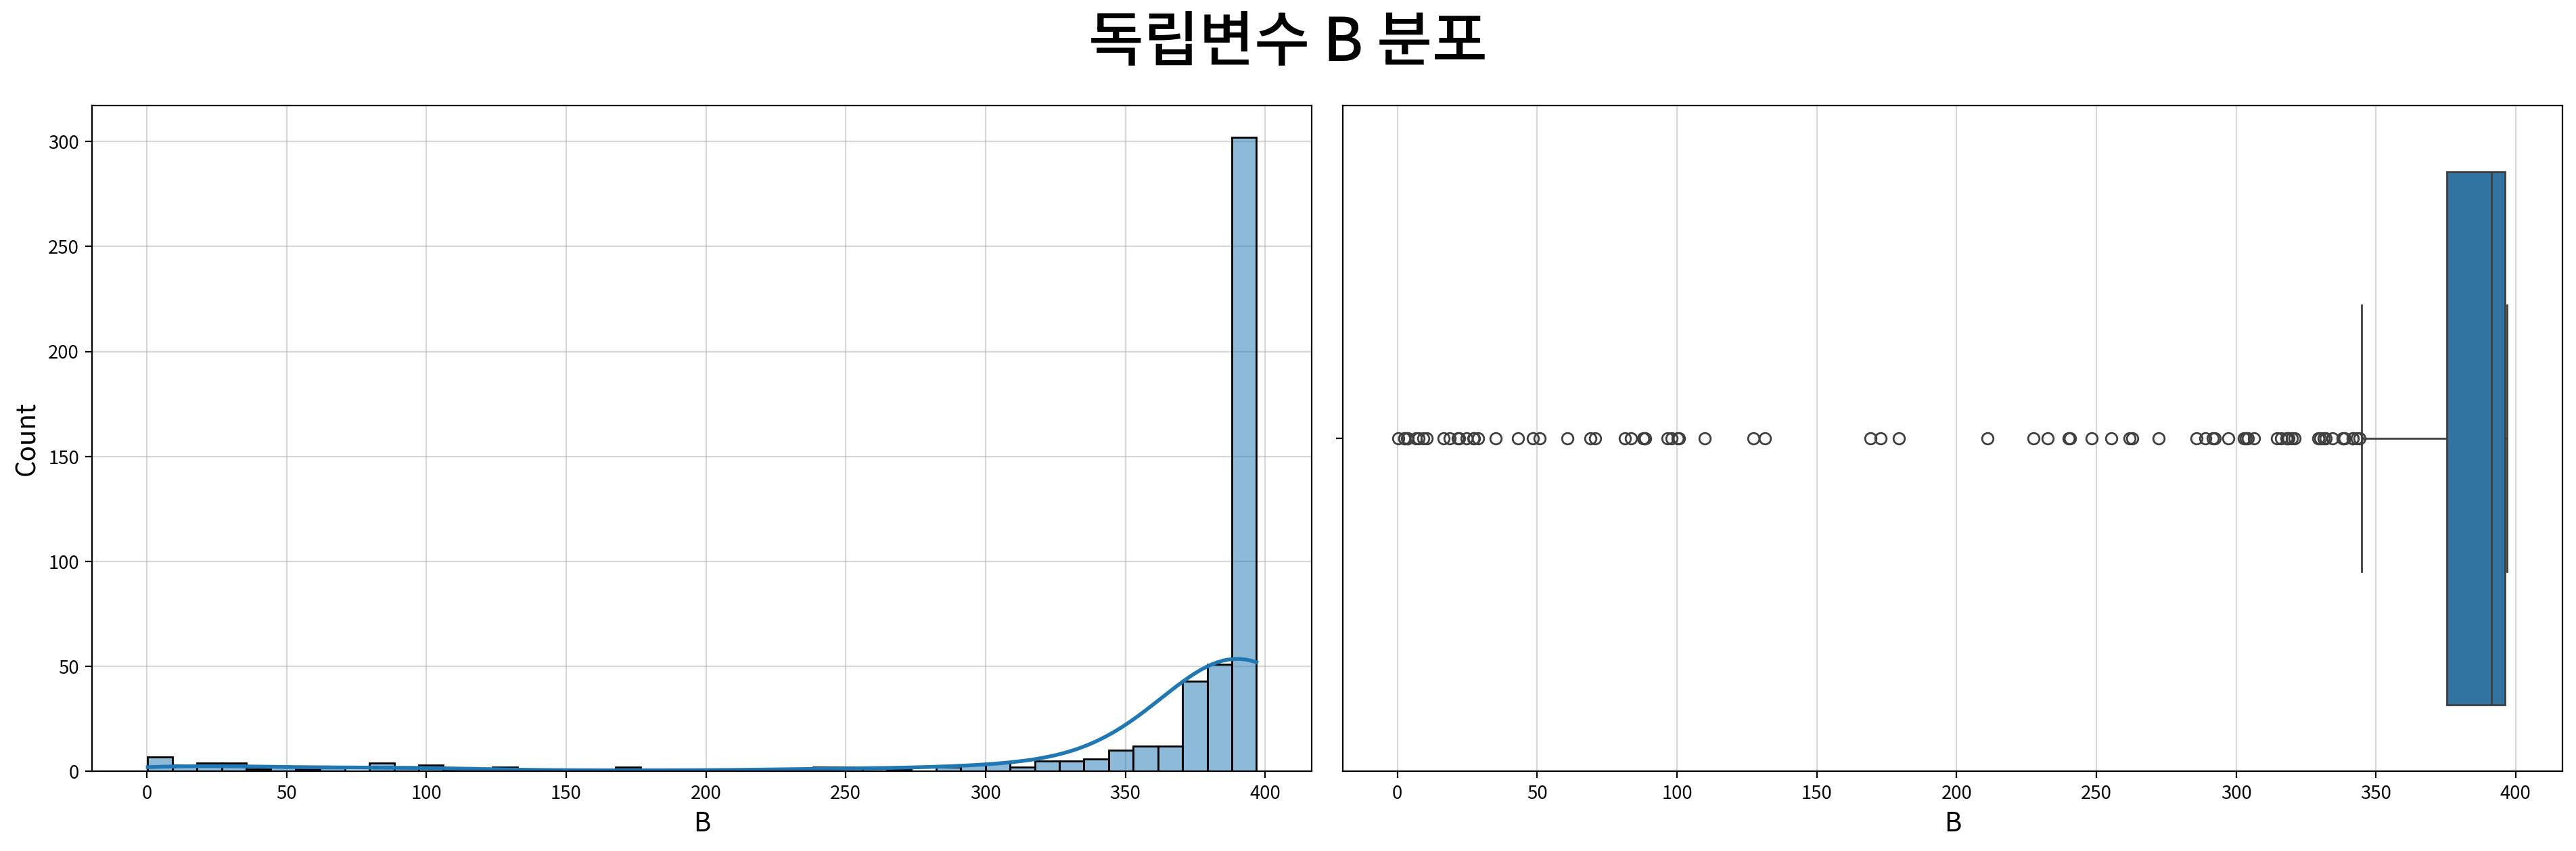

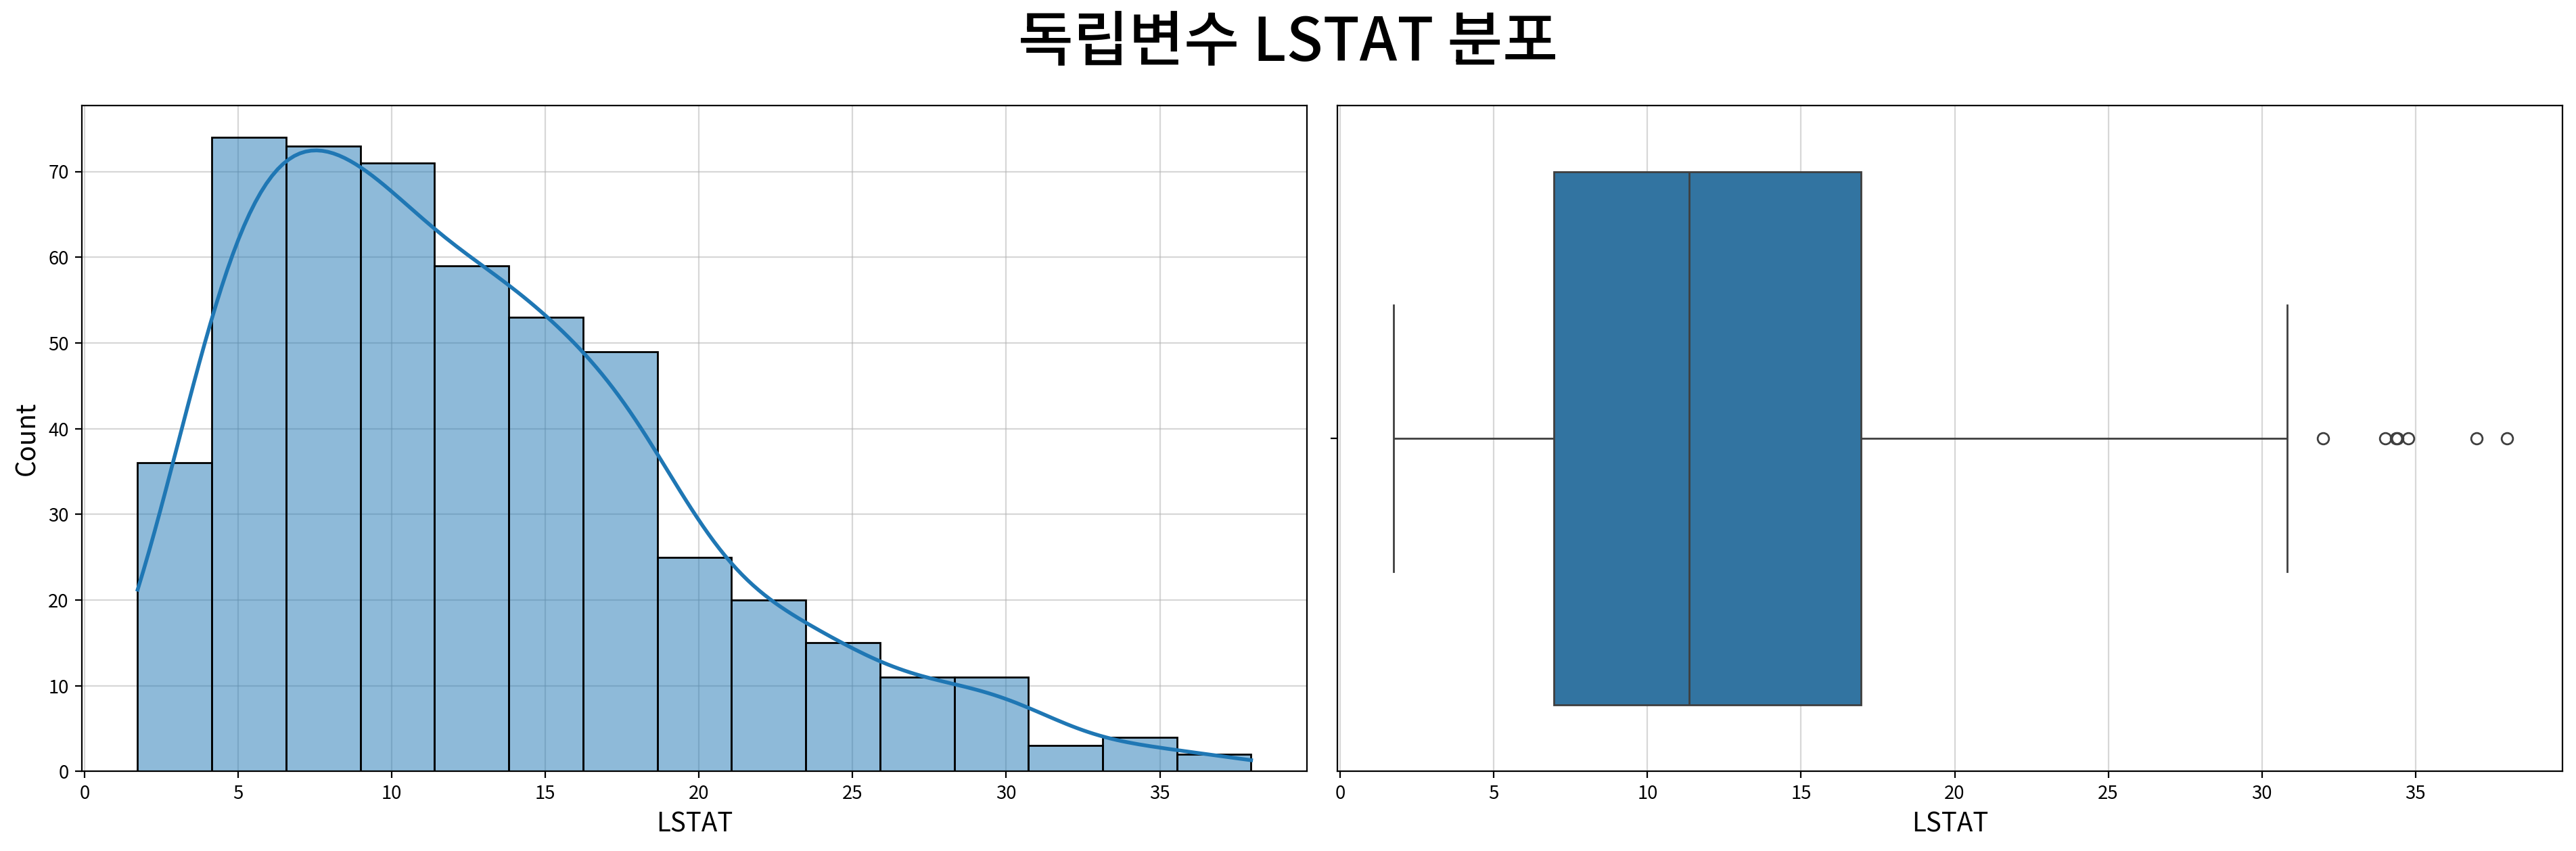

In [ ]:
for f in feature_continuous:
    fig, ax = my_plot.init(rows=1, cols=2, title=f'독립변수 {f} 분포', width=960, height=640)
    my_plot.histplot(data=df, x=f, kde=True, ax=ax[0])
    my_plot.boxplot(data=df, x=f, ax=ax[1])
    my_plot.show()

- 인사이트

| 변수 | 분포모양(왜도) | 봉우리 | 이상치 | 이산점(군집) | 판단/조치 |
|-|-|-|-|-|-|
| CRIM | 매우 강한 우편향 | 단봉, 0 근처 집중 | 많음 | - | 로그 변환 + 이상치 처리 고려 |
| ZN | 강한 우편향 | 0에 집중 | 있음 | 0과 일부 큰 값으로 분리 | 로그 변환 + 이상치 처리 고려 |
| INDUS | 약한 우편향 | 여러 구간에 분포 | 적음 | 산업지역 비율별 군집 | 그대로 사용 가능, 다봉만 유의 |
| NOX | 약한 우편향 | 단봉 | 일부 있음 | 낮은/높은 오염 수준 군집 | 그대로 사용 가능 |
| RM | 거의 대칭 | 단봉 | 일부 있음 | - | 그대로 사용 가능 |
| AGE | 좌편향 | 높은 값에 집중 | 적음 | 오래된 주택 비율 높음 | 그대로 사용 가능 |
| DIS | 우편향 | 단봉 | 일부 있음 | - | 로그 변환 고려 |
| RAD | 우편향 | 특정 값에 집중 | 있음 | 값이 이산적으로 분리 | 사실상 범주형 -> 선형 가정 주의 |
| TAX | 우편향 | 여러 봉우리 | 일부 있음 | 세금 구간별 군집 | 그대로 사용 가능 |
| PTRATIO | 약한 좌편향 | 단봉 | 일부 있음 | - | 그대로 사용 가능 |
| B | 강한 좌편향 | 큰 값에 집중 | 많음 | - | 역로그 변환 + 이상치 처리 |
| LSTAT | 우편향 | 단봉 | 일부 있음 | - | 로그 변환 고려 |

### 3. 명목형 독립변수 분포 시각화

,빈도,비율(%)
CHAS,,
0,471,93.100
1,35,6.900


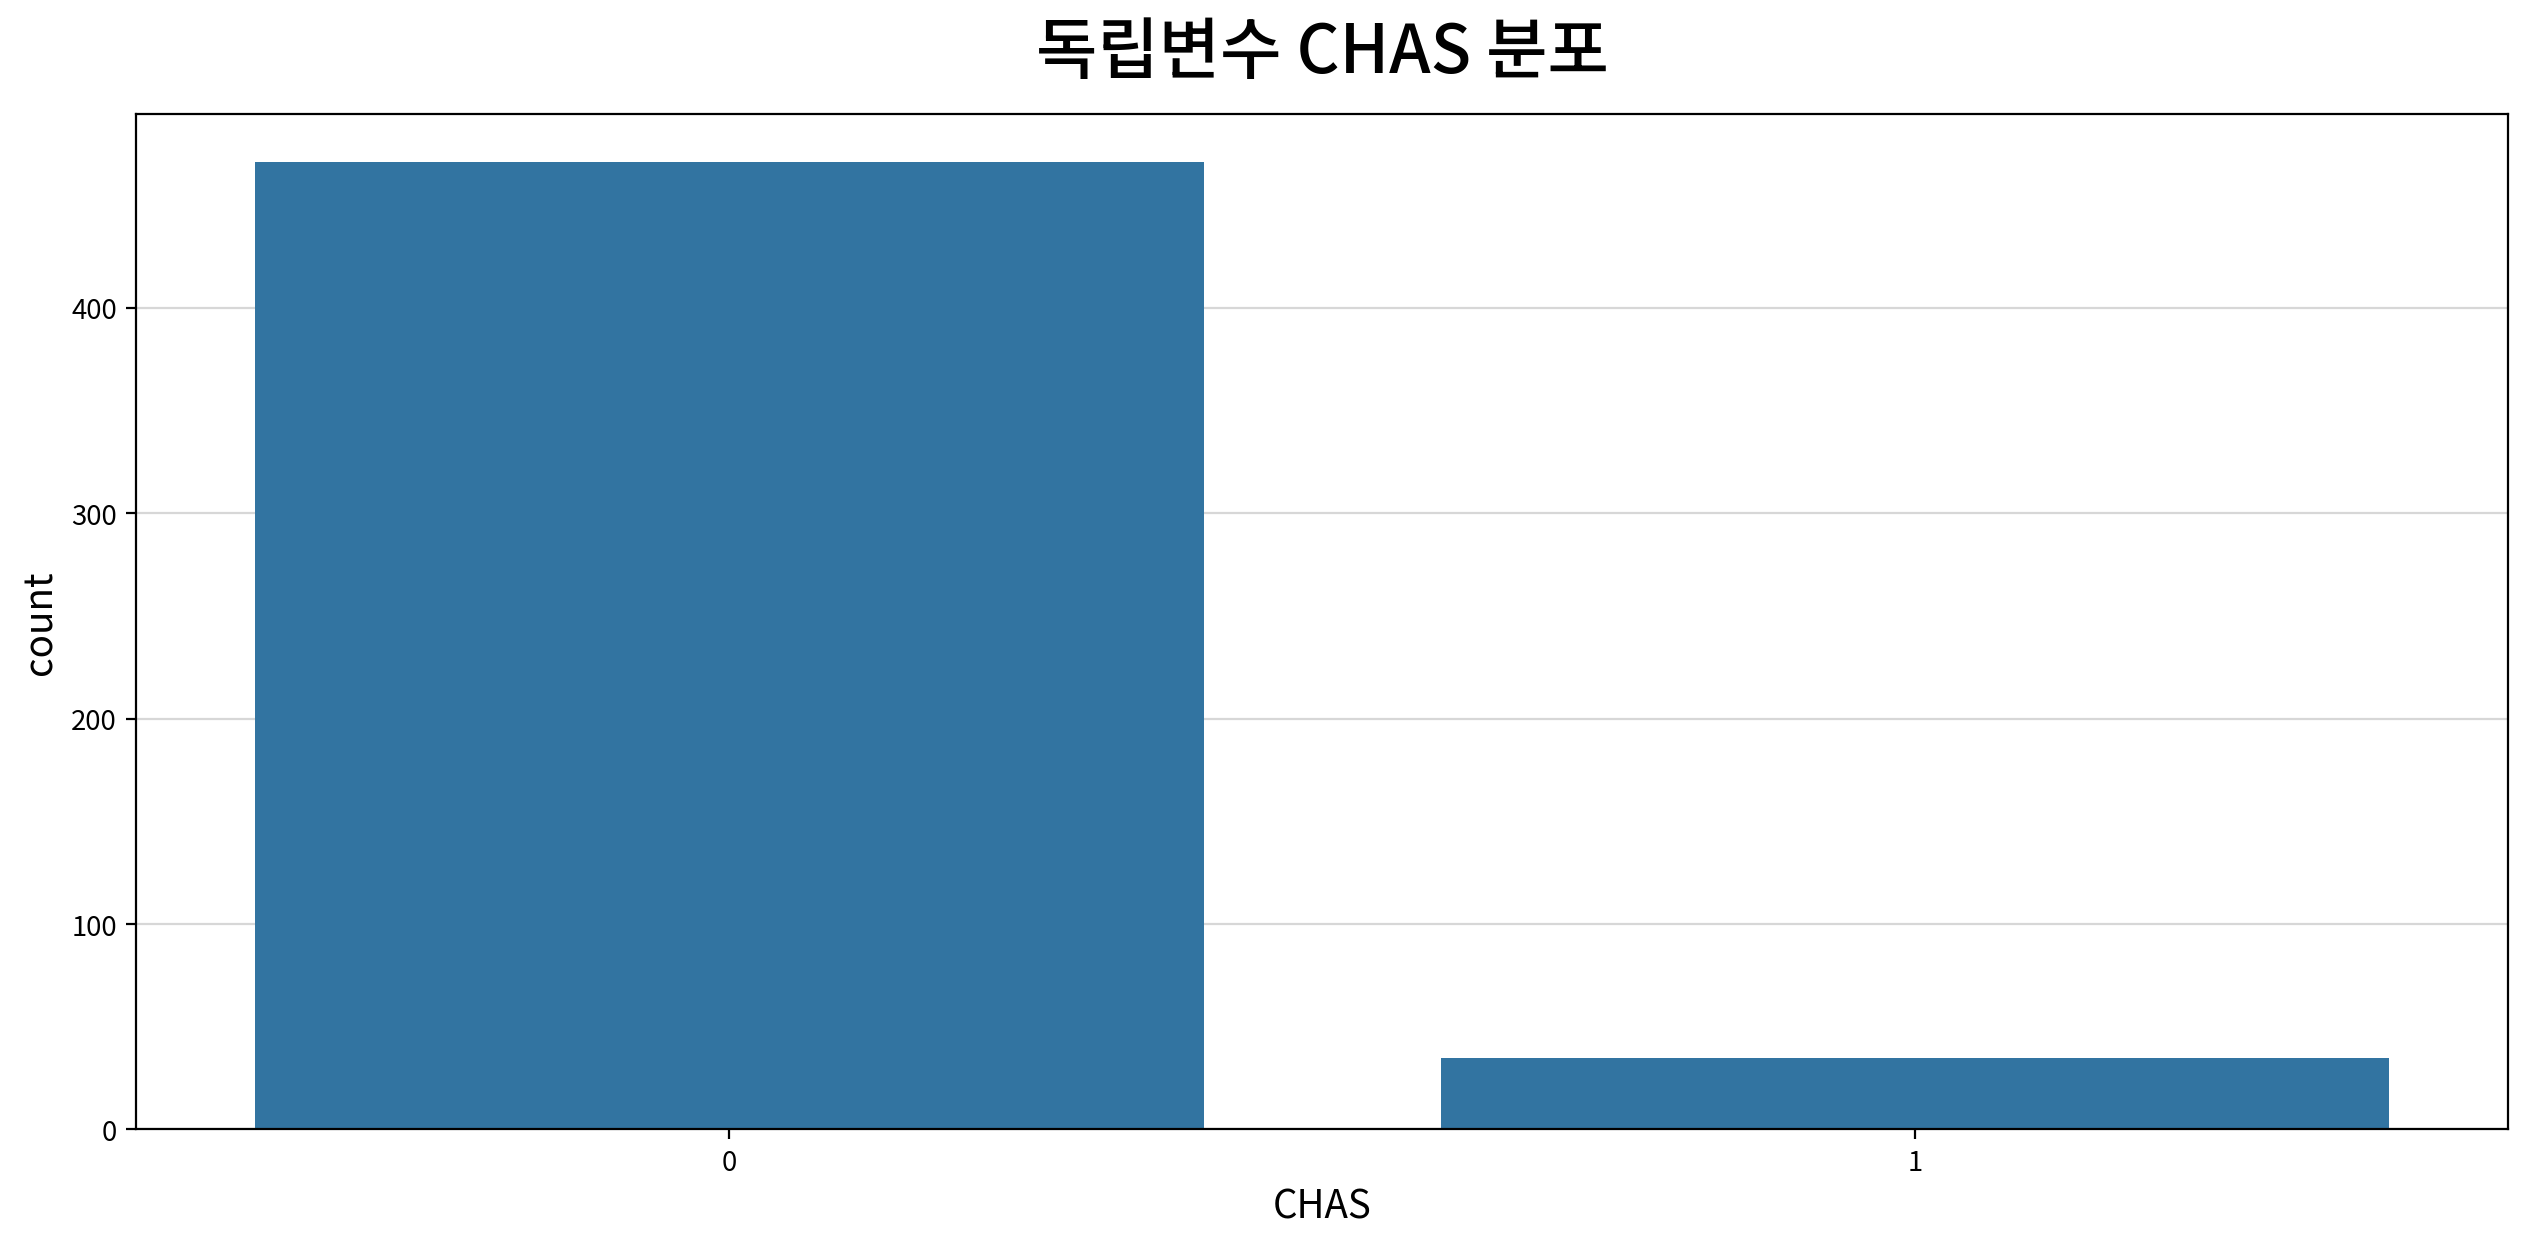

In [25]:
for n in nominal_cols:
    # 빈도표 - 명목형 분포를 수치로
    freq = df[n].value_counts().rename("빈도").to_frame()
    freq['비율(%)'] = (df[n].value_counts(normalize=True) * 100).round(1)
    display(freq)

    # 명목형 분포는 카운트 플롯으로 처리한다.
    my_plot.countplot(data=df, x=n, title=f'독립변수 {n} 분포')

- 인사이트
    - 명목형은 분포 모양, 왜도 대신 범주의 균형/불균형을 점검하여 그대로 검정/모델에 넣어도 되는가를 판단한다.

|변수|범주 수|빈도(비율)|균형 여부|판단/조치|
|-|-|-|-|-|
|CHAS|2 (0=강변 아님, 1=강변 인점)|0:471(93.1%), 1=35(6.9%)|심한 불균형|2집단이므로 MEDV 와의 T검정 대상이나, 소수집단(35건)이라 해석 신중|

- CHAS는 2집단 명목형이므로 종속변수(MEDV)와의 차이는 T검정으로 확인한다.
- 다만 강변 인접 집단이 35건 뿐이라 표본 불균형 즉 검정력이 낮고, 모델 투입 시 소수 집단의 효과가 과소 혹은 과대 추정될 수 있어 결과를 단정하기 말고 신중히 해석한다.
- 소수 집단이라도 강변 인접이 가격에 유의미한 프리미엄을 주는지 검정으로 확인할 가치가 있으므로 버리지 않고 유지한다.

## #03. 이변량 데이터 시각화
- 목표변수(MEDV)와 각 설명변슈의 관계(패턴)를 눈으로 확인하는 단계다
- 모든 시각화는 짝이 되는 검정과 연결된다.
    - 연속형 ↔ 연속형 → 산점도 → 상관분석
    - 명목형(2집단) ↔ 연속형 → 박스플롯, 바이올린 → T검정
- 여기서 발견한 것인 아직 "후보패턴"이며, 다음 추론통계 단계에서 숫자로 검증한다.

### 1. 연속형 독립변수 ↔ 종속변수(산점도 → 상관분석)
- 연속형 설명변수와 종속변수(MEDV)의 관계는 산점도로 본다.
- 관계의 방향(증가/감소), 모양(선형/곡선), 산포, 이상치를 동시에 확인 -> 짝이 되는 검정은 상관분석

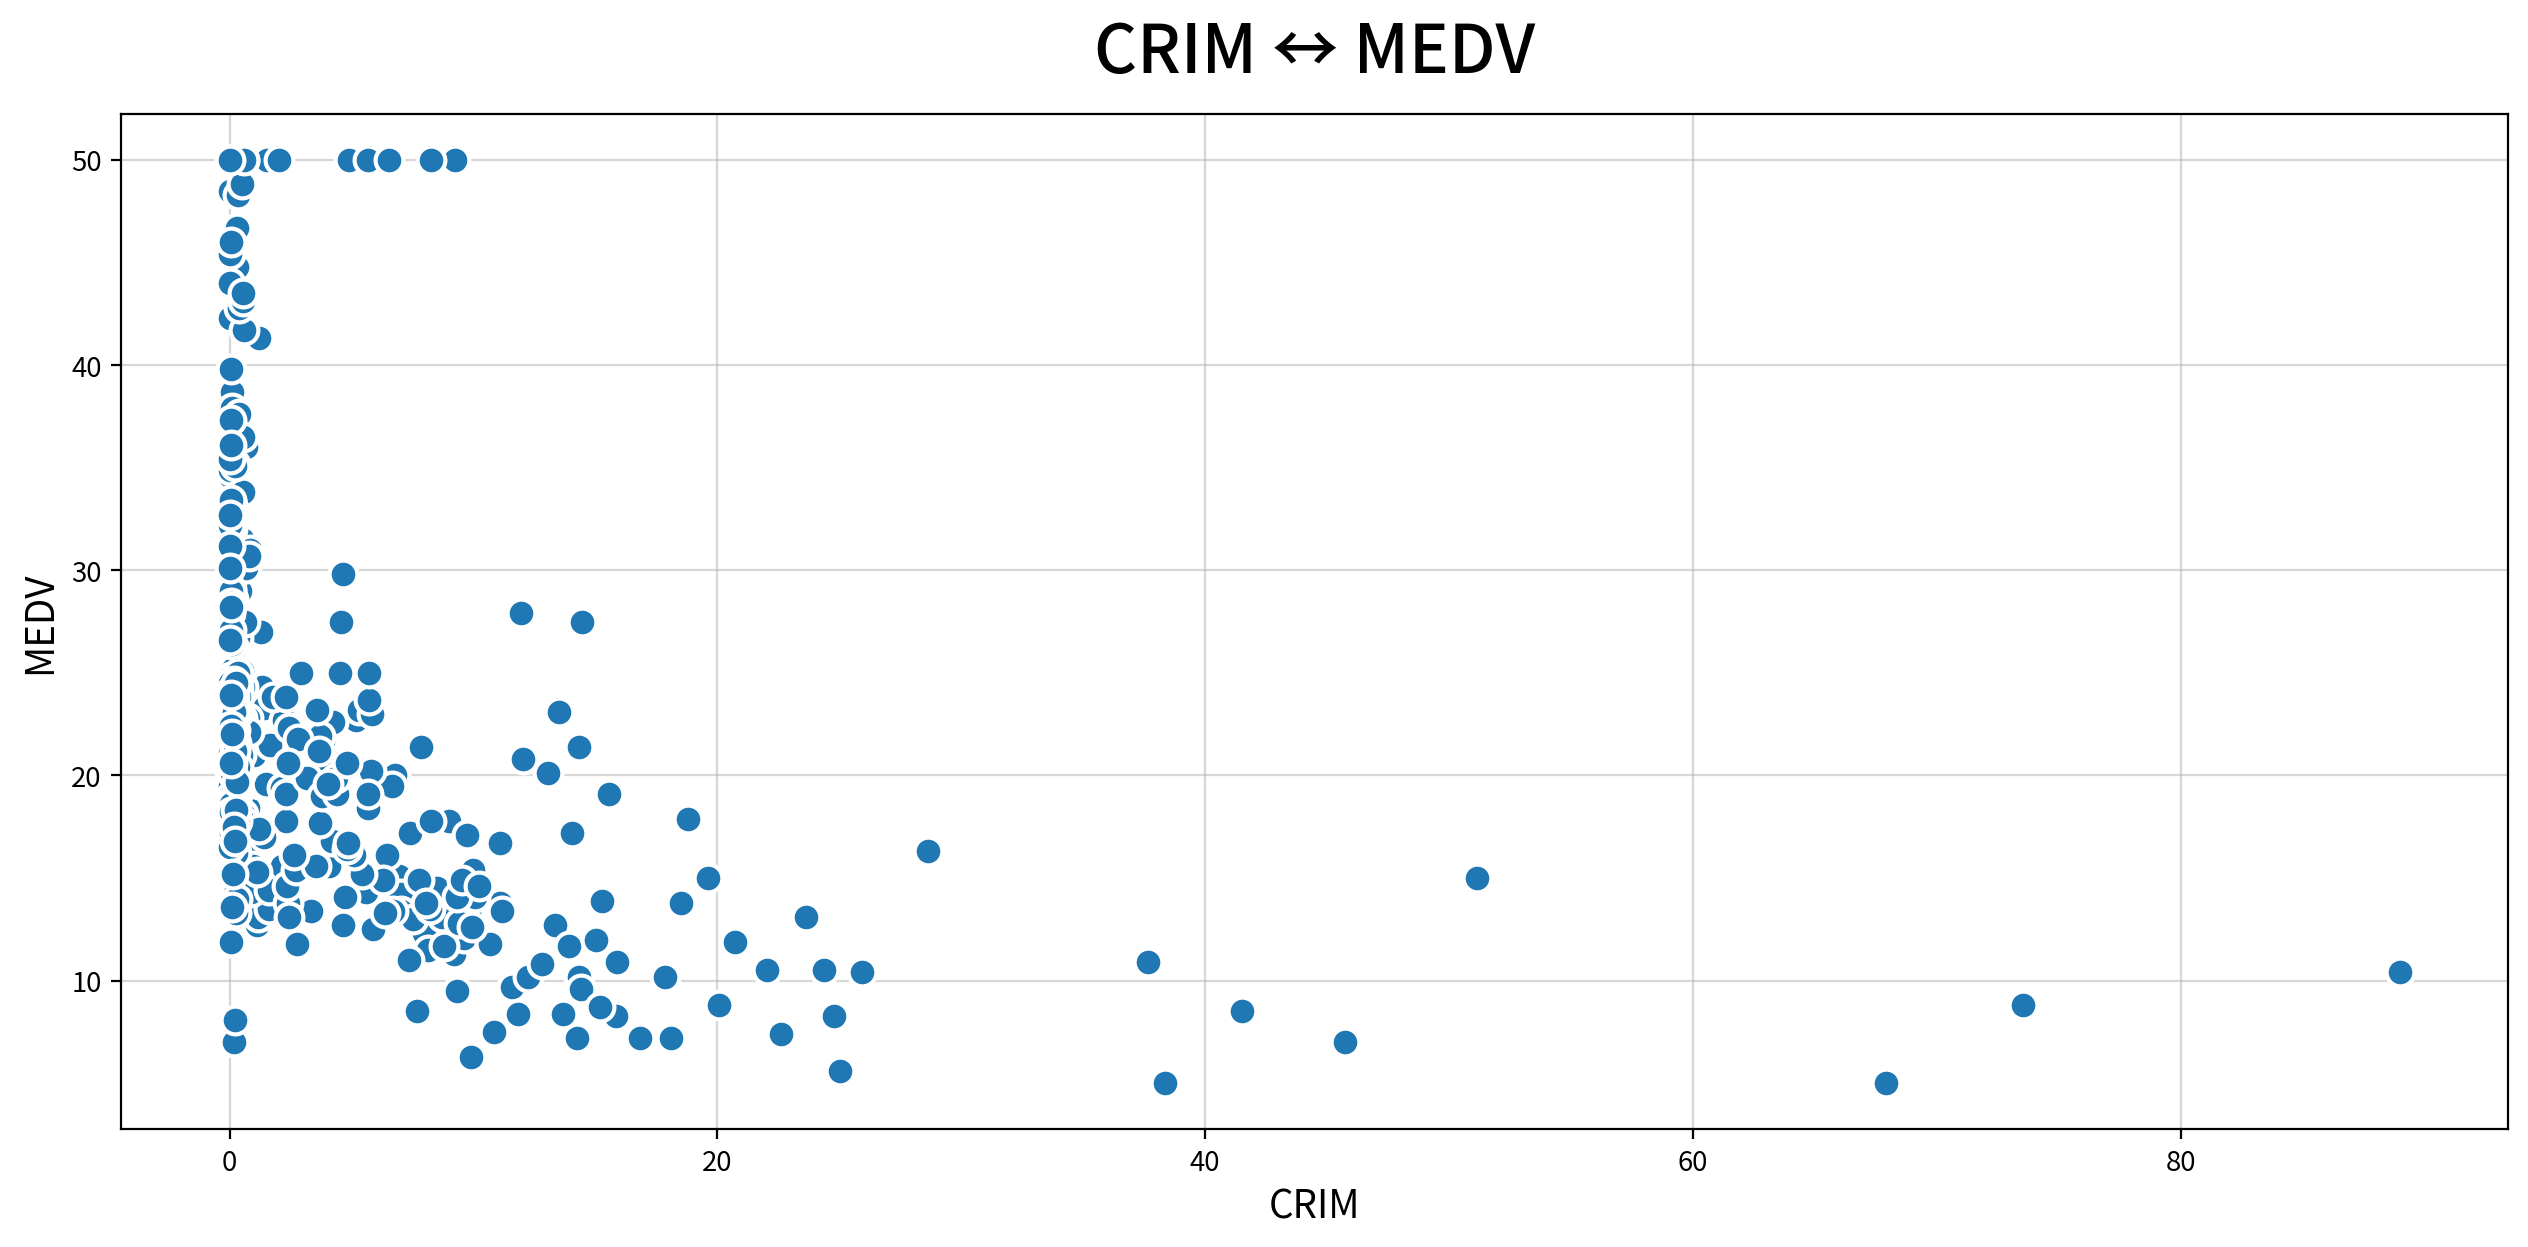

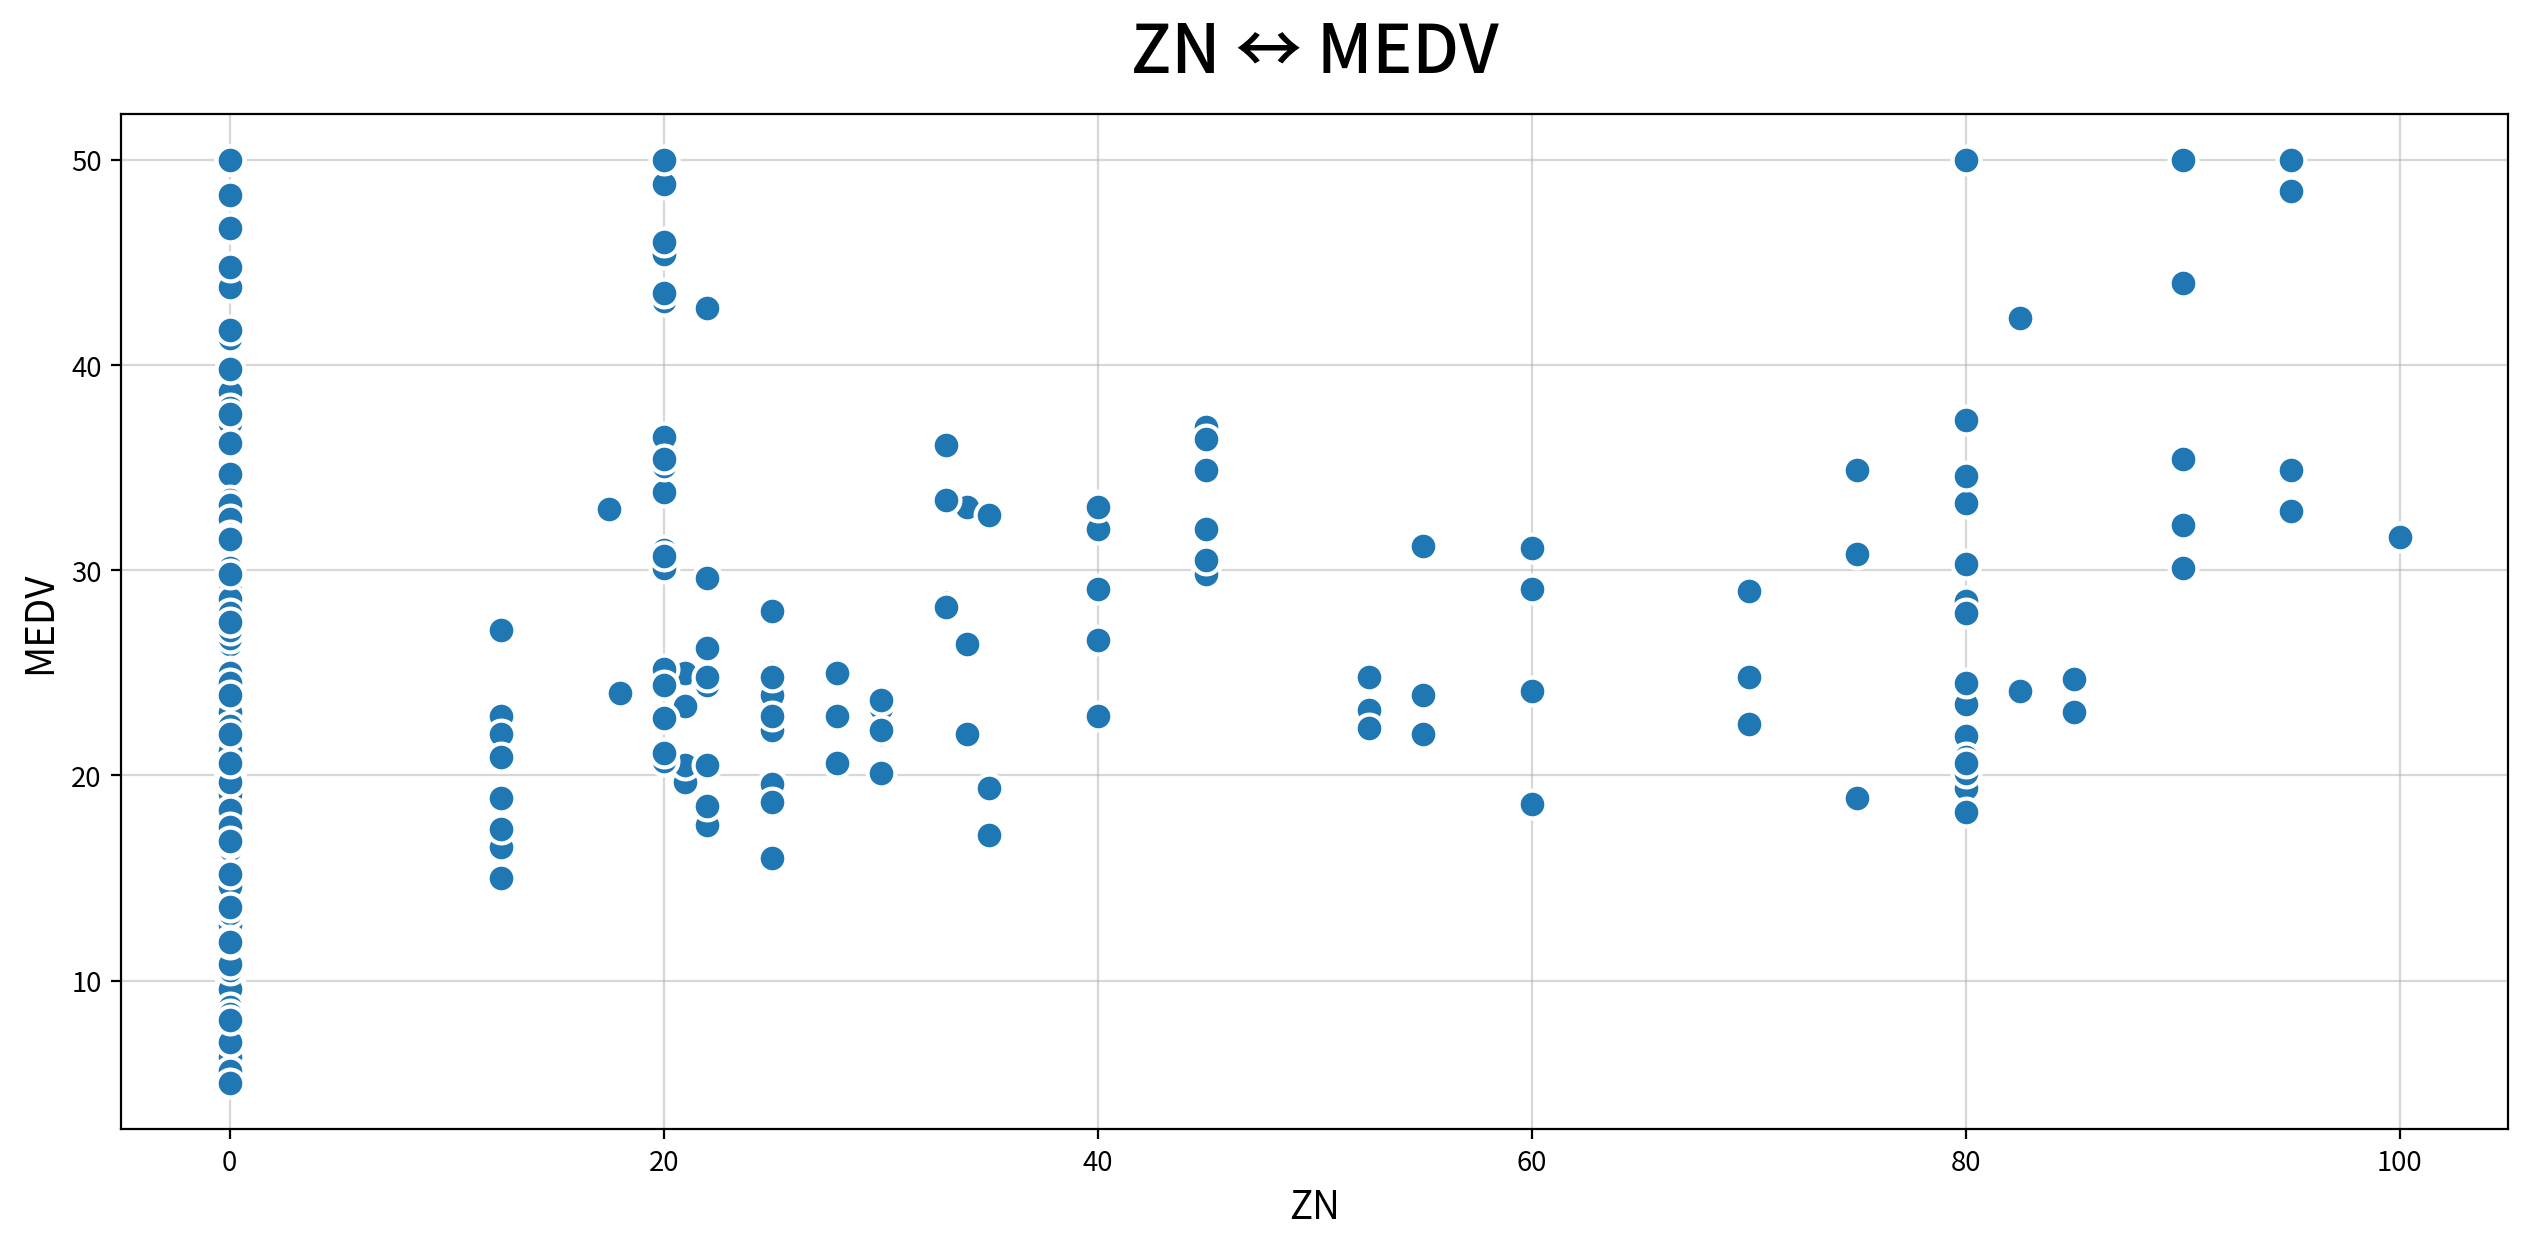

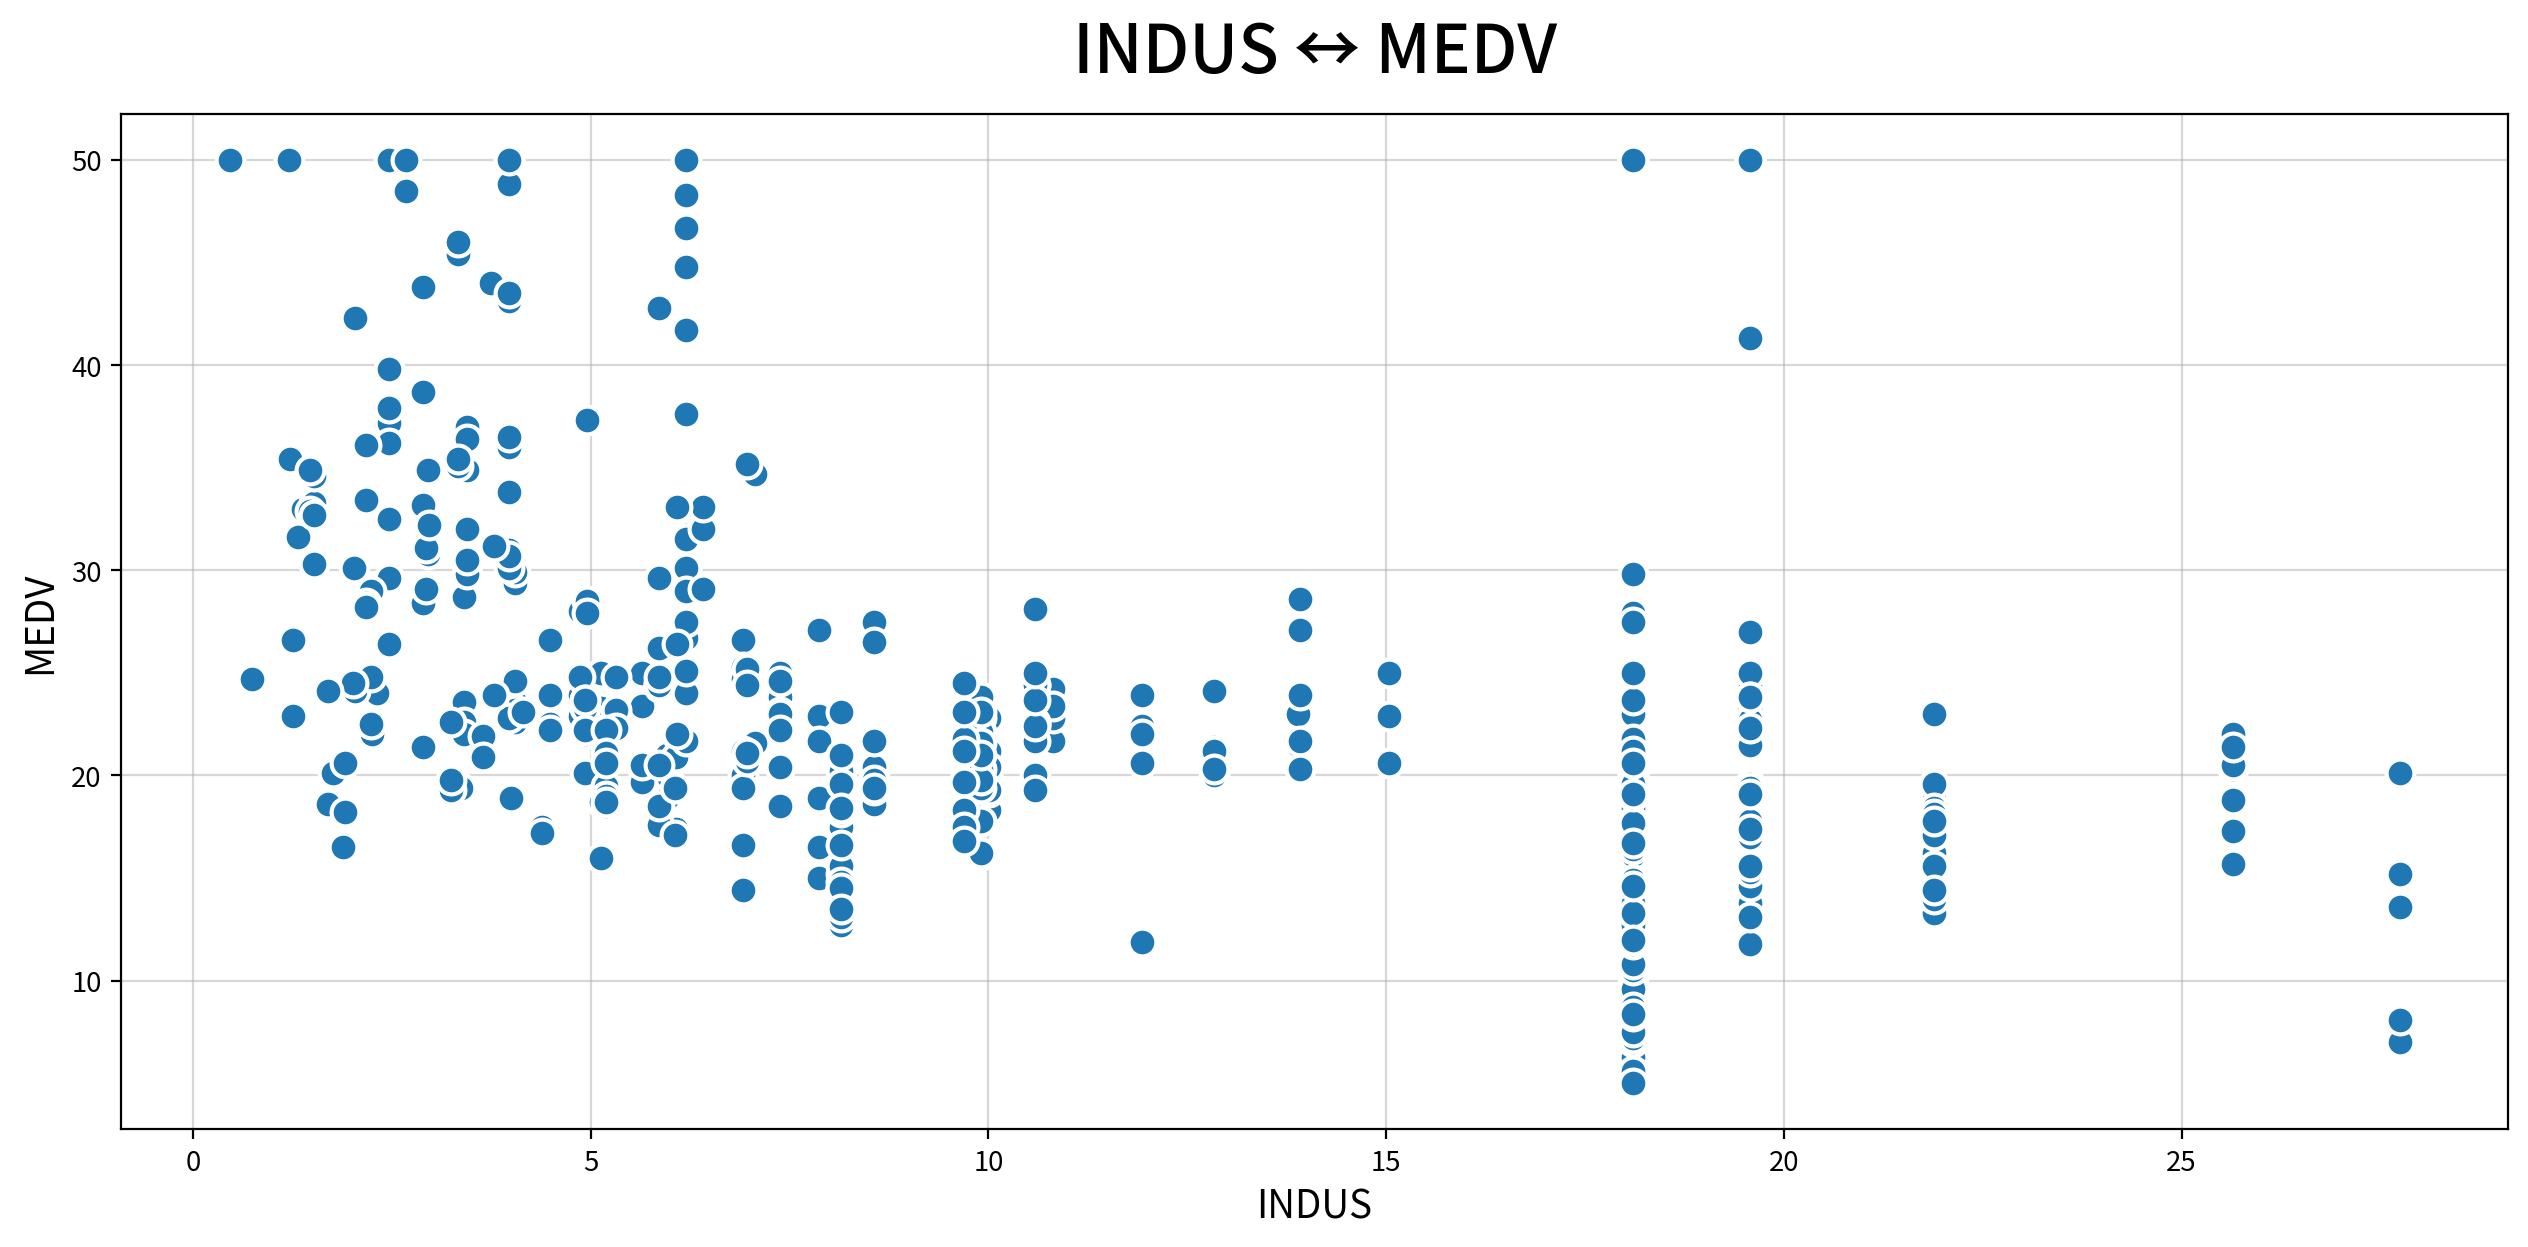

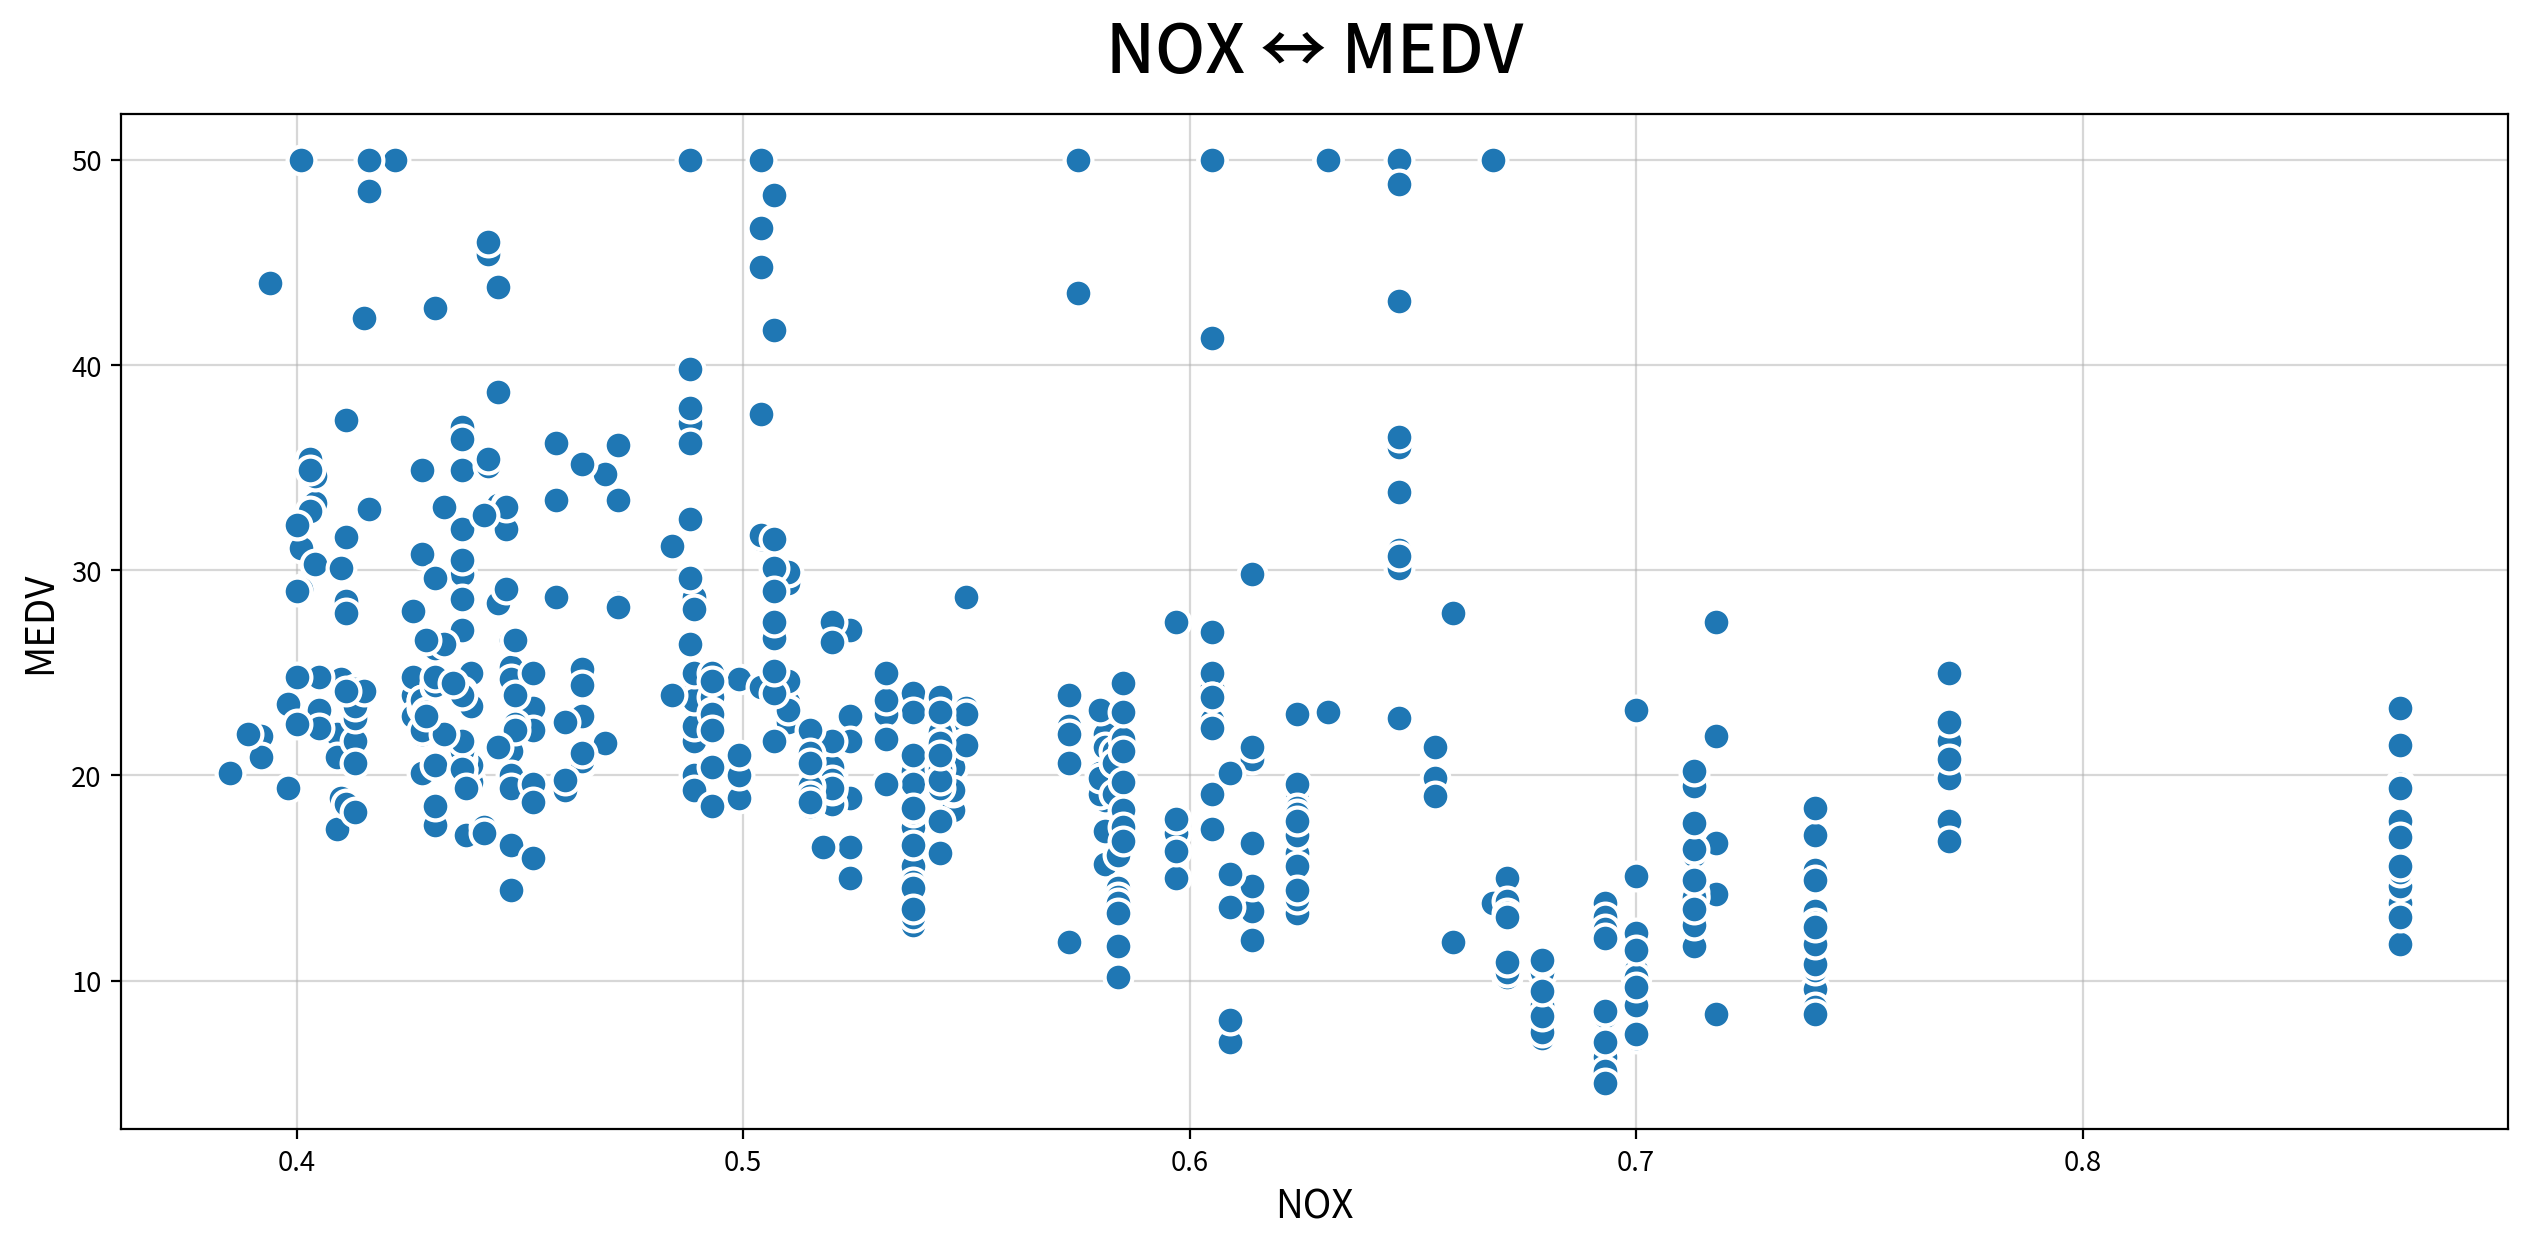

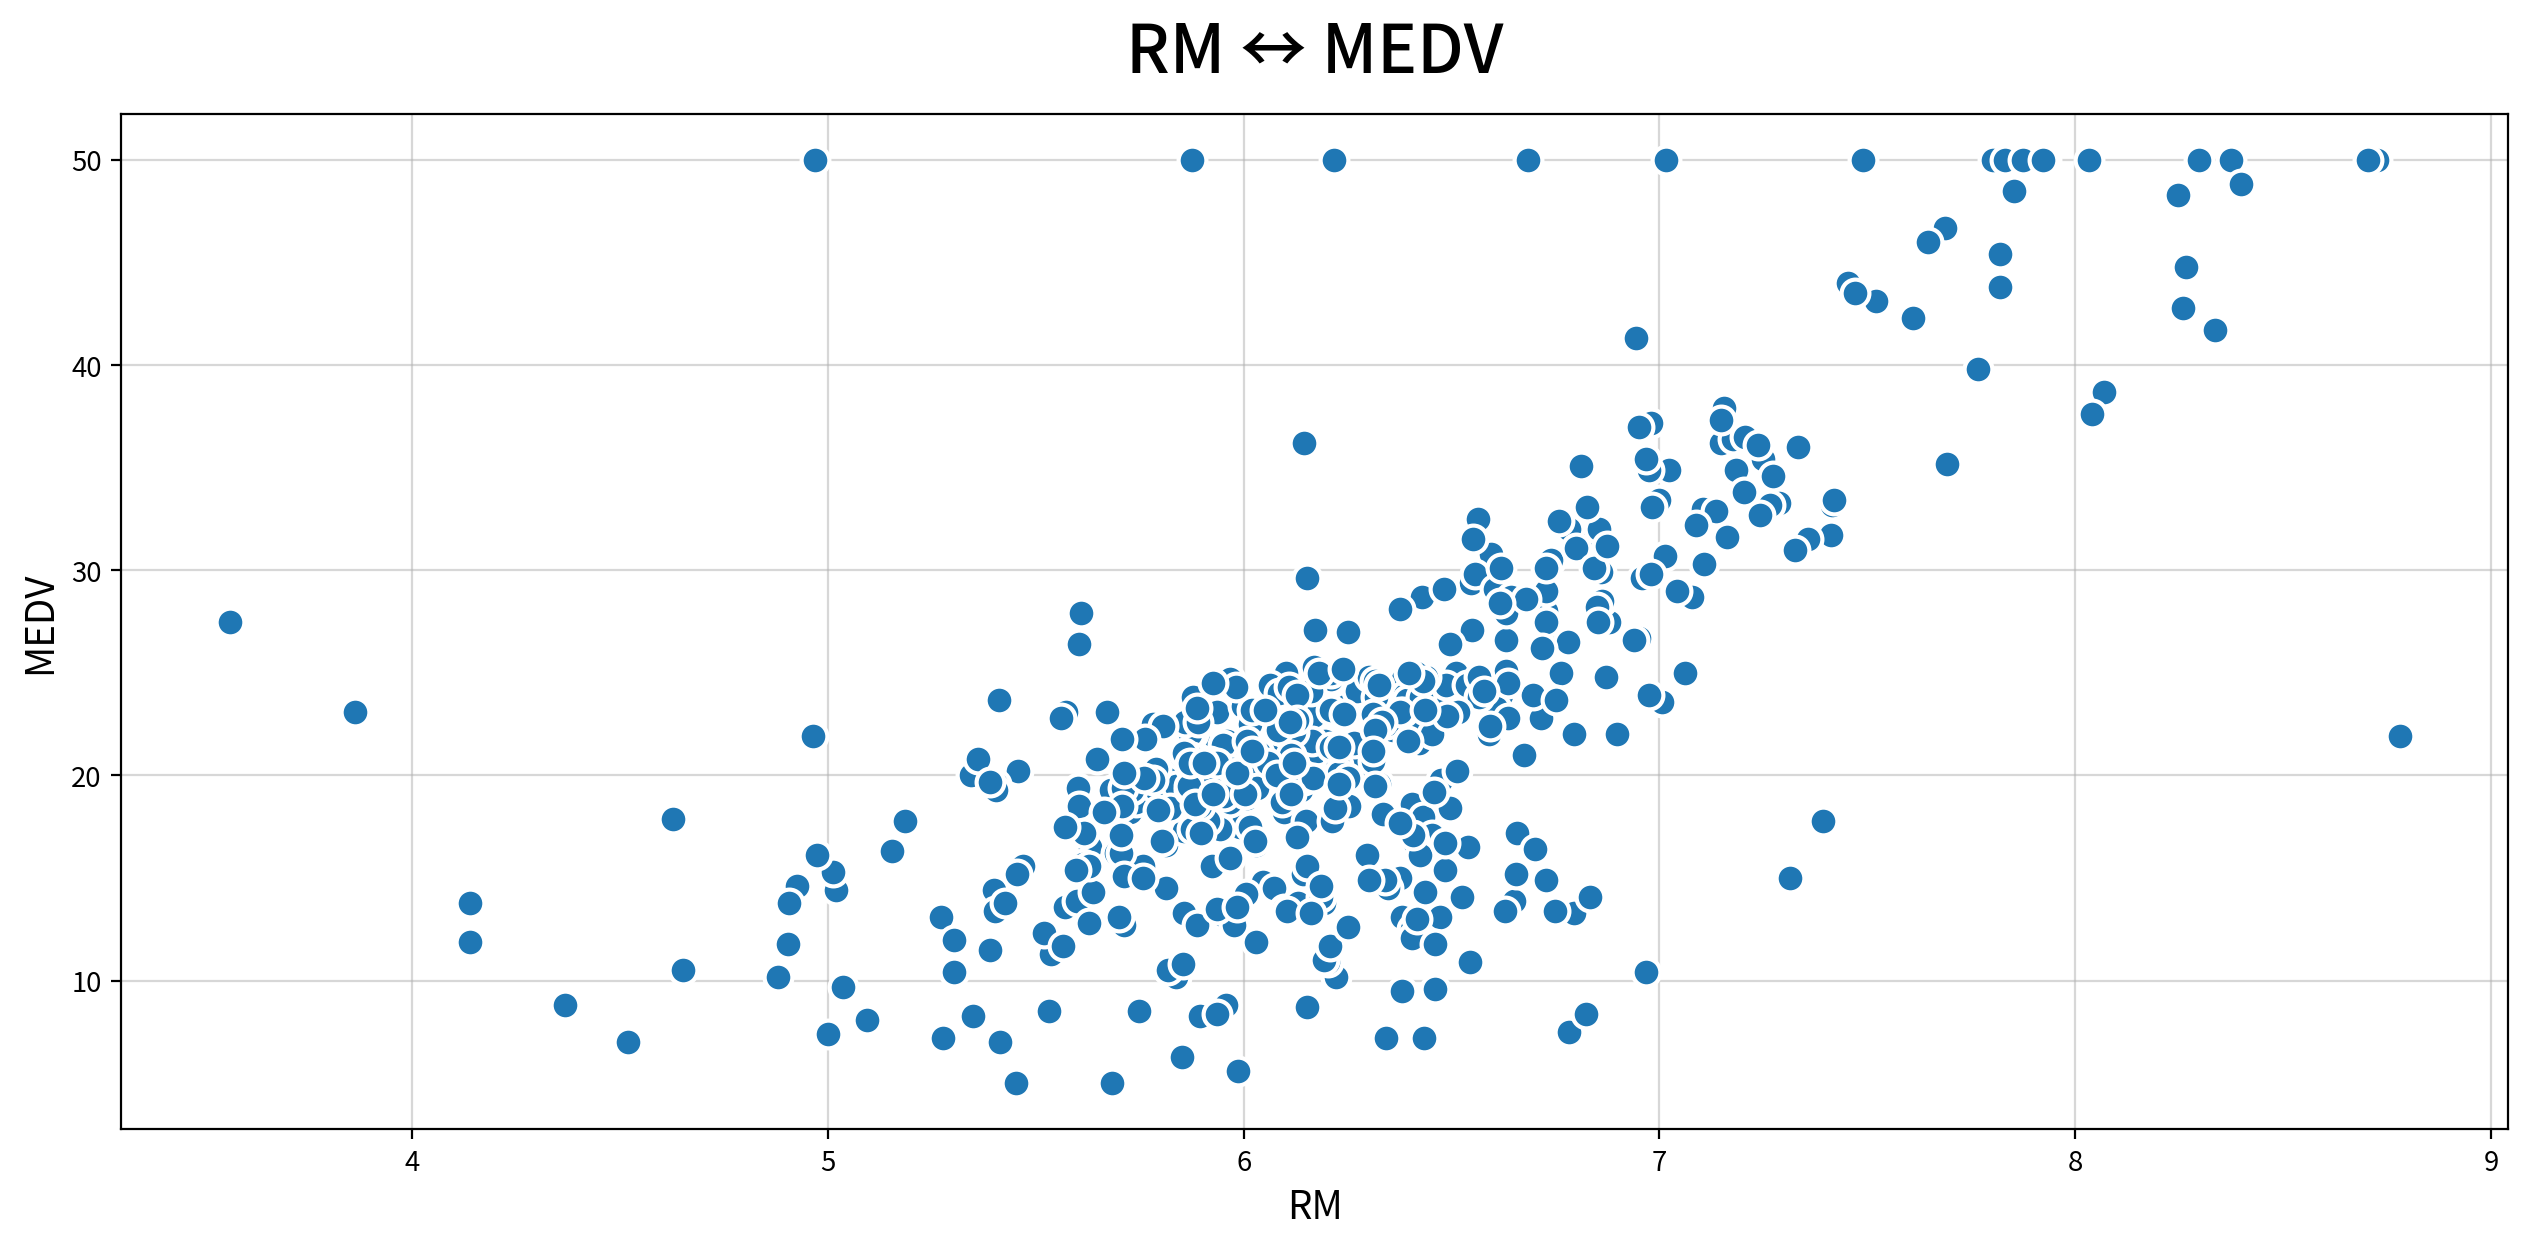

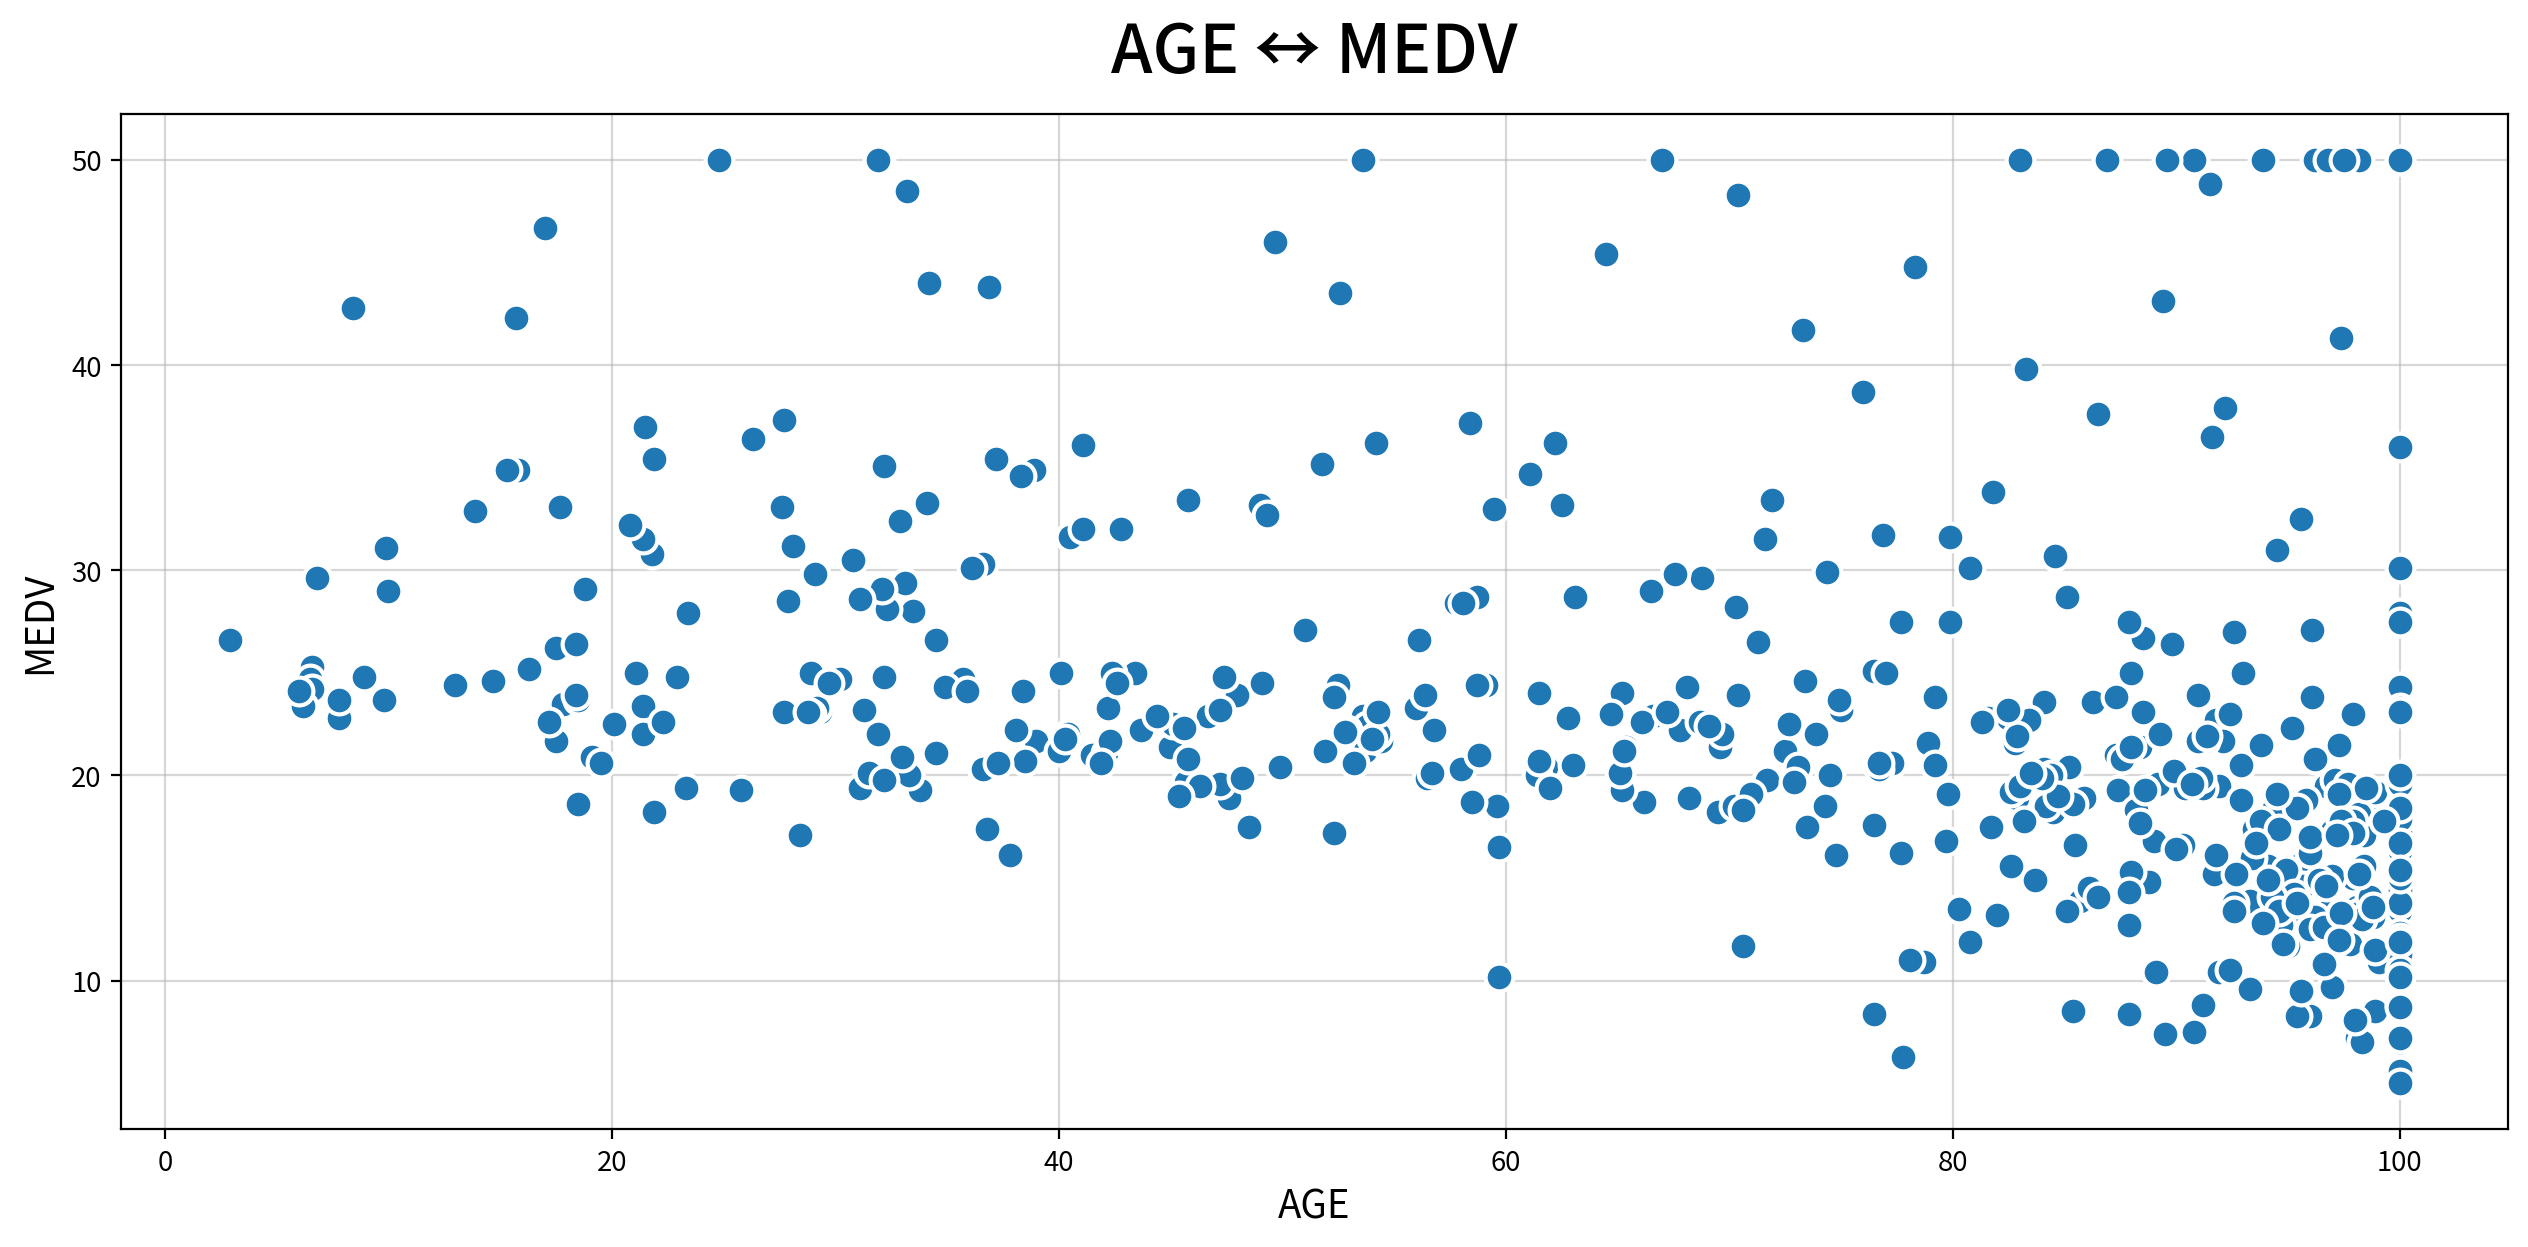

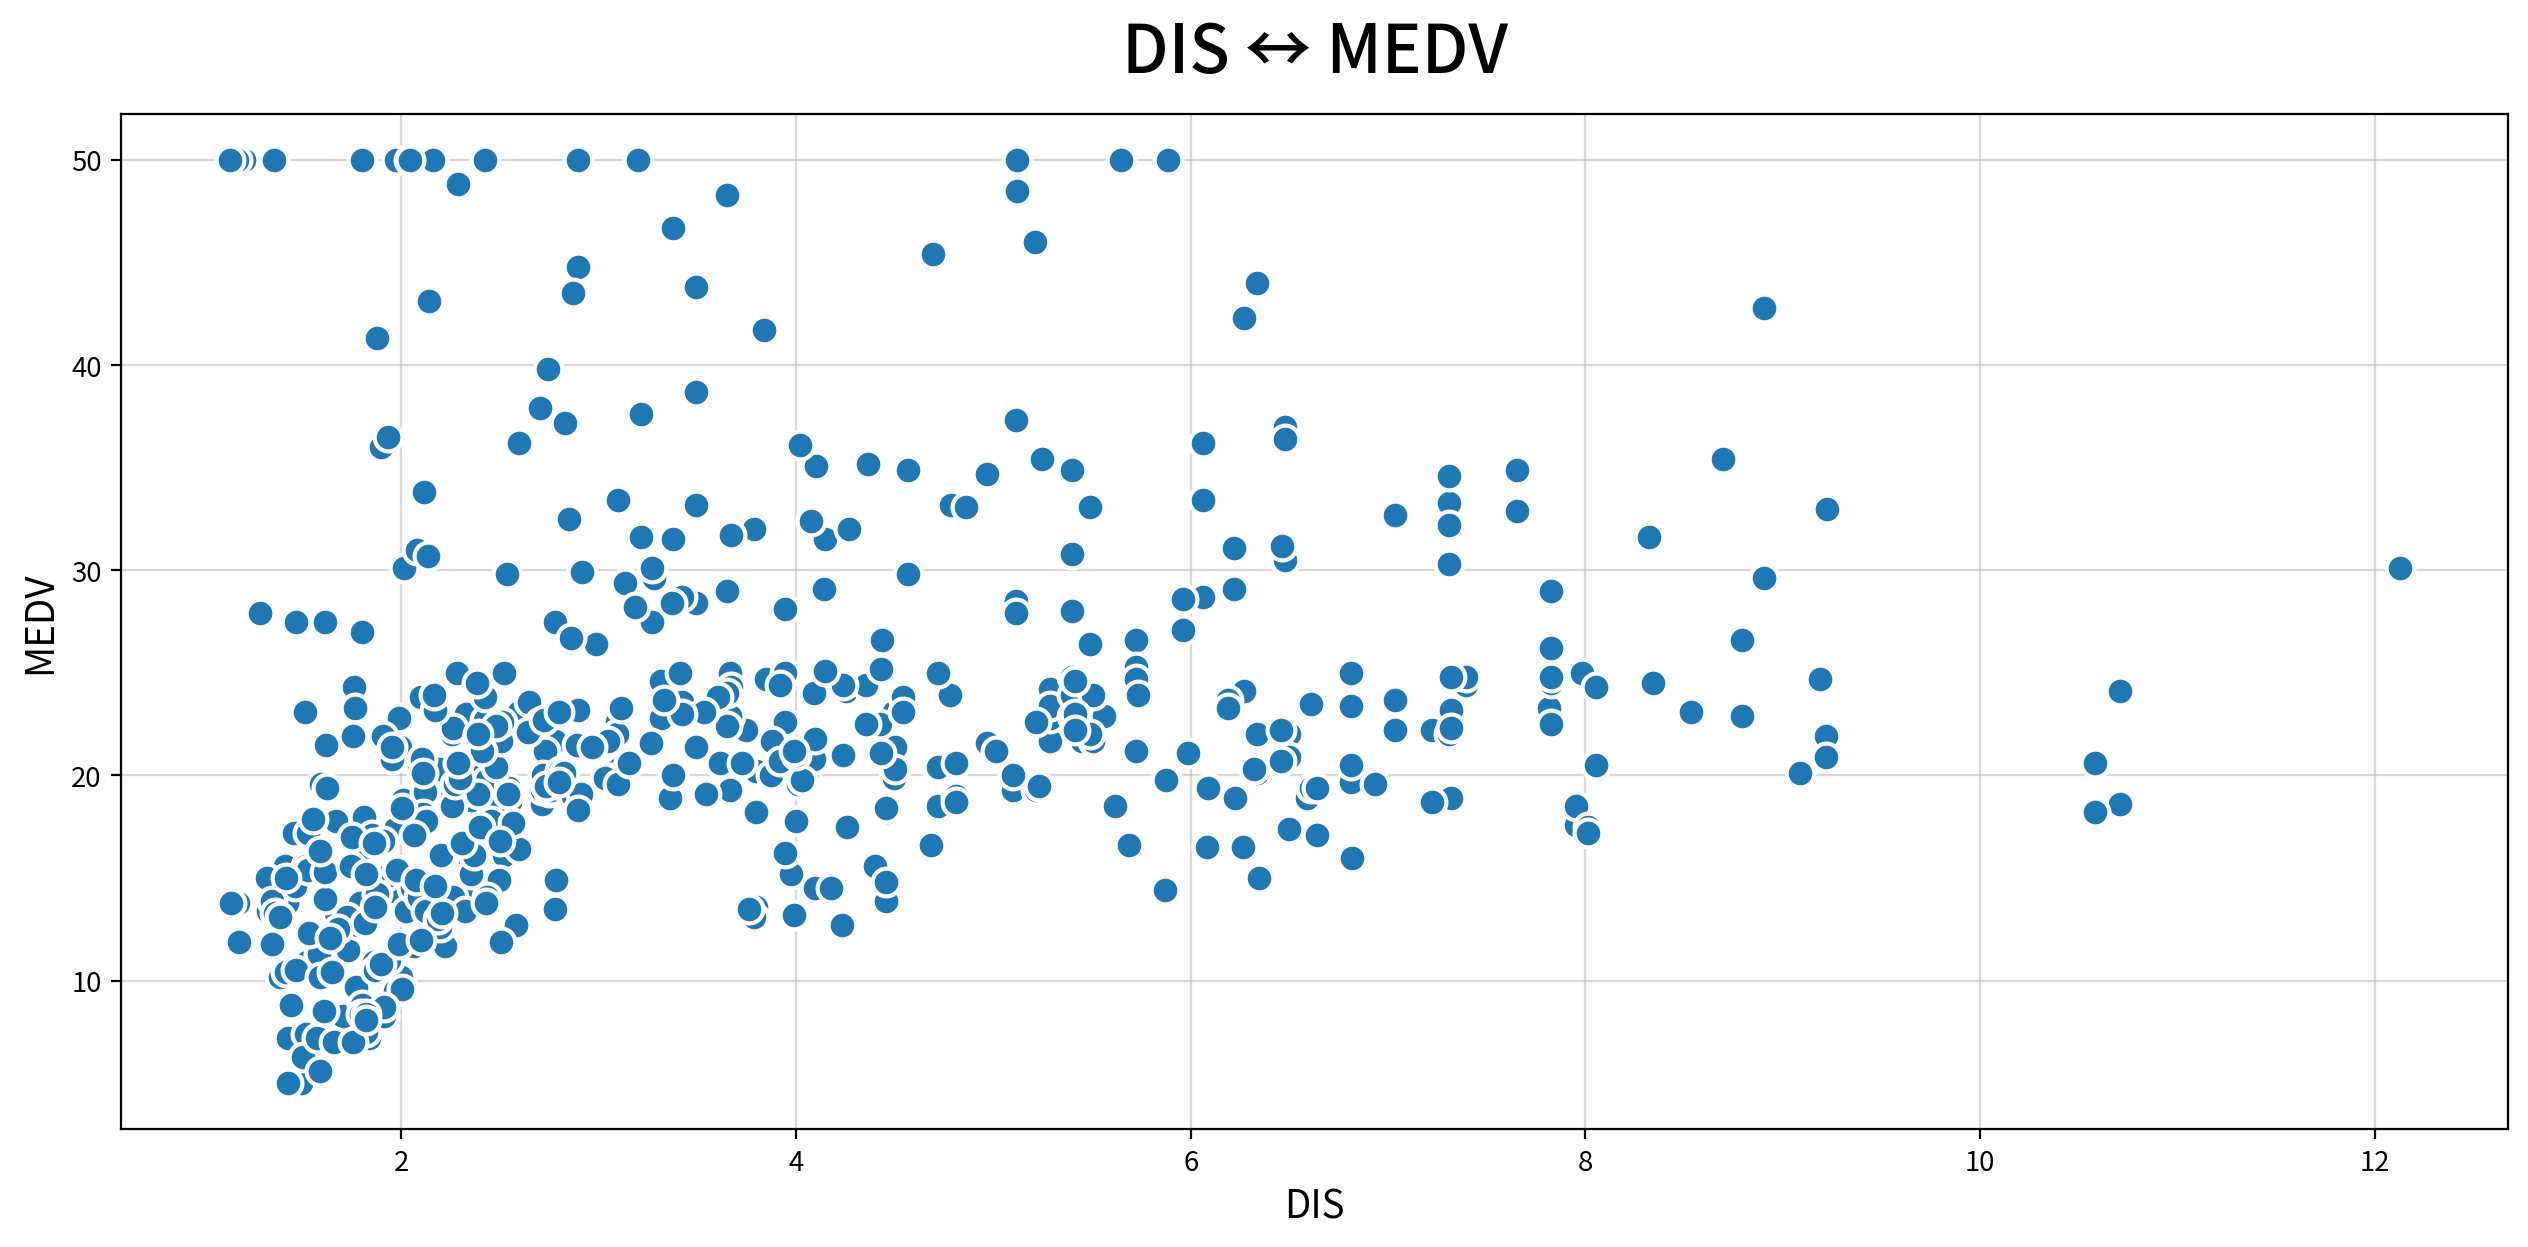

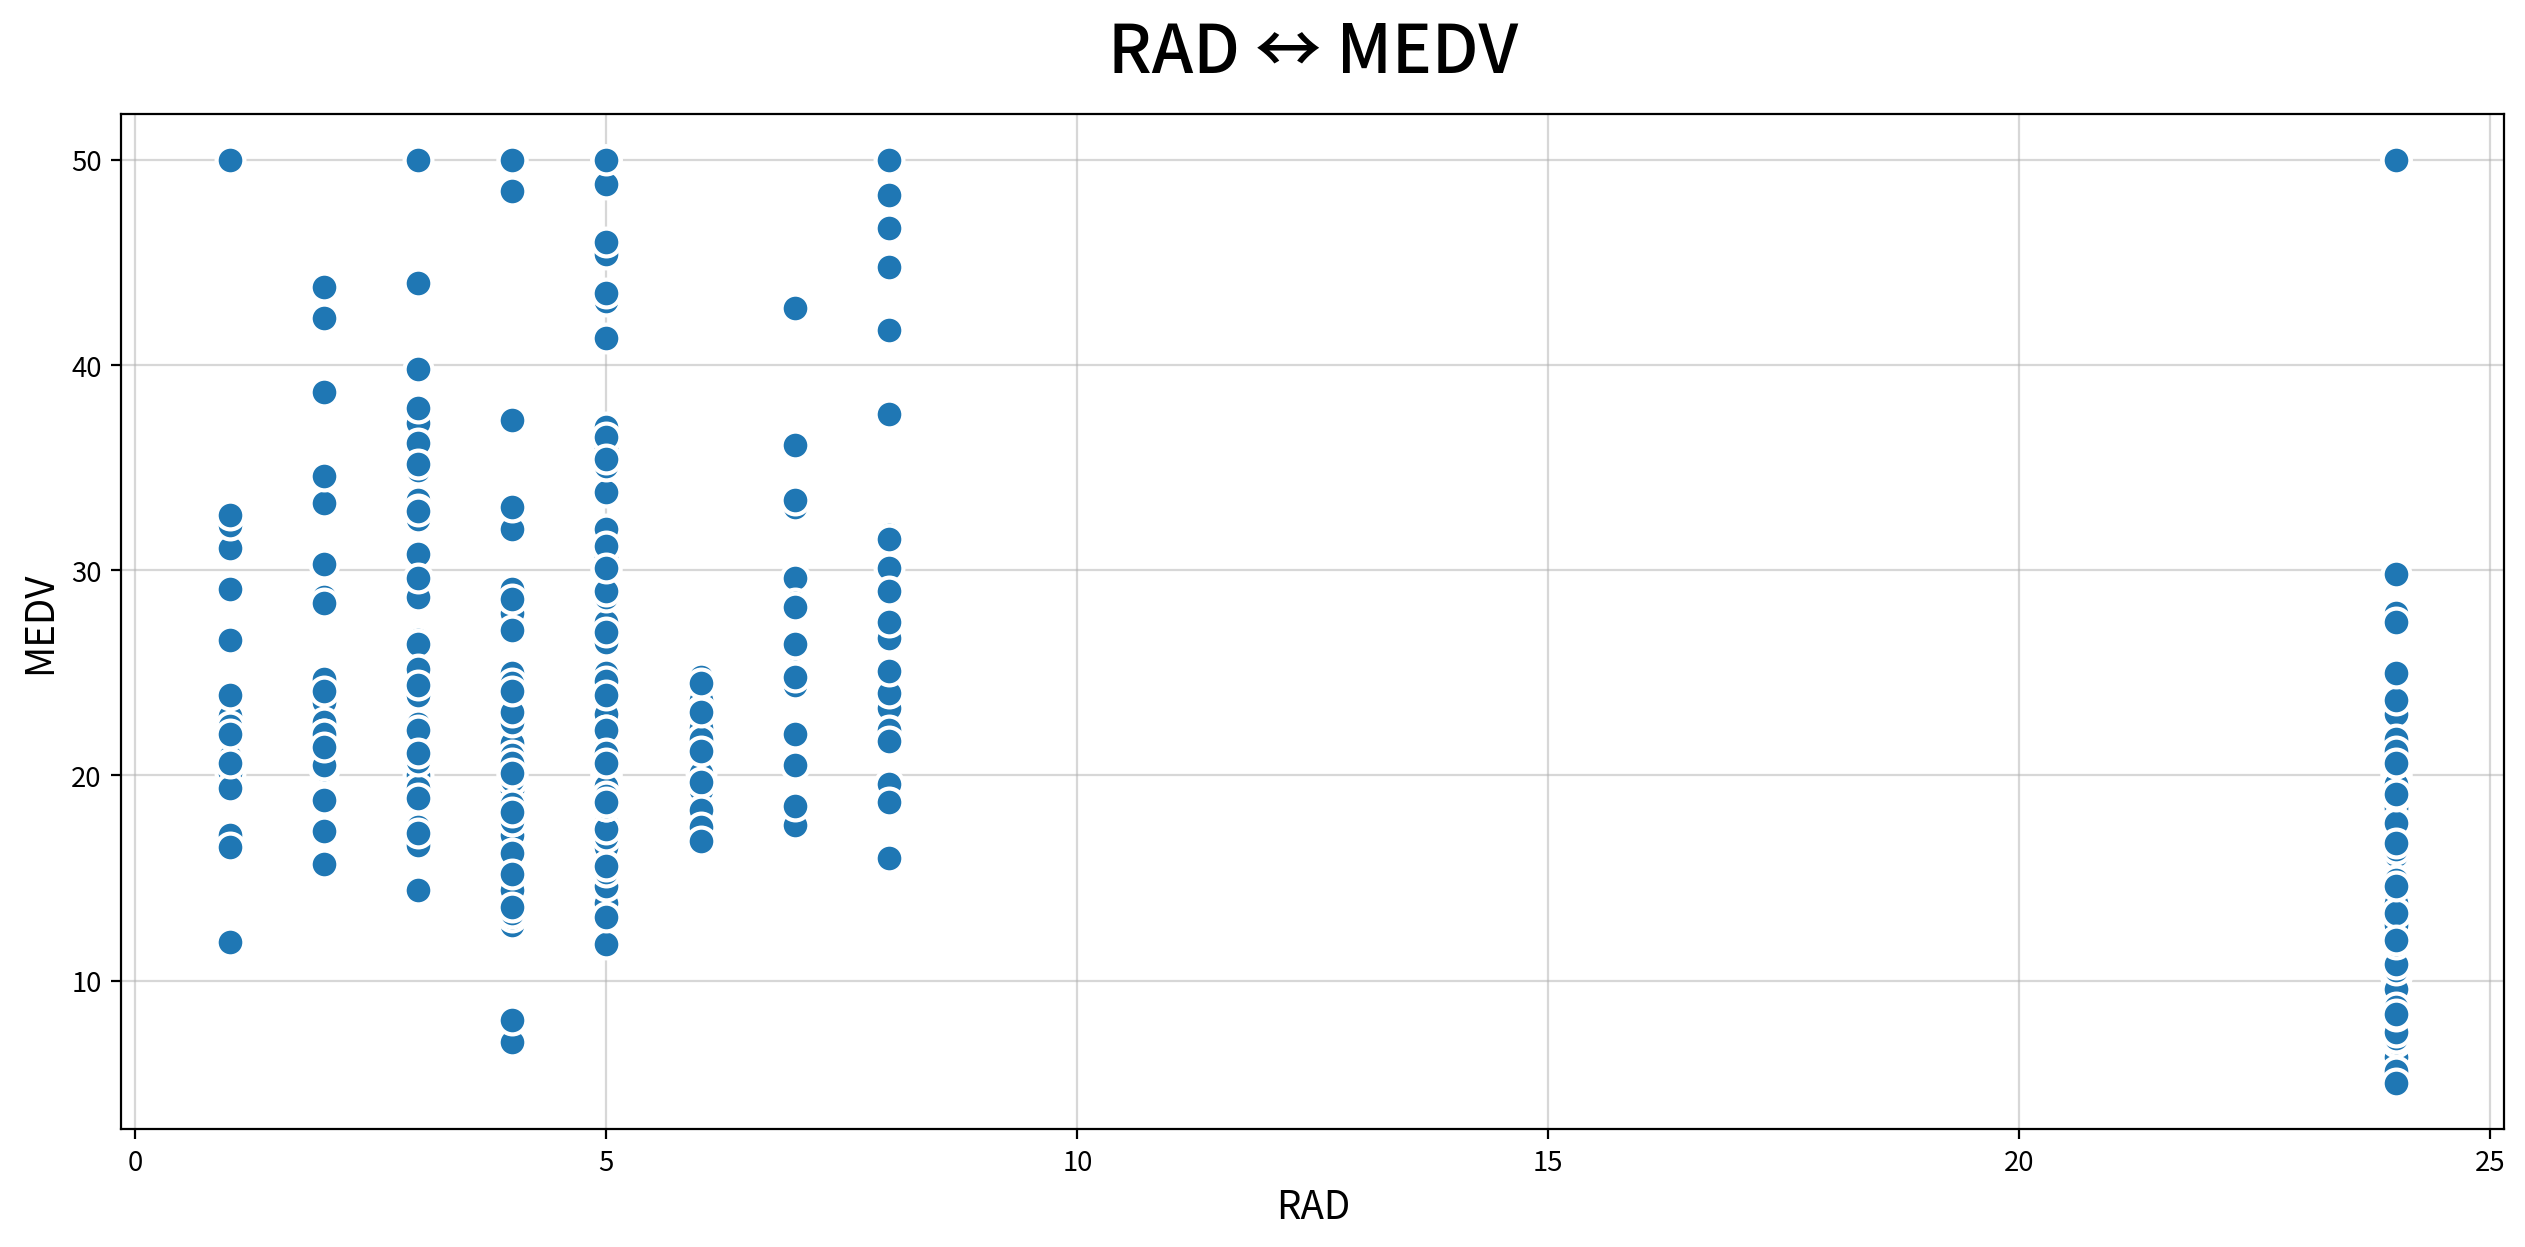

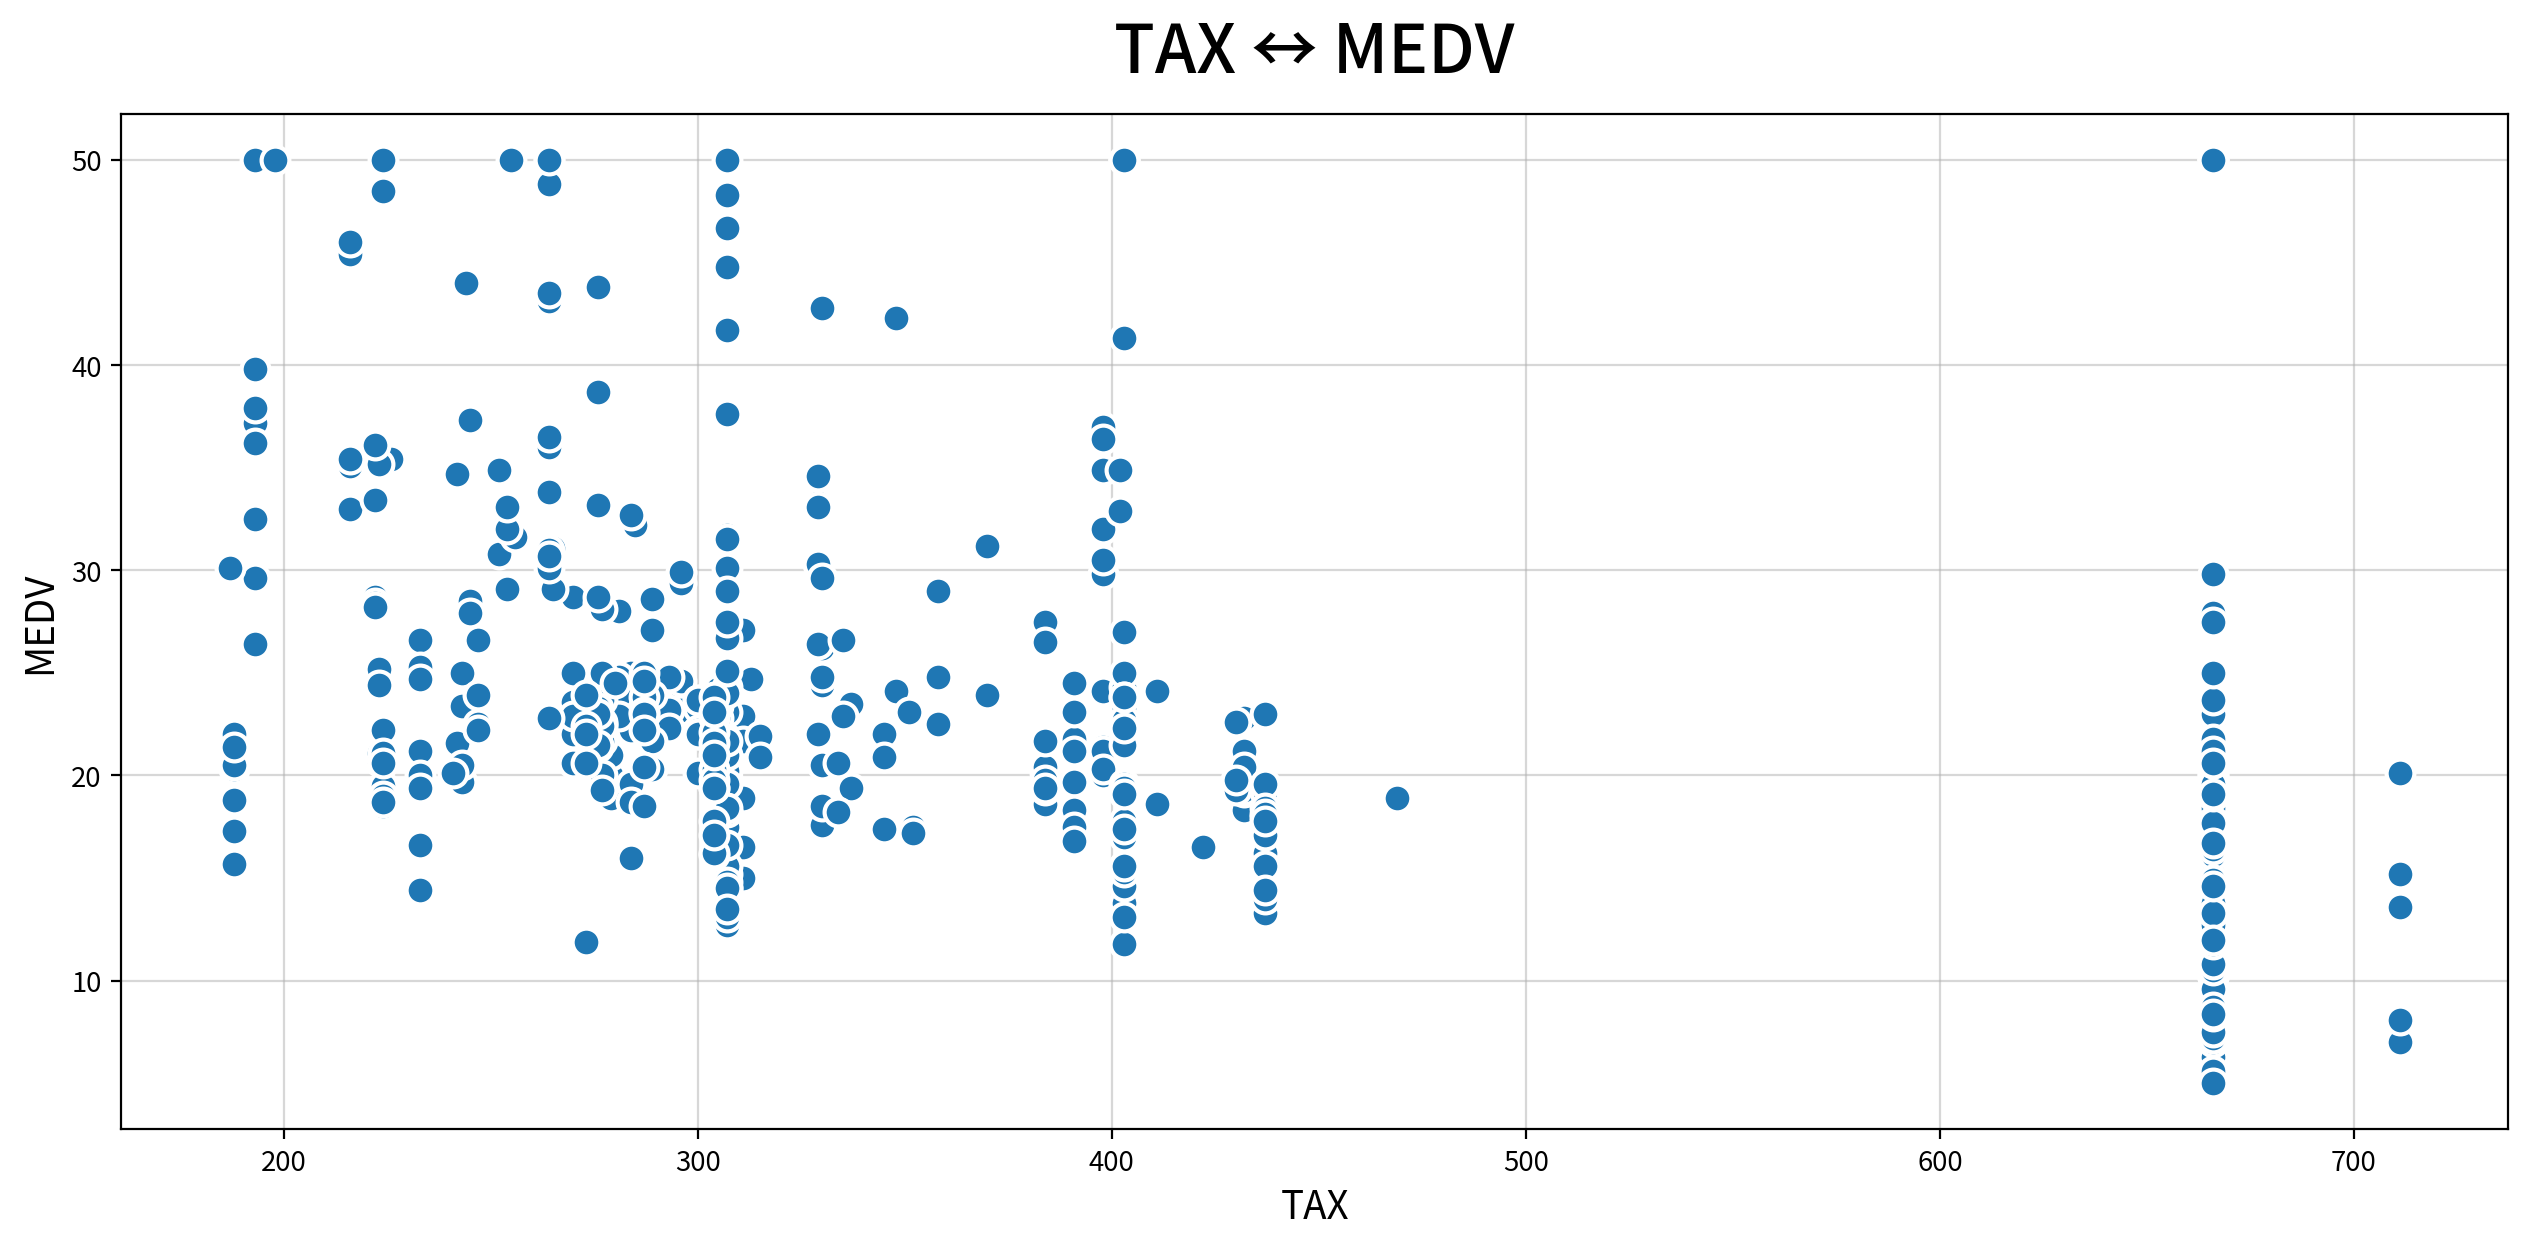

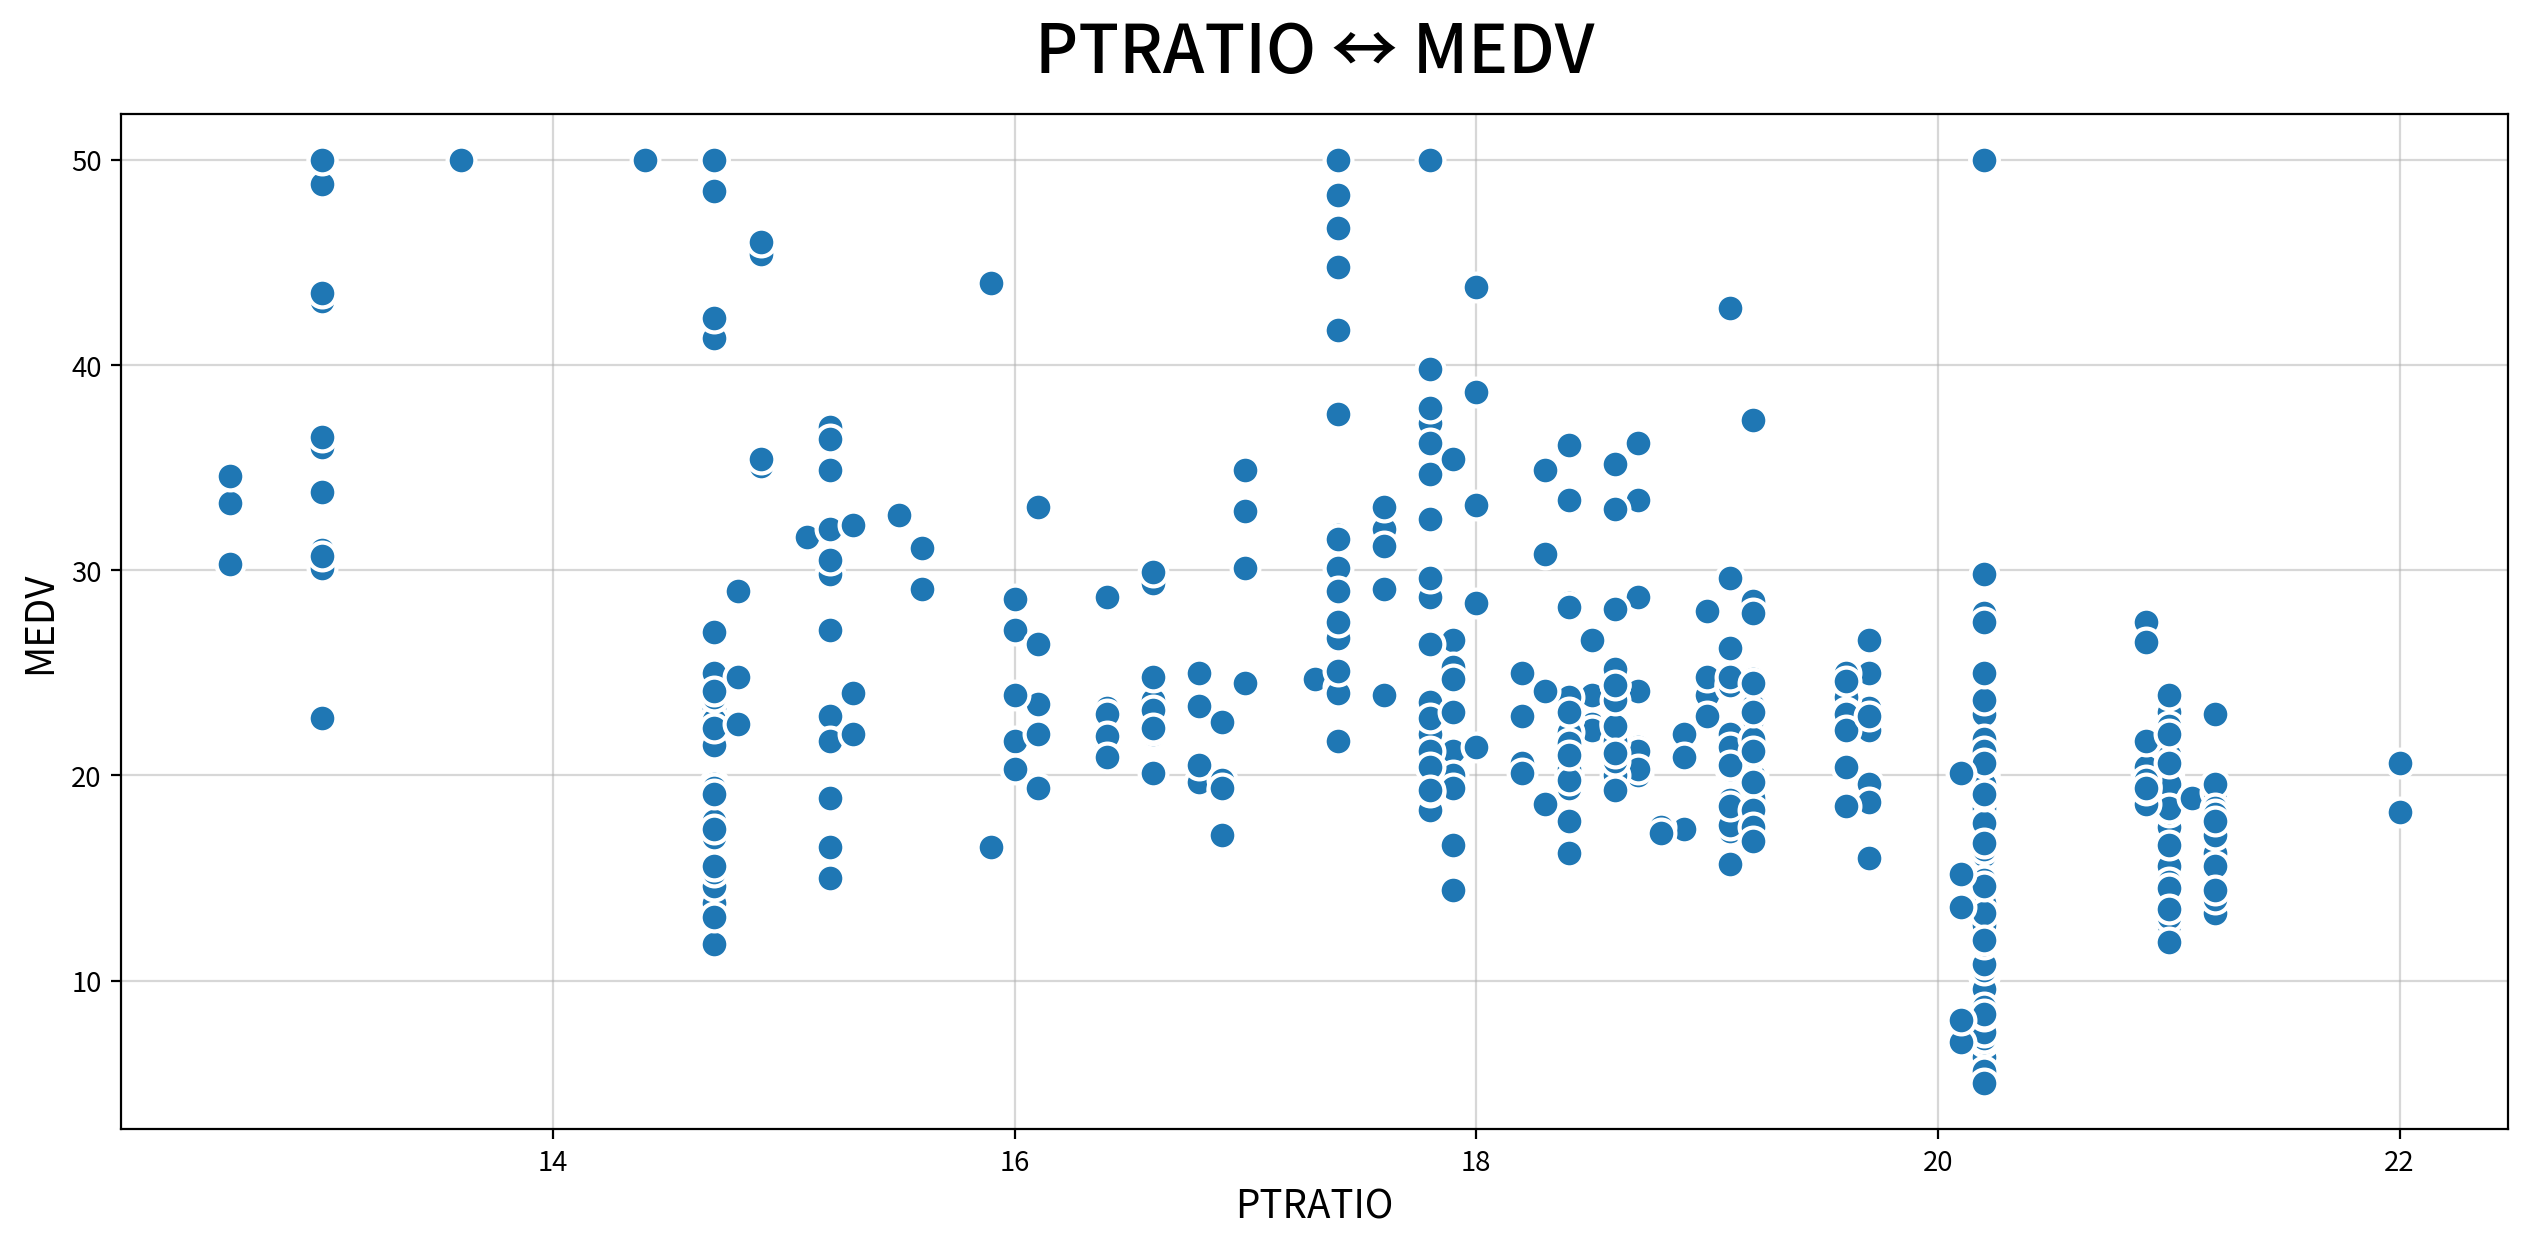

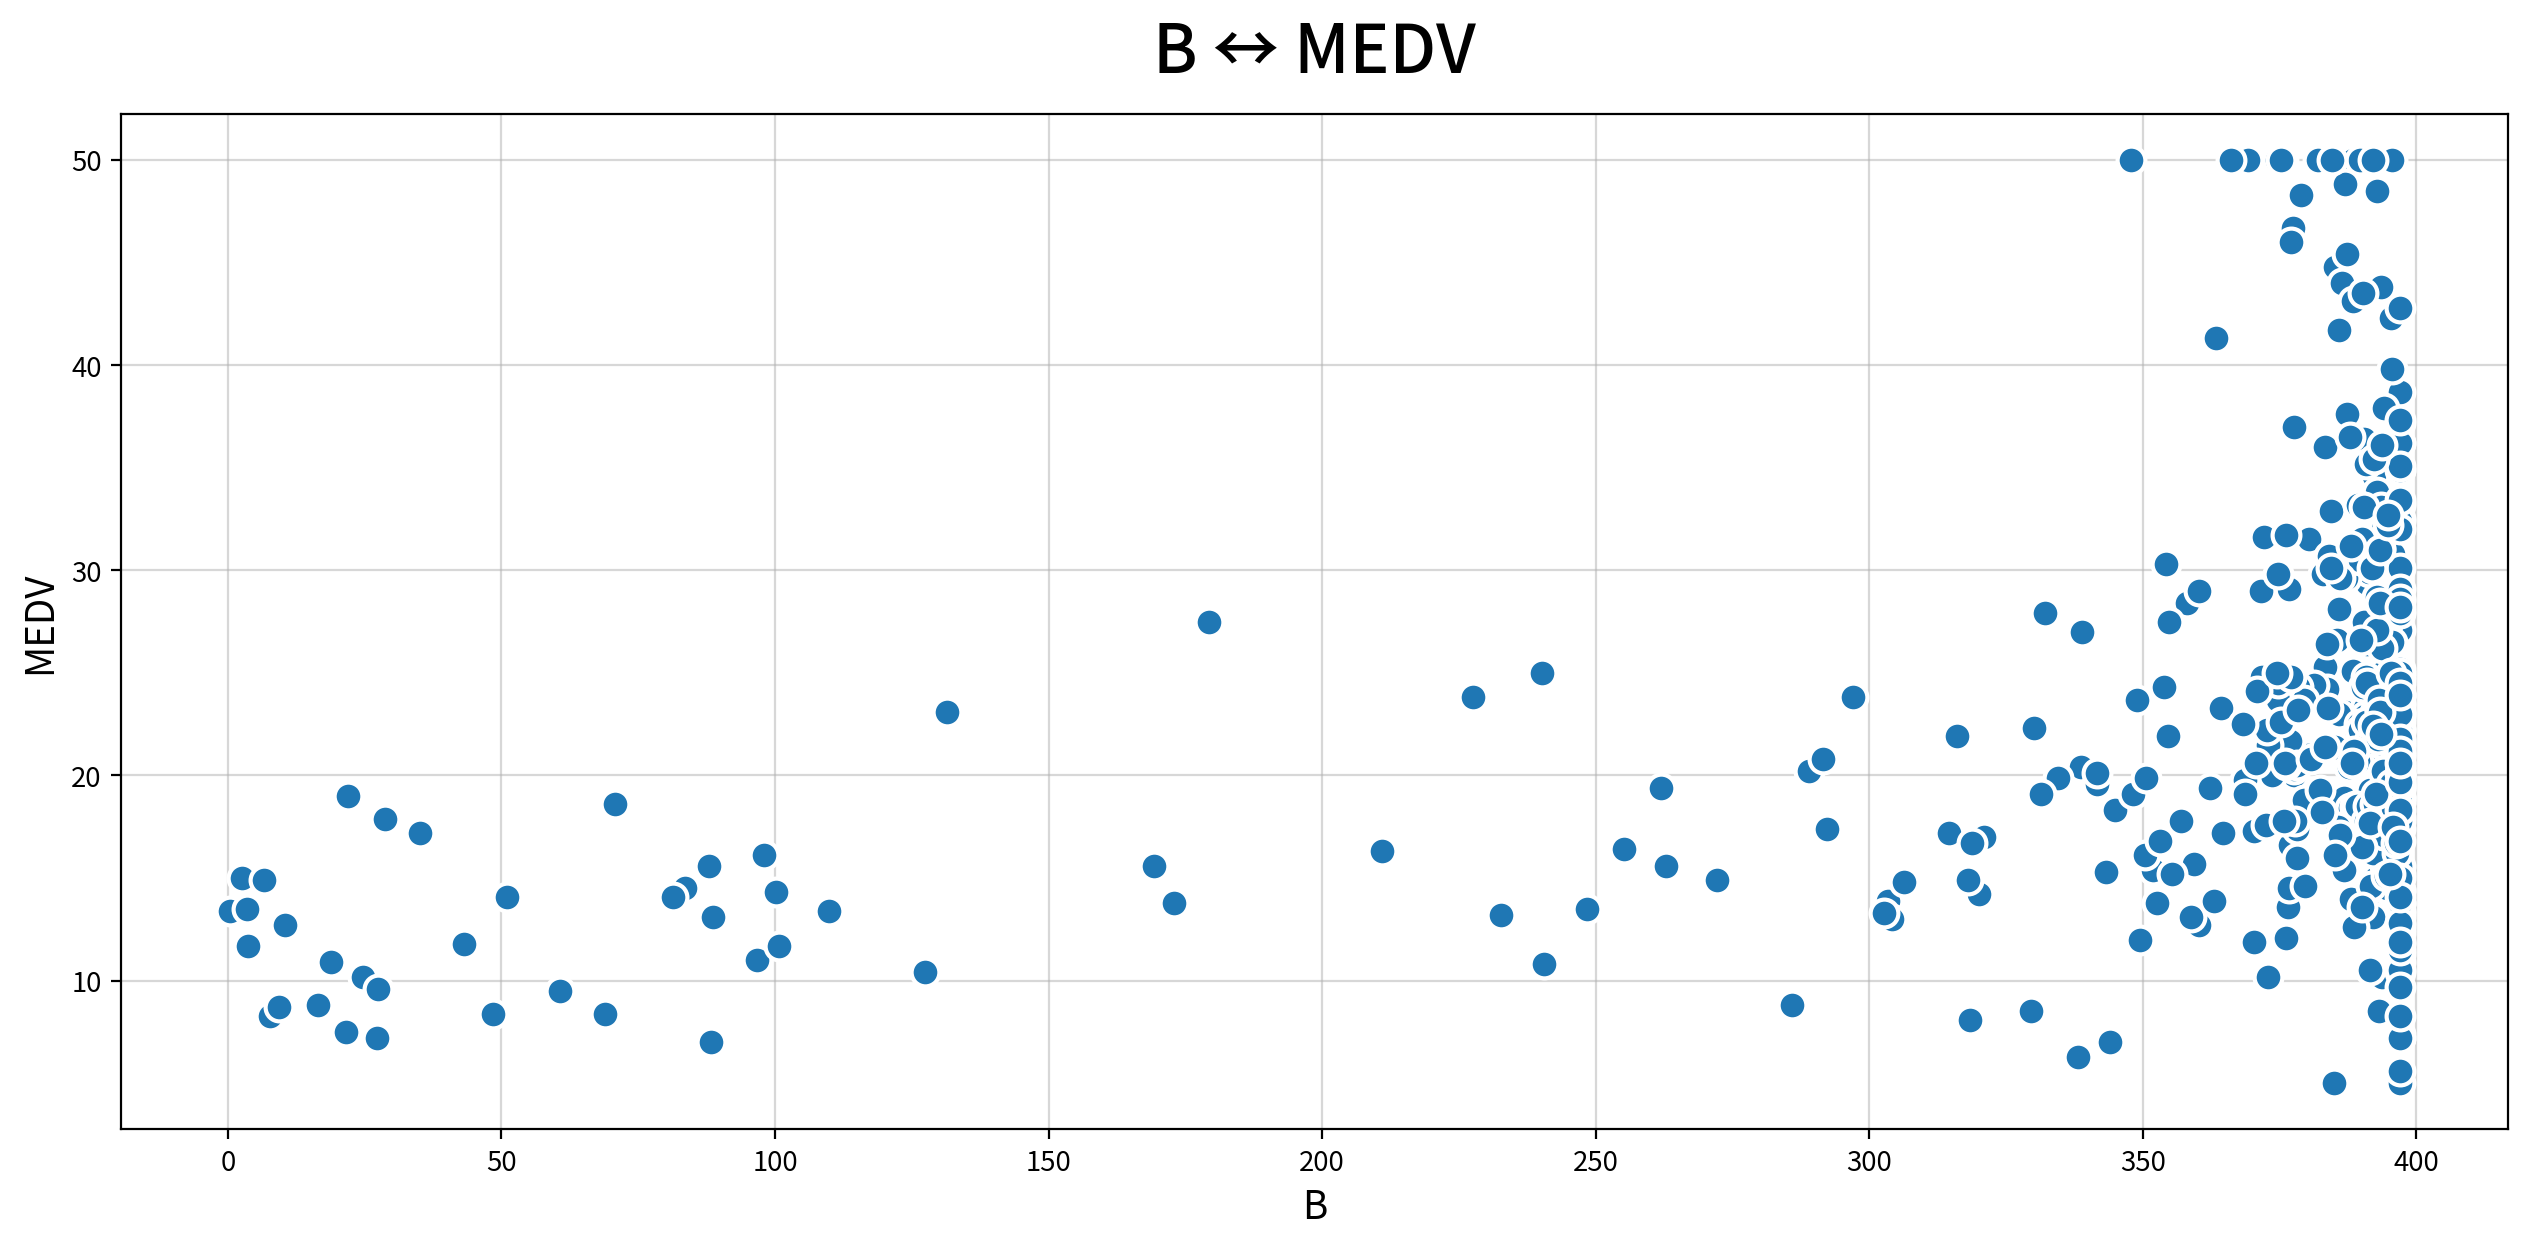

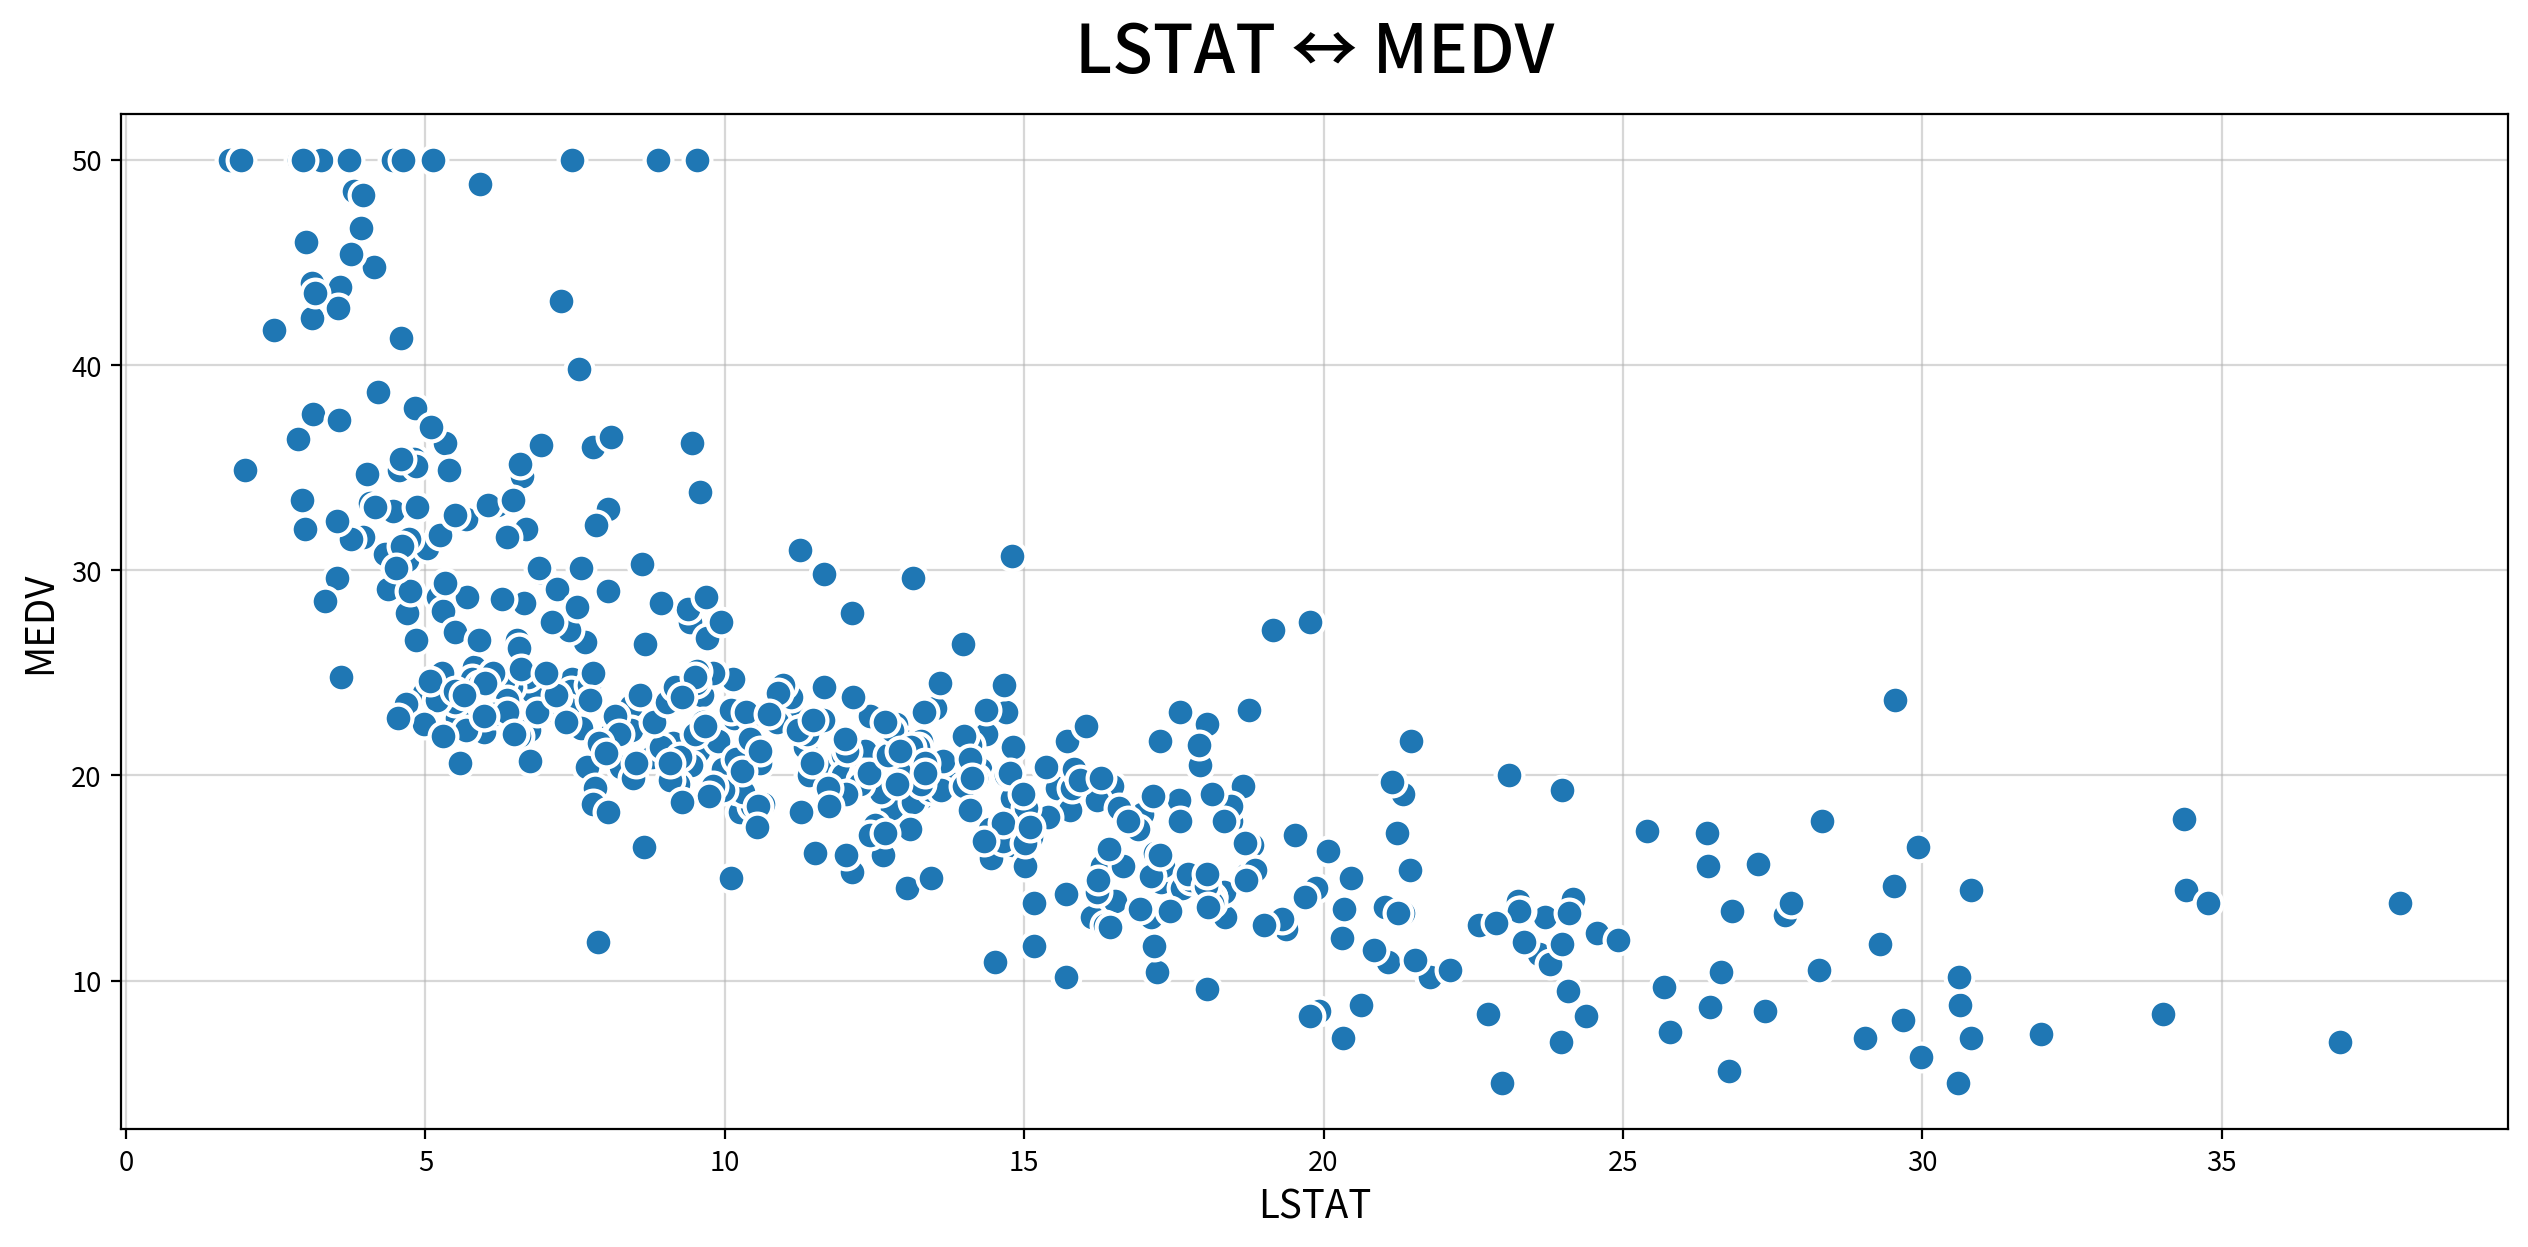

In [26]:
for f in feature_continuous:
    # 연속 ↔ 연속: 산점도로 방향, 모양, 산포를 확인
    my_plot.scatterplot(data=df, x=f, y=target, title=f'{f} ↔ {target}')

- 인사이트
- 연속 X 연속 → 산점도, 짝이 되는 검정은 상관분석(방향, 모양, 산포를 함께 본다)

|변수|관찰된 관계(방향, 모양)|→검정|
|-|-|-|
|LSTAT|강한 음(-), 곡선형(저소득층 ↑ → 가격 ↓)|상관분석|
|RM|뚜렷한 양(+), 약한 곡선(방 수 ↑ → 가격 ↑)|상관분석|
|INDUS, NOX, TAX, PTEATIO, AGE, CRIM, RAD|음(-)경향(산포 큼)|상관분석|
|ZN, DIS, B|약한 양(+) 경향|상관분석|

- 후포 패턴 요약
    - 가장 뚜렷한 관계 : LSTAT(음), RM(양) → 상관분석에서 효과크기 확정 예정
    - RAD, TAX는 값이 띄엄띄엄(이산) 모여 있어 직선 관계로 보기 어려움
    - 아직 눈으로 본 후보이며, 실제 유의성, 강도는 추론통계 단계의 상관분석에서 검증

### 2. 명목형 독립변수 ↔ 종속변수(박스플롯, 바이올린 → T검정)
- 명목형(2집단)과 연속형의 관계는 그룹별 박스플롯, 바이올린으로 본다.
- 두 그룹의 중앙값, 산포 차이를 확인 → 짝이 되는 검정은 T검정

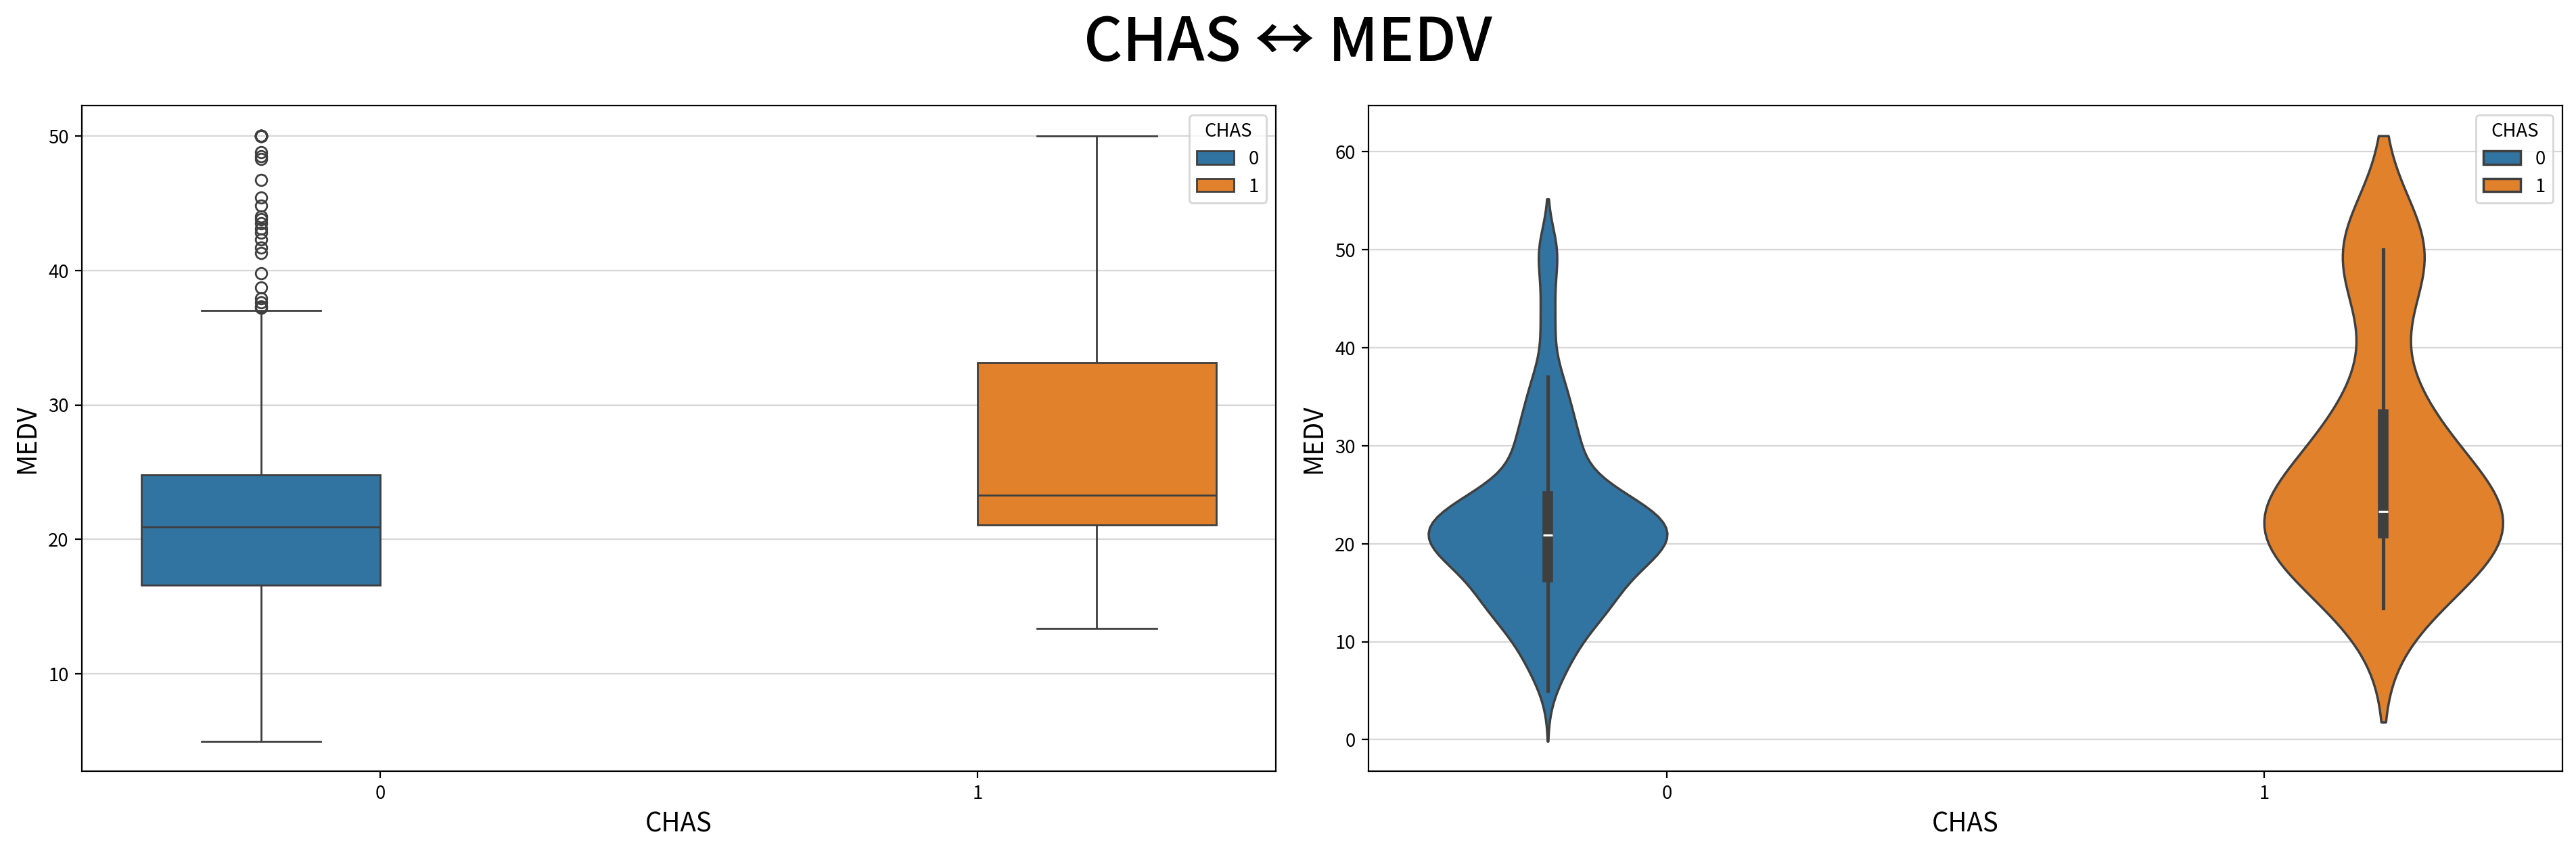

In [27]:
for n in nominal_cols:
    # 명목(2집단) ↔ 연속 : 박스플롯 + 바이올린으로 그룹 간 분포 비교
    fig, ax = my_plot.init(rows=1, cols=2, title=f'{n} ↔ {target}', width=960, height=640)
    my_plot.boxplot(data=df, x=n, y=target, hue=n, ax=ax[0])
    my_plot.violinplot(data=df, x=n, y=target, hue=n, ax=ax[1])
    my_plot.show()

- 인사이트
- 명목(2집단) X 연속 → 박스플롯/바이올린, 짝이 되는 검정은 T검정

|변수(2집단)|관찰된 관계(방향)|→ 검정|
|-|-|-|
|CHAS|인접(1)의 MEDV 중앙값이 높고 분포가 위쪽 → 인접 > 비인접|T검정|

- 후보 패턴 : 강에 인접한 지역(CHAS=1)의 주택 가격이 더 높다.
    - 단 인접 집단 표본이 35건(6.9%)으로 적어 검정, 해석은 신중히 한다.
    - 아직 눈으로 본 후본이므로, 실제 유의성, 효과크기는 추론동계 단계의 T검정에서 확정한다.

## #04. 다변량 데이터 시각화
- 두 변수만으로 보이지 않는 여러 변수의 관계, 군집을 한 번에 보는 단계다.
- 아직 상관분석(상관계수 산출)전이므로, 숫자 대신 페어플롯으로 분포(대각)와 산점도(비대각)를 눈으로 확인한다.
- 필요할 때만 사용한다. 연속형 12개를 모두 그리면 정보 과부하 > 이변량에서 관계가 뚜렷했던 핵심 변수만 골라 그린다.
### 1. 핵심 변수 페어플롯

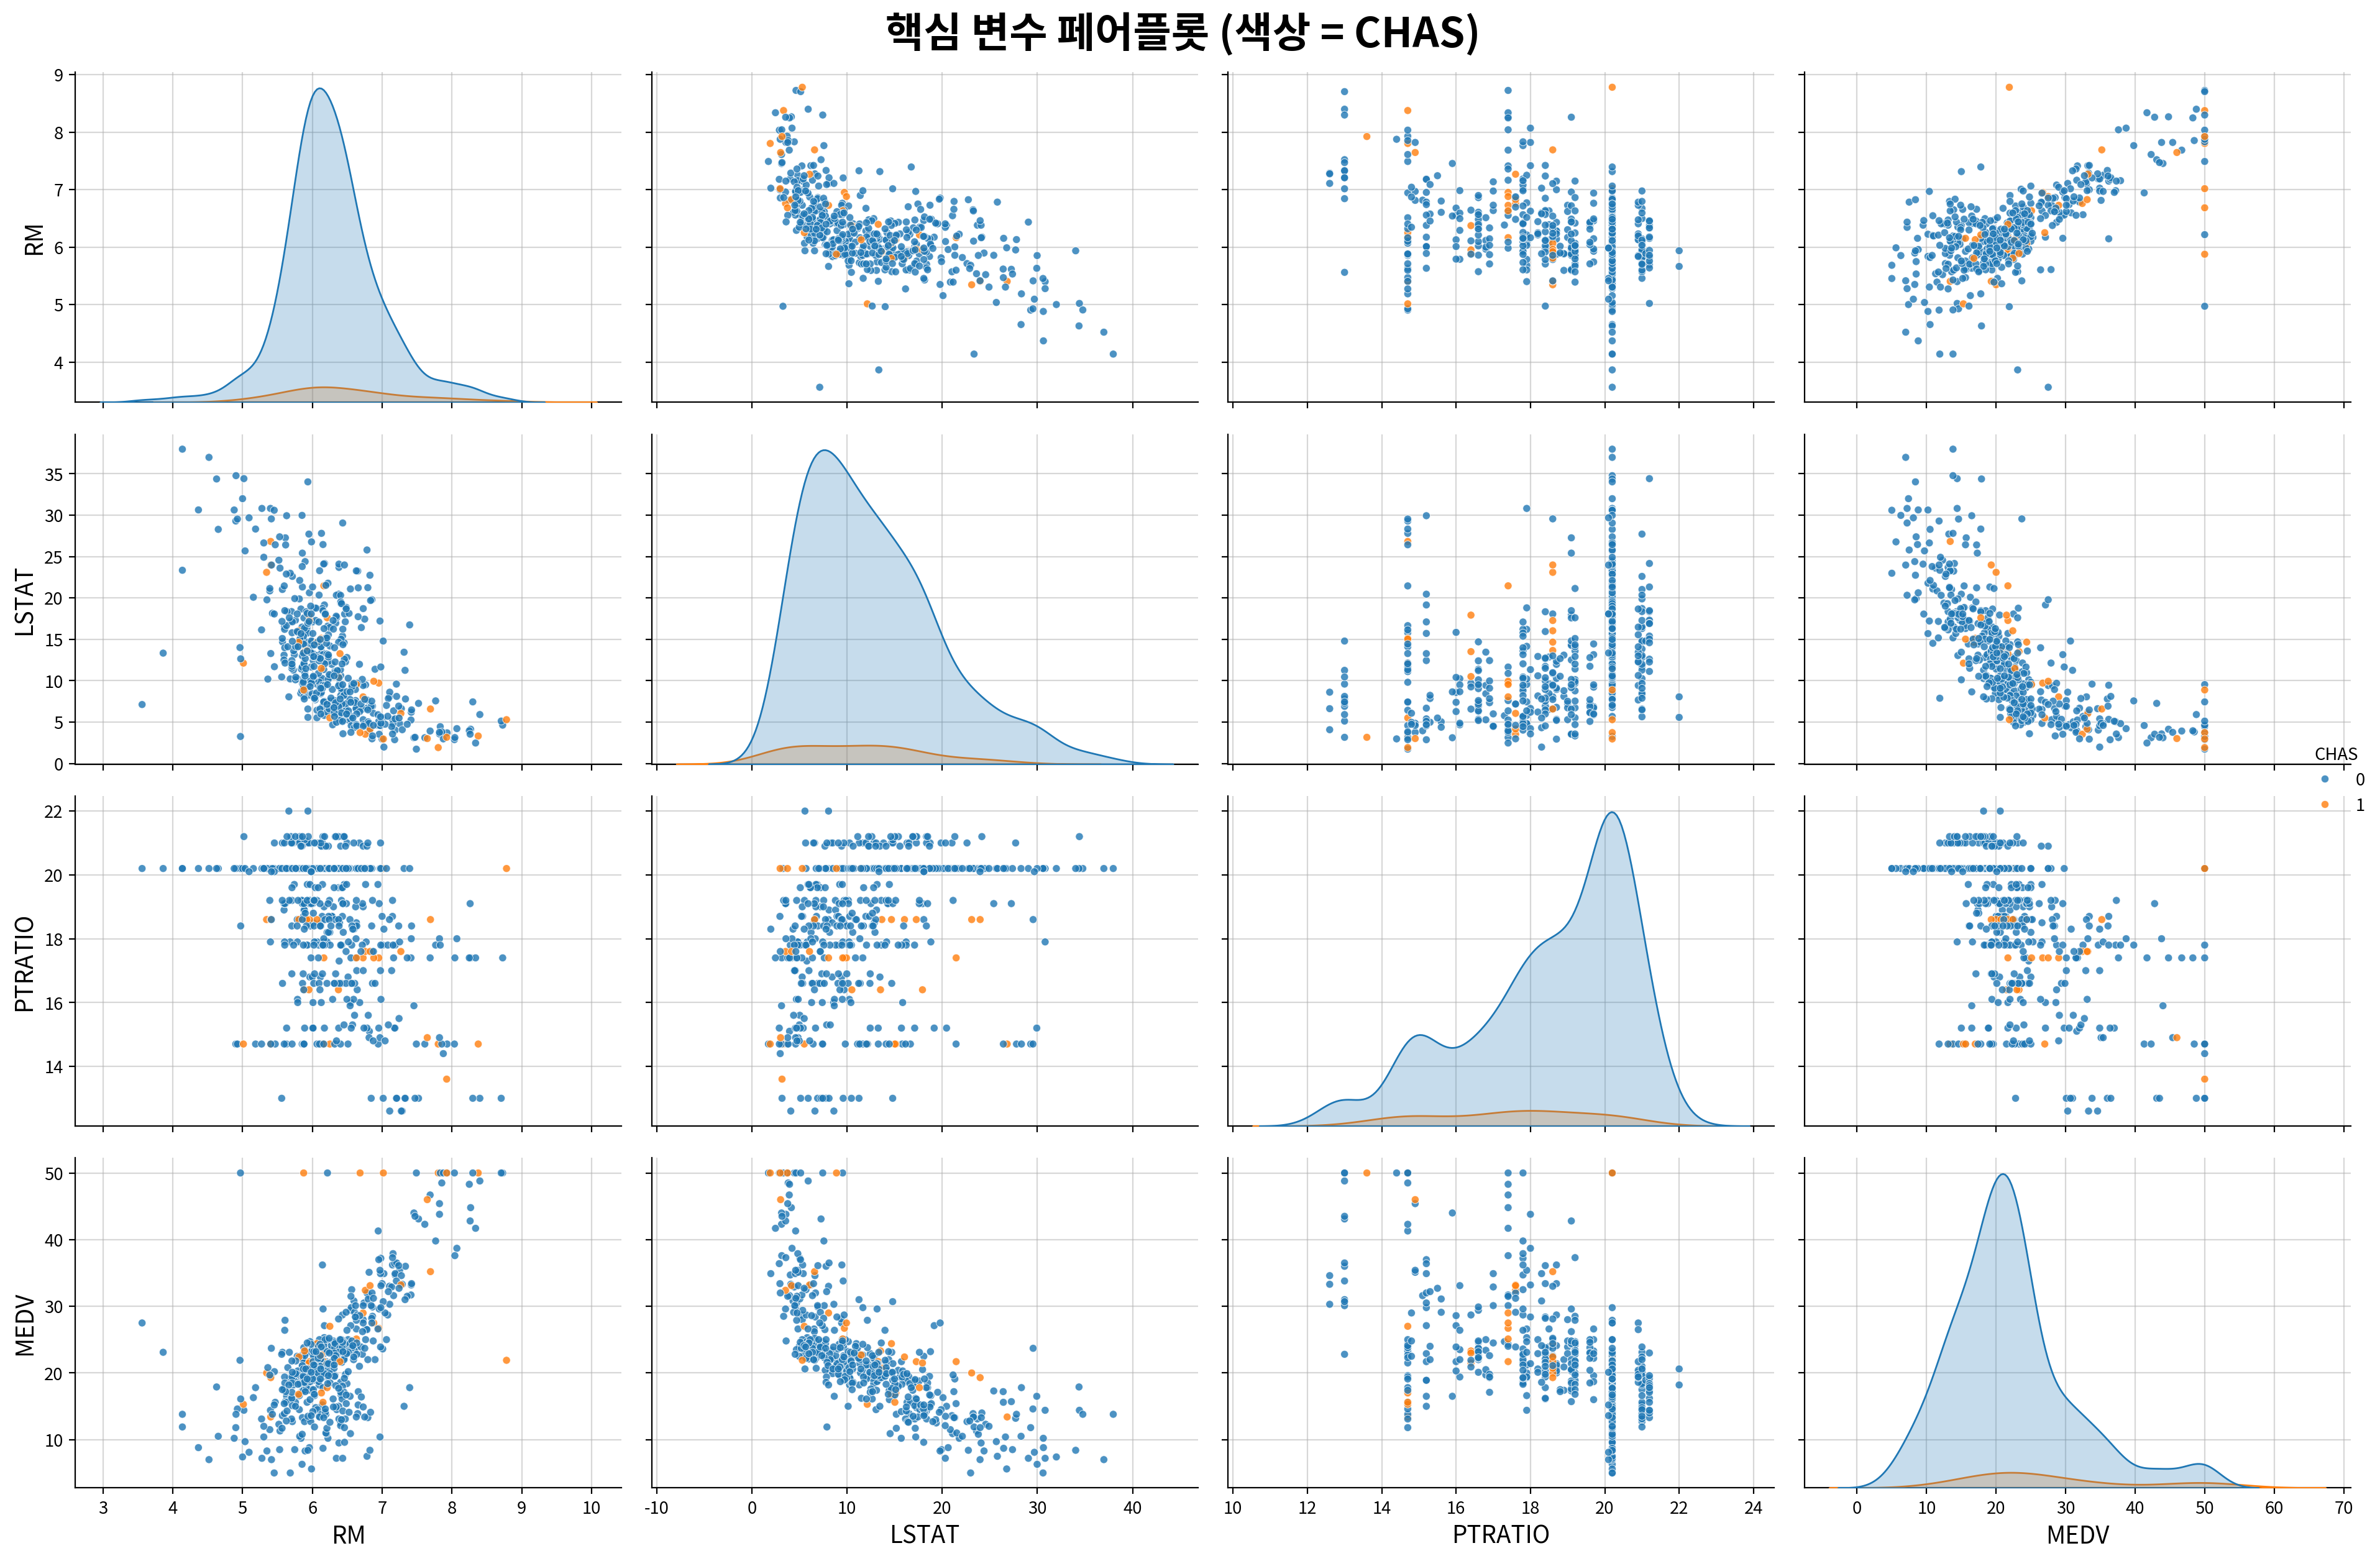

In [28]:
# 핵심변수 페어플롯 - 대각=분포(KDE), 비대각=산점도, 색상=명목형(CHAS)
# 이변량에서 관계가 뚜렷했던 변수 + 종속변수만 선택(12개 전부는 정보 과부하)
core_cols = ['RM','LSTAT', 'PTRATIO', target]
hue_col = nominal_cols[0]
my_plot.pairplot(data=df[core_cols + [hue_col]], hue=hue_col, diag_kind='kde', title=f'핵심 변수 페어플롯 (색상 = {hue_col})', width=480*4, height=320*4)

- 인사이트
- 페어플롯으로 핵심변수들의 분포(대각)와 두 변수 관계(비대각)를 한번에 확인한다.
- MEDV 관계 : LSTAT은 강한 음(곡선), RM은 양, PTRATIO는 음 경향 -> 이변량 산점도에서 본 방향과 일치
- 색상(CHAS): 강 인접 점들이 같은 위치에서도 MEDV 위쪽(고가)에 분포 > 인접 지역이 비싸다 후보 패턴 보강
- 설명 변수끼리의 관계 : LSTAT 높을 때 RM 낮은 경향 등 => 변수 간 중복(공선성) 가능성의 시각 단서
- 여기까지는 모두 눈으로 본 후보다. 상관계수, 유의성 등 숫자 근거는 추론통계의 상관분석에서 확정한다.

### 추론통계 후보 패턴 목록
|#|변수조합(유형)|관찰된 패턴(방향, 근거 그래프)|→ 검정|
|-|-|-|-|
|01|LSTAT, MEDV(연속X연속)|LSTAT ↑ → MEDV ↓, 강한 감소, 곡선형(산점도, 페어플롯)|상관분석|
|02|RM, MEDV(연속X연속)|RM ↑ → MEDV ↑, 증가(산점도, 페어플롯)|상관분석|
|03|PTRATIO, MEDV(연속X연속)|PTRATIO ↑ → MEDV ↓, 감소 경향(산점도, 페어플롯)|상관분석|
|04|그 외 연속형 9종, MEDV(연속X연속)|음: INDUS, NOX, TAX, PTEATIO, AGE, CRIM, RAD / 약한 양: ZN, DIS, B(산점도)|상관분석|
|05|CHAS, MEDV(명목2집단 X 연속)|강 인접(1) 집단의 MEDV 중앙값 ↑ = 인접>비인접(박스, 바이올린)|T검정|
|06|RAD, TAX(연속X연속)|두 변수가 강하게 동반 변화 = 공선성 의심(페어플롯)|상관분석/VIF|